<h2 style="text-align:center;color:#48C9B0;">Nettoyage et construction des datasets SFT / DPO</h2>
<p style="text-align:center">Notebook 02 — fondé sur les résultats exécutés de l’audit transmis le 31 août 2026</p>

**Oui : l’audit suffit pour commencer le nettoyage technique. Non : il ne garantit ni 5 000 exemples finaux après filtrage, ni la justesse médicale de chaque réponse, ni une supervision du triage.**

Ce notebook autonome recharge les mêmes fichiers bruts que le notebook 01. Il produit des candidats, un registre d’exclusions et une file de revue. L’export final n’est autorisé qu’après les contrôles automatiques et une validation humaine documentée. Aucun entraînement n’est lancé, aucune donnée n’est envoyée à un service externe, aucune source brute n’est modifiée.

Le SFT vise **5 000 lignes d’entraînement**, hors validation et test. Le DPO conserve des préférences relatives : `chosen` ne signifie pas « réponse médicalement validée », et `rejected` ne signifie pas nécessairement « réponse fausse ».

<h2 style="text-align:center;color:#48C9B0;">🧩 Sommaire</h2>

1. [Ce que l’audit permet de décider](#section-1)
2. [Configuration et prérequis](#section-2)
3. [Chargement, provenance et schéma commun](#section-3)
4. [Nettoyage conservateur et revue ciblée](#section-4)
5. [Contradictions QCM et cohérence DPO](#section-5)
6. [Quasi-doublons et groupes globaux](#section-6)
7. [Protection des splits et déduplication](#section-7)
8. [Formats SFT/DPO et budgets de tokens](#section-8)
9. [Sélection diversifiée des candidats](#section-9)
10. [Contrôles et exports de travail](#section-10)
11. [Validation humaine et export final](#section-11)
12. [Validation finale et préparation à l’export](#section-12)
13. [Bilan, limites et passage à l’entraînement](#section-13)

<h2 id="section-1" style="color:#48C9B0;">1. Ce que l’audit permet de décider</h2>

<div style="border-left:5px solid #48C9B0;background:#f2fbf9;color:#000;padding:12px 16px;margin:16px 0;">
  <strong>Objectif</strong><br>
  Séparer les résultats effectivement observés lors de l’audit, les règles de nettoyage qui en découlent et les choix de sélection retenus pour construire les datasets SFT et DPO.
</div>

Les <strong>tableaux exécutés</strong> constituent la référence pour cette version du pipeline. Plusieurs paragraphes du notebook d’analyse peuvent reprendre des valeurs issues d’exécutions antérieures ; ces valeurs historiques ne doivent pas être interprétées comme des compteurs actualisés.

<table style="width:100%;border-collapse:collapse;margin:16px 0;">
  <thead>
    <tr style="background:#48C9B0;color:white;">
      <th style="border:1px solid #ddd;padding:8px;text-align:left;">Résultat exécuté</th>
      <th style="border:1px solid #ddd;padding:8px;text-align:left;">Décision appliquée</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="border:1px solid #ddd;padding:8px;">18 051 lignes train dans FrenchMedMCQA et MediQAl MCQU/MCQM</td>
      <td style="border:1px solid #ddd;padding:8px;">Constituer le vivier francophone du SFT. Le volume brut ne garantit pas à lui seul l’atteinte du quota après les contrôles de qualité, confidentialité, déduplication et longueur.</td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd;padding:8px;">Contextes manquants dans environ 54 à 63 % des QCM MediQAl</td>
      <td style="border:1px solid #ddd;padding:8px;">Conserver les questions réellement autonomes et isoler les exemples dont la compréhension dépend d’un contexte absent.</td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd;padding:8px;">Quelques MCQU comportent quatre choix, avec des positions de réponse valides dans l’audit</td>
      <td style="border:1px solid #ddd;padding:8px;">Accepter quatre ou cinq choix pour MCQU, sans créer artificiellement de proposition supplémentaire, et parser strictement les labels.</td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd;padding:8px;">32 groupes QCM contradictoires exportés</td>
      <td style="border:1px solid #ddd;padding:8px;">Recalculer les conflits globalement et soumettre les contradictions non résolues à exclusion ou revue, sans correction médicale automatique.</td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd;padding:8px;">9 803 paires proches candidates ; recherche initiale locale par dataset</td>
      <td style="border:1px solid #ddd;padding:8px;">Réutiliser ces signaux et compléter l’analyse par une recherche globale de quasi-doublons entre sources, familles et formats.</td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd;padding:8px;">60 195 lignes UltraMedical train appartiennent à des groupes de prompts répétés, soit environ 55,05 %</td>
      <td style="border:1px solid #ddd;padding:8px;">Ne pas dédupliquer sur le prompt seul : plusieurs comparaisons de préférences pour un même prompt peuvent être légitimes.</td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd;padding:8px;">24 876 lignes train appartiennent à 12 438 groupes de triplets répétés</td>
      <td style="border:1px solid #ddd;padding:8px;">Traiter les répétitions exactes au niveau du triplet DPO. Conserver un représentant retirerait 12 438 lignes selon cet audit, avant application des autres filtres.</td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd;padding:8px;">560 groupes d’inversions DPO et 6 178 groupes de réponses changeant de rôle</td>
      <td style="border:1px solid #ddd;padding:8px;">Isoler les inversions et les cycles de préférence. Un changement de rôle n’est pas automatiquement contradictoire : une relation A &gt; B &gt; C peut rester cohérente.</td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd;padding:8px;">Des candidats PII ont été détectés dans MediQAl, MedQuAD et UltraMedical</td>
      <td style="border:1px solid #ddd;padding:8px;">Appliquer la détection complète, l’anonymisation automatique des catégories fiables et la revue humaine des cas ambigus. L’absence de signal détecté ne constitue pas une preuve d’anonymat.</td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd;padding:8px;">114 lignes MedQuAD et 585 lignes UltraMedical train dépassent 2 048 tokens dans le texte agrégé</td>
      <td style="border:1px solid #ddd;padding:8px;">Recalculer la longueur sur les conversations finales produites par le template du tokenizer. En DPO, mesurer séparément prompt + chosen et prompt + rejected. Ne pas tronquer automatiquement.</td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd;padding:8px;">UltraMedical : 1 238 lignes validation partagent un prompt avec le train, soit 55,47 %</td>
      <td style="border:1px solid #ddd;padding:8px;">Appliquer la protection des splits au niveau des groupes, avec priorité au test puis à la validation, afin d’éviter les fuites vers le train.</td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd;padding:8px;">MediQAl présente de forts chevauchements de cas et 3 920 groupes d’entrées partagées entre sources ont été identifiés</td>
      <td style="border:1px solid #ddd;padding:8px;">Regrouper les contenus liés entre familles et sources avant la protection des partitions afin qu’un même contenu clinique ne puisse pas traverser les splits.</td>
    </tr>
  </tbody>
</table>

<h3 style="color:#48C9B0;">Règles acquises</h3>

<ul>
  <li>Ne jamais dédupliquer sur la réponse seule.</li>
  <li>Ne pas inventer de labels de triage absents des données sources.</li>
  <li>Ne pas fabriquer d’explication ou de justification médicale.</li>
  <li>Ne pas traduire automatiquement les exemples pour créer artificiellement du bilinguisme.</li>
  <li>Traiter les droits, la provenance, la confidentialité, les conflits et les fuites de splits comme des conditions d’admissibilité préalables à la sélection.</li>
  <li>Conserver OEQ hors du train afin de préserver son rôle spécifique d’évaluation ouverte.</li>
  <li>Utiliser MedQuAD comme source anglophone SFT après validation de sa provenance et de ses conditions d’utilisation.</li>
  <li>Conserver UltraMedical-Preference dans le pipeline DPO et ne pas l’utiliser pour compléter artificiellement le quota SFT anglais.</li>
</ul>

<h3 style="color:#48C9B0;">Stratégie de sélection retenue</h3>

<p>La sélection suit deux niveaux successifs. La qualité constitue d’abord une condition obligatoire : un exemple doit avoir franchi les contrôles de droits et de provenance, de complétude, de confidentialité, de cohérence, de protection des splits, de déduplication et de budget de tokens avant de pouvoir participer à la sélection.</p>

<p>La diversité intervient uniquement parmi ces exemples admissibles. Elle permet ensuite de limiter les concentrations excessives et de rechercher une meilleure couverture des spécialités, contextes, types de questions, longueurs, tâches et sous-sources. Un critère de diversité ne peut jamais compenser une anomalie bloquante ou une réponse jugée inexploitable.</p>

<table style="width:100%;border-collapse:collapse;margin:16px 0;">
  <thead>
    <tr style="background:#48C9B0;color:white;">
      <th style="border:1px solid #ddd;padding:8px;text-align:left;">Dataset d’entraînement</th>
      <th style="border:1px solid #ddd;padding:8px;text-align:left;">Source / famille</th>
      <th style="border:1px solid #ddd;padding:8px;text-align:left;">Cible</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="border:1px solid #ddd;padding:8px;">SFT français</td>
      <td style="border:1px solid #ddd;padding:8px;">FrenchMedMCQA</td>
      <td style="border:1px solid #ddd;padding:8px;">375</td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd;padding:8px;">SFT français</td>
      <td style="border:1px solid #ddd;padding:8px;">MediQAl MCQU</td>
      <td style="border:1px solid #ddd;padding:8px;">1 125</td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd;padding:8px;">SFT français</td>
      <td style="border:1px solid #ddd;padding:8px;">MediQAl MCQM</td>
      <td style="border:1px solid #ddd;padding:8px;">1 000</td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd;padding:8px;"><strong>Total SFT français</strong></td>
      <td style="border:1px solid #ddd;padding:8px;">FrenchMedMCQA + MediQAl</td>
      <td style="border:1px solid #ddd;padding:8px;"><strong>2 500</strong></td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd;padding:8px;">SFT anglais</td>
      <td style="border:1px solid #ddd;padding:8px;">MedQuAD</td>
      <td style="border:1px solid #ddd;padding:8px;">2 500</td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd;padding:8px;"><strong>Total SFT</strong></td>
      <td style="border:1px solid #ddd;padding:8px;">Français + anglais</td>
      <td style="border:1px solid #ddd;padding:8px;"><strong>5 000</strong></td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd;padding:8px;">DPO</td>
      <td style="border:1px solid #ddd;padding:8px;">UltraMedical-Preference</td>
      <td style="border:1px solid #ddd;padding:8px;">Tous les exemples admissibles après nettoyage et déduplication</td>
    </tr>
  </tbody>
</table>

<p>Les quotas SFT sont des objectifs de sélection et non une autorisation à relâcher les critères de qualité. Si une famille ne contient pas suffisamment d’exemples admissibles, le déficit doit être signalé explicitement plutôt que compensé par des observations rejetées.</p>


<h2 id="section-2" style="color:#48C9B0;">2. Configuration et prérequis</h2>
<div style="border-left:5px solid #48C9B0;background:#f2fbf9;color:#000;padding:12px 16px;margin:16px 0;"><strong>Objectif</strong><br>Exécuter dans VS Code avec l’environnement uv du projet.</div>


Dans le terminal du projet, si nécessaire :

```powershell
uv add pandas numpy transformers langdetect datasketch rapidfuzz
uv add --dev ipykernel
```

Sélectionner le kernel de `.venv` dans VS Code et conserver `uv.lock`. Python 3.11+ conseillé selon les dépendances disponibles. Renseigner `PROJECT_ROOT_OVERRIDE` si le notebook n’est pas dans le projet. Le tokenizer est chargé **localement uniquement** ; le télécharger séparément avant l’exécution s’il n’est pas déjà en cache.

Les répertoires de travail peuvent contenir des données sensibles, y compris les candidats et les identifiants de traçabilité : accès restreint, stockage chiffré, pas de commit Git ni de publication automatique. Ce notebook ne configure pas le chiffrement et ne certifie pas la conformité RGPD.

In [142]:
from __future__ import annotations

import json
import sys
import time
import urllib.request
from collections import Counter, defaultdict
from copy import deepcopy
from datetime import date, datetime
from difflib import SequenceMatcher
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from pydantic import BaseModel, Field
from tqdm.auto import tqdm

# ## Racine du projet

# Détermine la racine du projet depuis le notebook.
# Ajoute le projet au path Python uniquement si nécessaire.
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(
        0,
        str(PROJECT_ROOT)
    )

In [143]:
# ## Imports du pipeline

# Configuration générale, registres des sources
# et paramètres des contrôles du pipeline.
from scr.config import (
    CONFIG,
    DATASET_SPECS,
    SOURCE_REGISTRY,
    ClinicalPrivacyPatterns,
    ContextPatterns,
    DatasetSpec,
    PipelineConfig,
    PrivacyConfig,
    QualityConfig,
    SourceSchema,
    SourceSpec,
    TextConfig
)


# ## Données

# Charge, valide et canonicalise les datasets bruts.
# Prépare les records selon le schéma interne commun.
from scr.data.canonicalization import Canonicalizer
from scr.data.loading import (
    load_raw,
    project_root,
    validate_raw_dataset
)


# ## Nettoyage et qualité

# Nettoie, normalise et valide les records canoniques.
# Produit les textes, empreintes et indicateurs qualité.
from scr.data.cleaning import (
    clean_text,
    unresolved
)


# ## Confidentialité

# Détecte les PII et applique les décisions de revue humaine.
# Contrôle aussi les éléments automatiques encore présents.
from scr.data.privacy import (
    PrivacyDecisionProcessor,
    PrivacyReviewManager,
    PrivacyReviewStatus,
    privacy_review_categories
)
from scr.data.enrichment import (
    RecordEnricher,
    collect_remaining_automatic_pii
)


# ## Conflits et déduplication

# Analyse les incohérences QCM/DPO et les doublons.
# Prépare les groupes exploitables pour la sélection finale.
from scr.data.conflicts import ConflictAnalyzer
from scr.data.deduplication import DuplicateAnalyzer


# ## Sélection

# Construit les pools candidats destinés au SFT.
# Applique les règles d'admission du pipeline.
from scr.data.selection import (
    AdmissionSelector,
    SFTSourcePoolBuilder
)


# ## Qualité sémantique

# Évalue la qualité sémantique déterministe et optionnellement par LLM.
# Intègre ensuite les décisions de revue humaine.
from scr.data.semantic import (
    SemanticConfig,
    SemanticQualityValidator
)
from scr.data.semantic_judge import (
    JudgeConfig,
    SemanticJudge,
    SemanticJudgeCache,
    SemanticJudgeProcessor,
    is_dpo_semantic_review,
    is_sft_semantic_review,
    semantic_judge_order
)
from scr.data.semantic_review import (
    apply_semantic_human_decisions,
    final_semantic_verdict,
    load_semantic_human_decisions
)


# ## Transformers

# Charge le modèle local utilisé par le juge sémantique.
# Ces imports restent séparés des modules internes du projet.
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer
)


# ## TRIAGE

# Configure le périmètre clinique et le protocole FRENCH.
# Extrait, route et attribue les décisions automatiques.
from scr.triage.config import TriagePoolConfig
from scr.triage.engine import AutomaticTriageDecisionEngine
from scr.triage.extraction_general import GeneralMedicalExtractor
from scr.triage.knowledge_matching import (
    build_french_motif_lexicon
)
from scr.triage.protocol import load_triage_protocol
from scr.triage.routing import create_triage_routing


# ## Audit TRIAGE

# Vérifie la cohérence des entrées et du routage TRIAGE.
# Contrôle notamment volumes, hash et protocole.
from scr.triage.audit_inputs import audit as audit_triage_inputs


# ## Utilitaires

# Gère les empreintes et les fichiers JSON/JSONL.
# Centralise la sérialisation utilisée dans le pipeline.
from scr.utils.hashing import (
    digest,
    file_sha256
)
from scr.utils.serialization import (
    read_json,
    read_jsonl,
    write_json,
    write_jsonl
)


# ## Sorties

# Prépare les records et chemins des exports finaux.
# Convertit les structures vers un format sérialisable.
from scr.data.outputs import (
    OutputConfig,
    json_ready_records
)

<h3 style="color:#48C9B0;">Fonctions utilitaires de traçabilité et de gestion des fichiers</h3>

<div style="border-left:5px solid #48C9B0; background-color:#f2fbf9; color:#000000; padding:12px 16px; margin:16px 0;">
  <strong>Objectif</strong><br>
  Mettre en place les fonctions utilitaires communes qui seront utilisées par les étapes suivantes du pipeline pour garantir la traçabilité des données, localiser les ressources du projet et centraliser les opérations de lecture et de sauvegarde.
</div>

<p>
  La cellule suivante définit d’abord deux fonctions de <strong>hachage SHA-256</strong>.
  <code>digest()</code> produit une empreinte déterministe à partir d’un objet sérialisable, tandis que
  <code>file_sha256()</code> calcule l’empreinte d’un fichier physique. Ces empreintes serviront notamment à contrôler l’intégrité des sources, des configurations, des décisions de revue et des artefacts produits au cours d’un run.
</p>

<p>
  La fonction <code>project_root()</code> recherche ensuite la <strong>racine du projet</strong> à partir de la présence du répertoire <code>data/raw</code>. Elle permet aux cellules suivantes de construire leurs chemins indépendamment du répertoire depuis lequel le notebook est exécuté, tout en autorisant une racine définie manuellement avec <code>PROJECT_ROOT_OVERRIDE</code>.
</p>

<p>
  Enfin, les fonctions <code>read_json()</code>, <code>read_jsonl()</code>, <code>write_json()</code> et <code>write_jsonl()</code> centralisent les <strong>entrées-sorties JSON et JSONL</strong>. Elles permettent de charger les données et décisions existantes, puis d’enregistrer les rapports, files de revue, ledgers, configurations et manifests générés par le pipeline. Les fonctions d’écriture créent également les répertoires parents lorsqu’ils n’existent pas encore, afin de permettre la création autonome des artefacts d’un nouveau run.
</p>

<h2 id="section-3" style="color:#48C9B0;">3. Chargement, provenance et schéma commun</h2>

<h3 style="color:#48C9B0;">Chargement et validation des données auditées</h3>

In [34]:
# Configuration
# Crée le run courant et centralise ses artefacts intermédiaires dans son dossier draft.

PROJECT_ROOT = project_root()

RAW_DIR = PROJECT_ROOT / "data" / "raw"
AUDIT_DIR = PROJECT_ROOT / "data" / "audits_optimized"

RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")
output_config = OutputConfig(PROJECT_ROOT, RUN_ID)

RUN_DIR = output_config.run_dir
DRAFT_DIR = output_config.dir
REVIEW_DIR = DRAFT_DIR

PRIVACY_DECISIONS_FILE = REVIEW_DIR / "privacy_review_decisions.jsonl"
MANIFEST_PATH = AUDIT_DIR / "audit_manifest.json"

print(f"Run ID : {RUN_ID}")
print(f"Draft : {DRAFT_DIR}")


Run ID : 20260918_205745
Draft : c:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\data\processed\runs\20260918_205745\draft


In [ ]:
# Manifeste

if not MANIFEST_PATH.is_file():
    raise FileNotFoundError(
        "audit_manifest.json absent : exécuter le notebook 01."
    )

audit_manifest = read_json(MANIFEST_PATH)

if not isinstance(audit_manifest, dict):
    raise ValueError(
        "Le manifeste d’audit doit être un objet JSON."
    )

raw_row_counts = audit_manifest.get("raw_row_counts")
expected_raw_hashes = audit_manifest.get("raw_file_hashes")

if not isinstance(raw_row_counts, dict) or not isinstance(
    expected_raw_hashes,
    dict
):
    raise RuntimeError(
        "Manifeste incomplet : "
        "raw_row_counts/raw_file_hashes manquants."
    )


# Chargement canonique

datasets: dict[str, pd.DataFrame] = {}
records: list[dict] = []

for name, spec in DATASET_SPECS.items():
    path = RAW_DIR / spec.relative_path

    if not path.is_file():
        raise FileNotFoundError(path)

    dataframe = load_raw(path)

    validate_raw_dataset(
        name,
        spec.family,
        path,
        dataframe,
        raw_row_counts,
        expected_raw_hashes
    )

    datasets[name] = dataframe
    canonicalizer = Canonicalizer(name)

    records.extend(
        canonicalizer.canonicalize(index, row.to_dict())
        for index, row in dataframe.iterrows()
    )


# Indexation

by_id = {
    record["id"]: record
    for record in records
}

if len(by_id) != len(records):
    raise ValueError(
        "Identifiants canoniques dupliqués."
    )


# Confidentialité

review_decisions: dict[str, dict] = {}

for decision in read_jsonl(PRIVACY_DECISIONS_FILE):
    record_id = clean_text(decision.get("id"))

    if not record_id:
        raise ValueError(
            "Décision de confidentialité sans identifiant."
        )

    if record_id in review_decisions:
        raise ValueError(
            f"Décision dupliquée pour {record_id}."
        )

    review_decisions[record_id] = decision


# Traçabilité

audit_hashes = {"audit_manifest.json": file_sha256(MANIFEST_PATH)}


# Résultats

dataset_summary = pd.DataFrame([
    {
        "dataset": name,
        "family": DATASET_SPECS[name].family,
        "rows": len(dataframe)
    }
    for name, dataframe in datasets.items()
])

display(dataset_summary)

<h2 id="section-4" style="color:#48C9B0;">4. Nettoyage conservateur et revue ciblée</h2>

In [ ]:
# Configuration

MEDICAL_PATH = (
    AUDIT_DIR / "08_medical_details.json"
)

REQUIRED_MEDICAL_FIELDS = {
    "dataset",
    "id",
    "medical_marker_count",
    "medical_status",
    "triage_categories",
    "risk_categories",
    "sensitive_health_categories",
    "triage_marker_count",
    "risk_flag",
    "triage_status"
}


# Chargement

if not MEDICAL_PATH.is_file():
    raise FileNotFoundError(MEDICAL_PATH)

medical_report = read_json(MEDICAL_PATH)

if not isinstance(medical_report, list):
    raise ValueError(
        "Le rapport médical doit contenir une liste d’observations."
    )


# Validation du rapport médical

invalid_medical_rows = [
    index
    for index, item in enumerate(medical_report)
    if (
        not isinstance(item, dict)
        or REQUIRED_MEDICAL_FIELDS - set(item)
    )
]

if invalid_medical_rows:
    raise ValueError(
        f"{len(invalid_medical_rows):,} observations médicales "
        "possèdent un schéma invalide."
    )

audit_hashes[MEDICAL_PATH.name] = file_sha256(
    MEDICAL_PATH
)

medical_by_id = {
    item["id"]: item
    for item in medical_report
}

if len(medical_by_id) != len(medical_report):
    raise ValueError(
        "Le rapport médical contient des identifiants dupliqués."
    )

missing_medical_ids = (
    set(by_id)
    - set(medical_by_id)
)

unknown_medical_ids = (
    set(medical_by_id)
    - set(by_id)
)

if missing_medical_ids or unknown_medical_ids:
    raise ValueError(
        "Incohérence entre les observations et le rapport médical : "
        f"absents={len(missing_medical_ids):,}, "
        f"inconnus={len(unknown_medical_ids):,}."
    )

Nettoyage et confidentialité:   0%|          | 0/164477 [00:00<?, ?it/s]

,id,dataset,family,language,pii
0,17612bd923d61e26c5240700,umed_train,dpo,en,"[{'field': 'chosen', 'category': 'URL', 'start..."
1,a06278863087018390ecf1e3,umed_train,dpo,en,"[{'field': 'chosen', 'category': 'PERSON', 'st..."
2,8d69d17b6246d5b3138f19c0,umed_train,dpo,en,"[{'field': 'chosen', 'category': 'URL', 'start..."
3,7f7ed989151f51e537d424c0,umed_train,dpo,en,"[{'field': 'chosen', 'category': 'PERSON', 'st..."
4,97b9feb4bab97db0f6cd714b,umed_train,dpo,en,"[{'field': 'rejected', 'category': 'URL', 'sta..."
5,afa2dd5b243b870e72d8aac1,umed_train,dpo,en,"[{'field': 'chosen', 'category': 'URL', 'start..."
6,1d681b6848a947ee3df2500c,umed_train,dpo,en,"[{'field': 'chosen', 'category': 'URL', 'start..."
7,d4b7a791818b5adef5746060,umed_train,dpo,en,"[{'field': 'rejected', 'category': 'URL', 'sta..."
8,5377b75b3bce99fa6d9495da,umed_train,dpo,en,"[{'field': 'rejected', 'category': 'URL', 'sta..."
9,0be5c47b4f6e20b6e3d7609c,umed_train,dpo,en,"[{'field': 'question', 'category': 'PERSON', '..."


ValueError: 51 observations contiennent encore une PII devant être anonymisée automatiquement.

In [ ]:
# Traitement de 20 heures

# RecordEnricher applique Presidio, recalcule le hash,
# ajoute les signaux médicaux et détecte la langue.

for record in tqdm(
    records,
    desc="Nettoyage et confidentialité"
):
    RecordEnricher(
        record,
        medical_by_id[record["id"]]
    ).process()

In [35]:
# Contrôles après traitement
# Vérifie les hashes et identifie les éventuelles PII automatiques résiduelles.

missing_clean_hashes = [
    record["id"] for record in records
    if not record.get("clean_content_hash")
]

if missing_clean_hashes:
    raise ValueError(f"{len(missing_clean_hashes):,} observations sans clean_content_hash.")

automatic_pii_remaining = [
    {
        "id": record.get("id"),
        "dataset": record.get("dataset"),
        "family": record.get("family"),
        "language": record.get("language"),
        "pii": record.get("pii_matches") or []
    }
    for record in records
    if "PII_REDACTION_FAILED" in set(record.get("flags") or [])
]


# Analyse confidentialité
# Construit les files de revue et synthétise les signaux encore non résolus.

privacy_review_records = [
    record for record in records
    if "PII_HUMAN_REVIEW" in set(record.get("flags") or [])
]

privacy_unresolved = [
    record for record in privacy_review_records
    if "PII_HUMAN_REVIEW" in unresolved(record)
]

unresolved_signals = Counter(
    flag for record in records
    for flag in unresolved(record)
)

redacted_records = sum(
    bool(record.get("automatic_redactions"))
    for record in records
)

redaction_categories = Counter(
    redaction.get("category", "unknown")
    for record in records
    for redaction in record.get("automatic_redactions") or []
)

review_categories = Counter(
    category for record in privacy_review_records
    for category in record.get("pii_categories") or []
)


# Résultats
# Affiche l’état complet sans interrompre l’analyse en cas de PII résiduelle.

print("=== NETTOYAGE ET CONFIDENTIALITÉ ===")
print(f"Observations={len(records):,} | Hashes={len(records) - len(missing_clean_hashes):,}")
print(
    f"Observations anonymisées={redacted_records:,} | "
    f"PII automatiques restantes={len(automatic_pii_remaining):,}"
)
print(
    f"Revue Presidio={len(privacy_review_records):,} | "
    f"Revue non résolue={len(privacy_unresolved):,}"
)
print(f"Masquages={dict(redaction_categories)}")
print(f"Catégories à revoir={dict(review_categories)}")
print(f"Signaux non résolus={dict(unresolved_signals)}")

if automatic_pii_remaining:
    display(pd.DataFrame(automatic_pii_remaining).head(50))

=== NETTOYAGE ET CONFIDENTIALITÉ ===
Observations=164,477 | Hashes=164,477
Observations anonymisées=956 | PII automatiques restantes=51
Revue Presidio=61,346 | Revue non résolue=61,346
Masquages={'IDENTITY_INTRODUCTION': 318, 'URL': 905, 'MEDICAL_LICENSE': 181, 'DATE_OF_BIRTH': 38, 'PATIENT_ID': 285, 'PHONE_NUMBER': 118, 'EMAIL_ADDRESS': 41, 'IP_ADDRESS': 14}
Catégories à revoir={'PERSON': 61346, 'URL': 20, 'PHONE_NUMBER': 1}
Signaux non résolus={'PII_HUMAN_REVIEW': 61346, 'PII_CANDIDATE': 61346, 'NEEDS_CONTEXT': 165, 'TEXT_ANOMALY': 237, 'DUPLICATE_OPTIONS': 37, 'CHAT_CONTROL_TOKEN': 1527, 'EXTERNAL_REFERENCE': 185, 'PII_REDACTION_FAILED': 51, 'QUESTION_AS_ANSWER': 18, 'UNINFORMATIVE_ANSWER': 1, 'RESOURCE_ONLY_ANSWER': 1086}


,id,dataset,family,language,pii
0,17612bd923d61e26c5240700,umed_train,dpo,en,"[{'field': 'chosen', 'category': 'URL', 'start': 2838, 'end': 2850, 'score': 0.85, 'value_hash': '46e6a3278dd9ced3235fb9adf9e25c8d8c7cfafe92e47a13046e8318e614d9bc'}, {'field': 'chosen', 'category': 'URL', 'start': 2927, 'end': 2944, 'score': 0.85, 'value_hash': 'ba1b3660c12806b8c2f3a01d11215aec7995a2afed9ab773b3fcae361df53f79'}, {'field': 'chosen', 'category': 'URL', 'start': 2955, 'end': 2973, 'score': 0.85, 'value_hash': 'edd2e2ec520bf1e73f230b39d3098c466ea634f3deb360a9746256f0b3c9d2aa'}, {'field': 'chosen', 'category': 'URL', 'start': 2976, 'end': 2998, 'score': 0.85, 'value_hash': '30a61d2e7e9b7266e64cbadfad2ad151b85ffd598c48037d7ee3e36a47f06188'}, {'field': 'chosen', 'category': 'URL', 'start': 3024, 'end': 3044, 'score': 0.85, 'value_hash': '6cb013181cce96c57f59d95a5c58a3ca9e5d29bc55cd8c9d01a06274465c5755'}]"
1,a06278863087018390ecf1e3,umed_train,dpo,en,"[{'field': 'chosen', 'category': 'PERSON', 'start': 294, 'end': 306, 'score': 0.85, 'value_hash': '8ed86fd744d8dd32b52eb23f884293e45fcbc88bf3a1c83b149a544fd577dca9'}, {'field': 'chosen', 'category': 'PERSON', 'start': 453, 'end': 467, 'score': 0.85, 'value_hash': 'daeffaa61f171cd81c8d75466c667203f298413e133379a02622b9030142404c'}, {'field': 'chosen', 'category': 'PERSON', 'start': 615, 'end': 632, 'score': 0.85, 'value_hash': '10132fb1e23330c15524388ca4e0c852a403bcbb54d4bb945912631677b8a9d8'}, {'field': 'chosen', 'category': 'PERSON', 'start': 803, 'end': 819, 'score': 0.85, 'value_hash': '64f30fbe7194817b753658808e0d6337a1d056611828a03c03b55e052f070a6e'}, {'field': 'chosen', 'category': 'PERSON', 'start': 1020, 'end': 1036, 'score': 0.85, 'value_hash': '56e804de9449a4d7393f1a2ed23e3a21269e4a002e544d584d884e28ceb92025'}, {'field': 'rejected', 'category': 'URL', 'start': 733, 'end': 744, 'score': 0.85, 'value_hash': '73a743bd740c3c9e20ce4fb44bfc16eedb93b86dc2bf7ca0bdc3595b4c27134c'}, {'field': 'rejected', 'category': 'URL', 'start': 790, 'end': 803, 'score': 0.85, 'value_hash': '11e22d56251b12935e391a212856d931368a1fd4e1dc52d67f5cf8901a415b29'}, {'field': 'rejected', 'category': 'URL', 'start': 1031, 'end': 1043, 'score': 0.85, 'value_hash': 'fe34bd67d5411ef6652d5495d99d828b14fe2b3b8ec9b22d68a0cd57a59d5895'}, {'field': 'rejected', 'category': 'PERSON', 'start': 1710, 'end': 1729, 'score': 0.85, 'value_hash': '2dd08e6730d4a5eddb782cfe3ca9c1c29151f9b174cadf0854f08ae8da755bf6'}, {'field': 'rejected', 'category': 'PERSON', 'start': 1783, 'end': 1798, 'score': 0.85, 'value_hash': 'f8800813eaeb4020b037724fb72840087d973f47a752ddf23c8beaba7e9ffb73'}, {'field': 'rejected', 'category': 'PERSON', 'start': 1873, 'end': 1888, 'score': 0.85, 'value_hash': 'd9bd49c7f6353574a44fb37c72cc7819eb951c42a7cd03ad7c3c9069e183e1a4'}, {'field': 'rejected', 'category': 'PERSON', 'start': 1929, 'end': 1949, 'score': 0.85, 'value_hash': '3f9f720dade72b1b332f57e0075832b8914e5bb741a526c55fddf956f58cafc0'}, {'field': 'rejected', 'category': 'PERSON', 'start': 2005, 'end': 2020, 'score': 0.85, 'value_hash': 'f0e3b21ec132e766896f69b49c310acb90bb2963cbbea517f40d285c903b768f'}]"
2,8d69d17b6246d5b3138f19c0,umed_train,dpo,en,"[{'field': 'chosen', 'category': 'URL', 'start': 532, 'end': 543, 'score': 0.85, 'value_hash': '476e87f78cd91a159b3bcd37ff54357f8f0f6015aa7048742233cc945431195f'}, {'field': 'chosen', 'category': 'URL', 'start': 588, 'end': 619, 'score': 0.85, 'value_hash': 'f36eb2418b66d236a19912ab41eadd8f1b1f5c984bcac600b4b71bcdc3ea9af9'}, {'field': 'chosen', 'category': 'PERSON', 'start': 808, 'end': 823, 'score': 0.85, 'value_hash': '7bc8eddb543649d22621019f67c0ca09bb6ba5b4d931caeb6fdda38efb2389e1'}, {'field': 'chosen', 'category': 'URL', 'start': 826, 'end': 848, 'score': 0.85, 'value_hash': 'f27ddae4a08f09e822b4fbd2d65523f8bb50fde93ffb90a54b53003736c119f3'}, {'field': 'chosen', 'category': 'URL', 'start': 935, 'end': 955, 'score': 0.85, 'value_hash': '6bc634cf2c8f84e8cf935a2b79b951dfdf173681774759101800a8409457c650'}, {'f

In [36]:
# Diagnostic des PII résiduelles
# Déplie les détections des 51 échecs sans relancer Presidio ni modifier les records.

pii_failed_records = [
    record for record in records
    if "PII_REDACTION_FAILED" in set(record.get("flags") or [])
]

pii_failed_details = pd.DataFrame([
    {
        "id": record["id"],
        "dataset": record.get("dataset"),
        "field": pii.get("field"),
        "category": pii.get("category"),
        "value": pii.get("value"),
        "score": pii.get("score")
    }
    for record in pii_failed_records
    for pii in record.get("pii_matches") or []
])

pd.set_option("display.max_colwidth", None)

print(f"Records en échec : {len(pii_failed_records):,}")
display(pii_failed_details)

display(
    pii_failed_details
    .value_counts(["dataset", "category"], dropna=False)
    .rename("rows")
    .reset_index()
)

Records en échec : 51


,id,dataset,field,category,value,score
0,17612bd923d61e26c5240700,umed_train,chosen,URL,None,0.85
1,17612bd923d61e26c5240700,umed_train,chosen,URL,None,0.85
2,17612bd923d61e26c5240700,umed_train,chosen,URL,None,0.85
3,17612bd923d61e26c5240700,umed_train,chosen,URL,None,0.85
4,17612bd923d61e26c5240700,umed_train,chosen,URL,None,0.85
...,...,...,...,...,...,...
184,331ab361765acc2f67c602d2,mquad,answer,PHONE_NUMBER,None,0.75
185,331ab361765acc2f67c602d2,mquad,answer,PHONE_NUMBER,None,0.75
186,b28af2b7563bba506252e9c1,mquad,answer,URL,None,0.85
187,10861b8a93430050d4383060,mquad,answer,PERSON,None,0.85


,dataset,category,rows
0,umed_train,URL,140
1,umed_train,PERSON,38
2,mquad,URL,4
3,mquad,PHONE_NUMBER,4
4,mquad,PERSON,3


<h3 style="color:#48C9B0;">Sélection et export des jeux nettoyés</h3>

In [37]:
# Sélection des observations
# Sépare les records propres, bloqués et concernés par la revue de confidentialité.

clean_records = []
blocked_records = []
pii_candidate_records = []
privacy_review_records = []

for record in records:
    flags = set(record.get("flags") or [])
    blocking = set(unresolved(record))

    (blocked_records if blocking else clean_records).append(record)

    if "PII_CANDIDATE" in flags:
        pii_candidate_records.append(record)

    if "PII_HUMAN_REVIEW" in blocking:
        privacy_review_records.append(record)

identity_review_records = privacy_review_records


# Synthèse du traitement
# Construit les métriques et objets nécessaires aux cellules d’export suivantes.

quality_signals = dict(sorted(
    unresolved_signals.items(),
    key=lambda item: (-item[1], item[0])
))

run_summary = {
    "records_total": len(records),
    "records_clean": len(clean_records),
    "records_blocked": len(blocked_records),
    "pii_candidates": len(pii_candidate_records),
    "privacy_human_review": len(privacy_review_records),
    "automatic_pii_remaining": len(automatic_pii_remaining),
    "datasets": {name: len(df) for name, df in datasets.items()},
    "audit_hashes": audit_hashes
}


# Contrôle de cohérence
# Vérifie uniquement l’exhaustivité sans interrompre l’audit pour les PII résiduelles.

if len(clean_records) + len(blocked_records) != len(records):
    raise RuntimeError("La sélection propre/bloquée ne couvre pas tous les records.")


# Résultats
# Affiche les volumes et signale les PII résiduelles qui restent bloquées.

print(f"Records totaux : {len(records):,}")
print(f"Records propres : {len(clean_records):,}")
print(f"Records bloqués : {len(blocked_records):,}")
print(f"Candidats PII : {len(pii_candidate_records):,}")
print(f"Revues Presidio : {len(privacy_review_records):,}")
print(f"PII automatiques restantes : {len(automatic_pii_remaining):,}")

if automatic_pii_remaining:
    print("⚠ Les PII automatiques restantes demeurent bloquées.")

Records totaux : 164,477
Records propres : 101,302
Records bloqués : 63,175
Candidats PII : 61,346
Revues Presidio : 61,346
PII automatiques restantes : 51
⚠ Les PII automatiques restantes demeurent bloquées.


In [38]:
# Configuration des sorties
# Utilise le run courant et associe chaque fichier aux observations à exporter.

output_config = OutputConfig(PROJECT_ROOT, RUN_ID)

jsonl_outputs = {
    output_config.processed: records,
    output_config.clean: clean_records,
    output_config.blocked: blocked_records,
    output_config.pii: pii_candidate_records,
    output_config.identity: identity_review_records
}


# Export des résultats
# Enregistre les datasets intermédiaires et les rapports dans le draft du run.

for path, source_records in jsonl_outputs.items():
    write_jsonl(path, json_ready_records(source_records))

write_json(output_config.quality, quality_signals)
write_json(output_config.summary, run_summary)

print(f"Run : {RUN_ID}")
print(f"Résultats : {output_config.dir}")

Run : 20260918_205745
Résultats : c:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\data\processed\runs\20260918_205745\draft


<h3 style="color:#48C9B0;">Analyse de la file de revue et validation de la confidentialité</h3>

In [39]:
# Analyse des blocages
# Identifie les observations non résolues et calcule leurs distributions principales.

review_rows = [
    (record, set(flags))
    for record in records
    if (flags := unresolved(record))
]

flag_counts = Counter(flag for _, flags in review_rows for flag in flags)
single_flag_counts = Counter(
    next(iter(flags)) for _, flags in review_rows
    if len(flags) == 1
)
dataset_counts = Counter(
    str(record.get("dataset") or "unknown")
    for record, _ in review_rows
)
source_split_counts = Counter(
    str(record.get("source_split") or "unsplit")
    for record, _ in review_rows
)


# Analyse de confidentialité
# Isole les candidats PII, revues humaines, échecs d’anonymisation et catégories détectées.

pii_rows = [
    record for record, flags in review_rows
    if "PII_CANDIDATE" in flags
]
privacy_human_review_rows = [
    record for record, flags in review_rows
    if "PII_HUMAN_REVIEW" in flags
]
redaction_failure_rows = [
    record for record, flags in review_rows
    if "PII_REDACTION_FAILED" in flags
]

pii_distribution = Counter(
    (
        str(record.get("dataset") or "unknown"),
        str(record.get("source_split") or "unsplit")
    )
    for record in pii_rows
)

pii_type_counts = Counter(
    category for record in pii_rows
    for category in record.get("pii_categories") or []
)


# Rapport de revue
# Centralise les métriques et conserve leur traçabilité dans le dossier de revue.

review_report = {
    "total_records": len(records),
    "total_unresolved": len(review_rows),
    "unresolved_by_flag": dict(flag_counts),
    "single_unresolved_by_flag": dict(single_flag_counts),
    "unresolved_by_dataset": dict(dataset_counts),
    "unresolved_by_source_split": dict(source_split_counts),
    "pii_candidates": len(pii_rows),
    "privacy_human_review": len(privacy_human_review_rows),
    "pii_redaction_failures": len(redaction_failure_rows),
    "pii_by_category": dict(pii_type_counts),
    "pii_by_dataset_source_split": {
        f"{dataset}:{split}": count
        for (dataset, split), count in sorted(pii_distribution.items())
    },
    "automatic_pii_remaining": len(automatic_pii_remaining)
}

REVIEW_REPORT_PATH = REVIEW_DIR / "review_report.json"
write_json(REVIEW_REPORT_PATH, review_report)


# Résultats
# Affiche les distributions et signale les échecs sans interrompre l’audit.

print(f"Lignes à revoir : {len(review_rows):,}")

for title, counts in [
    ("Flags", flag_counts),
    ("Flags seuls", single_flag_counts),
    ("Répartition par dataset", dataset_counts),
    ("Répartition par source_split", source_split_counts)
]:
    print(f"\n{title} :")

    for key, count in counts.most_common():
        print(f"{key:30} {count:>8,}")

print(f"\nCandidats PII : {len(pii_rows):,}")
print(f"Revues humaines PII : {len(privacy_human_review_rows):,}")
print(f"Échecs d’anonymisation : {len(redaction_failure_rows):,}")

print("\nPII par dataset / source_split :")
for (dataset, split), count in sorted(pii_distribution.items()):
    print(f"{dataset:30} {split:12} {count:>6,}")

print("\nTypes de PII :")
for category, count in pii_type_counts.most_common():
    print(f"{category:24} {count:>6,}")

print(f"\nRapport enregistré : {REVIEW_REPORT_PATH}")

if redaction_failure_rows:
    print(f"⚠ {len(redaction_failure_rows):,} échecs d’anonymisation restent bloqués.")

Lignes à revoir : 63,175

Flags :
PII_HUMAN_REVIEW                 61,346
PII_CANDIDATE                    61,346
CHAT_CONTROL_TOKEN                1,527
RESOURCE_ONLY_ANSWER              1,086
TEXT_ANOMALY                        237
EXTERNAL_REFERENCE                  185
NEEDS_CONTEXT                       165
PII_REDACTION_FAILED                 51
DUPLICATE_OPTIONS                    37
QUESTION_AS_ANSWER                   18
UNINFORMATIVE_ANSWER                  1

Flags seuls :
RESOURCE_ONLY_ANSWER                901
CHAT_CONTROL_TOKEN                  478
NEEDS_CONTEXT                       150
TEXT_ANOMALY                        145
EXTERNAL_REFERENCE                   69
DUPLICATE_OPTIONS                    31
PII_REDACTION_FAILED                 30
QUESTION_AS_ANSWER                   17
UNINFORMATIVE_ANSWER                  1

Répartition par dataset :
umed_train                       53,512
mquad                             2,784
mqal_oeq_test                     1,745
mqal

<h3 style="color:#48C9B0;">Construction de la file de revue de confidentialité</h3>

In [40]:
# Construction de la file
# Sélectionne les détections Presidio non résolues nécessitant une revue humaine.

privacy_review_records = [
    record for record in records
    if privacy_review_categories(record)
    and "PII_HUMAN_REVIEW" in unresolved(record)
]

privacy_review_ids = [record.get("id") for record in privacy_review_records]

if not all(privacy_review_ids):
    raise RuntimeError("La file de revue contient des IDs manquants.")

if len(privacy_review_ids) != len(set(privacy_review_ids)):
    raise RuntimeError("La file de revue contient des IDs dupliqués.")


# Préparation de la file
# Conserve les contenus, détections PII et hashes nécessaires à la revue et sa traçabilité.

PRIVACY_REVIEW_PATH = REVIEW_DIR / "privacy_review_queue.jsonl"

privacy_review_queue = []

for record in privacy_review_records:
    categories = sorted(privacy_review_categories(record))
    matches = [
        match for match in record.get("pii_matches") or []
        if match.get("category") in categories
    ]

    privacy_review_queue.append({
        "id": record["id"],
        "dataset": record.get("dataset", "unknown"),
        "source_split": record.get("source_split", "unsplit"),
        "family": record.get("family", "unknown"),
        "language": record.get("language", "unknown"),
        "detected_language": record.get("detected_language"),
        "pii_categories": categories,
        "pii_matches": matches,
        "unresolved_flags": sorted(unresolved(record)),
        "context": record.get("context") or "",
        "question": record.get("question") or "",
        "answer": record.get("answer") or "",
        "choices": record.get("choices") or {},
        "chosen": record.get("chosen") or "",
        "rejected": record.get("rejected") or "",
        "feedback": record.get("feedback") or "",
        "raw_content_hash": record.get("raw_content_hash"),
        "clean_content_hash": record.get("clean_content_hash")
    })


# Validation et export
# Vérifie la file puis contrôle son intégrité après écriture sur disque.

invalid_ids = [
    row["id"] for row in privacy_review_queue
    if not row["pii_categories"]
    or not row["pii_matches"]
    or "PII_HUMAN_REVIEW" not in row["unresolved_flags"]
]

if invalid_ids:
    raise RuntimeError(
        f"{len(invalid_ids):,} lignes de revue confidentialité sont invalides."
    )

write_jsonl(PRIVACY_REVIEW_PATH, privacy_review_queue)

if read_jsonl(PRIVACY_REVIEW_PATH) != privacy_review_queue:
    raise RuntimeError("La file exportée diffère de la file validée.")


# Analyse des revues
# Agrège les volumes par catégorie Presidio et dataset source.

privacy_category_counts = Counter(
    category for record in privacy_review_records
    for category in privacy_review_categories(record)
)

privacy_dataset_counts = Counter(
    record.get("dataset", "unknown")
    for record in privacy_review_records
)

print(f"File de revue confidentialité : {len(privacy_review_queue):,} lignes")
print(f"Enregistrée dans : {PRIVACY_REVIEW_PATH}")

display(
    pd.DataFrame(
        privacy_category_counts.items(),
        columns=["category", "rows"]
    ).sort_values("rows", ascending=False, ignore_index=True)
)

display(
    pd.DataFrame(
        privacy_dataset_counts.items(),
        columns=["dataset", "rows"]
    ).sort_values("rows", ascending=False, ignore_index=True)
)

File de revue confidentialité : 61,346 lignes
Enregistrée dans : c:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\data\processed\runs\20260918_205745\draft\privacy_review_queue.jsonl


,category,rows
0,PERSON,61346


,dataset,rows
0,umed_train,52860
1,mquad,1862
2,mqal_oeq_test,1717
3,mqal_mcqu_train,1225
4,umed_validation,1096
5,mqal_mcqm_train,687
6,mqal_mcqu_test,563
7,mqal_mcqm_test,429
8,umed_test,322
9,mqal_mcqu_validation,304


<h3 style="color:#48C9B0;">Validation humaine et contrôles de qualité</h3>

<h4 style="color:#48C9B0;">Organisation de la revue humaine</h4>

<table style="width:100%; border-collapse:collapse; margin:16px 0;">
  <thead>
    <tr style="background-color:#48C9B0; color:#ffffff;">
      <th style="border:1px solid #ddd; padding:8px; text-align:left;">Fichier</th>
      <th style="border:1px solid #ddd; padding:8px; text-align:left;">Rôle</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="border:1px solid #ddd; padding:8px;"><code>privacy_review_queue.jsonl</code></td>
      <td style="border:1px solid #ddd; padding:8px;">Records signalés par les contrôles automatiques et nécessitant une revue humaine.</td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd; padding:8px;"><code>privacy_review_decisions.jsonl</code></td>
      <td style="border:1px solid #ddd; padding:8px;">Décisions humaines prises après examen des records présents dans la file de revue.</td>
    </tr>
  </tbody>
</table>

<h4 style="color:#48C9B0;">Structure de privacy_review_queue.jsonl</h4>

<table style="width:100%; border-collapse:collapse; margin:16px 0;">
  <thead>
    <tr style="background-color:#48C9B0; color:#ffffff;">
      <th style="border:1px solid #ddd; padding:8px; text-align:left;">Champ</th>
      <th style="border:1px solid #ddd; padding:8px; text-align:left;">Type</th>
      <th style="border:1px solid #ddd; padding:8px; text-align:left;">Description</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="border:1px solid #ddd; padding:8px;"><code>id</code></td>
      <td style="border:1px solid #ddd; padding:8px;">string</td>
      <td style="border:1px solid #ddd; padding:8px;">Identifiant unique du record.</td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd; padding:8px;"><code>raw_content_hash</code></td>
      <td style="border:1px solid #ddd; padding:8px;">string</td>
      <td style="border:1px solid #ddd; padding:8px;">Empreinte permettant d’identifier précisément la version du contenu soumise à la revue.</td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd; padding:8px;"><code>flags</code></td>
      <td style="border:1px solid #ddd; padding:8px;">list[string]</td>
      <td style="border:1px solid #ddd; padding:8px;">Contrôles ayant déclenché ou justifiant la revue humaine.</td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd; padding:8px;"><code>pii_categories</code></td>
      <td style="border:1px solid #ddd; padding:8px;">list[string]</td>
      <td style="border:1px solid #ddd; padding:8px;">Catégories de PII ou candidats PII détectées.</td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd; padding:8px;"><code>pii_matches</code></td>
      <td style="border:1px solid #ddd; padding:8px;">list[object]</td>
      <td style="border:1px solid #ddd; padding:8px;">Détail des éléments détectés avec le champ concerné, la catégorie et la valeur trouvée.</td>
    </tr>
  </tbody>
</table>

<h4 style="color:#48C9B0;">Structure de privacy_review_decisions.jsonl</h4>

<table style="width:100%; border-collapse:collapse; margin:16px 0;">
  <thead>
    <tr style="background-color:#48C9B0; color:#ffffff;">
      <th style="border:1px solid #ddd; padding:8px; text-align:left;">Champ</th>
      <th style="border:1px solid #ddd; padding:8px; text-align:left;">Type</th>
      <th style="border:1px solid #ddd; padding:8px; text-align:left;">Description</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <td style="border:1px solid #ddd; padding:8px;"><code>id</code></td>
      <td style="border:1px solid #ddd; padding:8px;">string</td>
      <td style="border:1px solid #ddd; padding:8px;">Identifiant du record examiné.</td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd; padding:8px;"><code>raw_content_hash</code></td>
      <td style="border:1px solid #ddd; padding:8px;">string</td>
      <td style="border:1px solid #ddd; padding:8px;">Empreinte du contenu soumis à la revue, utilisée pour détecter une décision devenue obsolète.</td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd; padding:8px;"><code>action</code></td>
      <td style="border:1px solid #ddd; padding:8px;">string</td>
      <td style="border:1px solid #ddd; padding:8px;">Décision prise : <code>approve</code> ou <code>exclude</code>.</td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd; padding:8px;"><code>reviewer</code></td>
      <td style="border:1px solid #ddd; padding:8px;">string</td>
      <td style="border:1px solid #ddd; padding:8px;">Identifiant de la personne ayant effectué la revue.</td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd; padding:8px;"><code>reviewed_at</code></td>
      <td style="border:1px solid #ddd; padding:8px;">datetime</td>
      <td style="border:1px solid #ddd; padding:8px;">Date et heure de la décision.</td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd; padding:8px;"><code>reason</code></td>
      <td style="border:1px solid #ddd; padding:8px;">string</td>
      <td style="border:1px solid #ddd; padding:8px;">Justification de la décision humaine.</td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd; padding:8px;"><code>redactions</code></td>
      <td style="border:1px solid #ddd; padding:8px;">list[object]</td>
      <td style="border:1px solid #ddd; padding:8px;">Masquages manuels à appliquer avec <code>field</code>, <code>match</code> et <code>replacement</code>.</td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd; padding:8px;"><code>allow_flags</code></td>
      <td style="border:1px solid #ddd; padding:8px;">list[string]</td>
      <td style="border:1px solid #ddd; padding:8px;">Flags de <code>REVIEWABLE</code> explicitement acceptés par le reviewer.</td>
    </tr>
    <tr>
      <td style="border:1px solid #ddd; padding:8px;"><code>approved_content_hash</code></td>
      <td style="border:1px solid #ddd; padding:8px;">string | null</td>
      <td style="border:1px solid #ddd; padding:8px;">Empreinte du contenu final après les éventuels masquages et effectivement approuvé.</td>
    </tr>
  </tbody>
</table>

In [43]:
# Initialisation et chargement
# Crée le fichier si nécessaire puis charge et indexe les décisions RGPD.

if not PRIVACY_DECISIONS_FILE.is_file():
    write_jsonl(PRIVACY_DECISIONS_FILE, [])

privacy_review_manager = PrivacyReviewManager(
    privacy_review_records,
    PRIVACY_DECISIONS_FILE
)
privacy_review_manager.load()

privacy_decisions = privacy_review_manager.decisions
privacy_decision_by_id = privacy_review_manager.decision_by_id

audit_hashes[PRIVACY_DECISIONS_FILE.name] = file_sha256(PRIVACY_DECISIONS_FILE)


# Analyse des décisions
# Calcule les actions réalisées et identifie les observations restant à traiter.

decision_counts = Counter(
    decision["decision"]
    for decision in privacy_decisions
)

review_ids = {record["id"] for record in privacy_review_records}
decided_ids = set(privacy_decision_by_id)
pending_ids = sorted(review_ids - decided_ids)
remaining_decisions = privacy_review_manager.remaining_count()


# Contrôles de cohérence
# Vérifie l’unicité, le périmètre des décisions et le nombre restant à traiter.

if len(privacy_decisions) != len(privacy_decision_by_id):
    raise RuntimeError("Les décisions RGPD contiennent des IDs dupliqués.")

if decided_ids - review_ids:
    raise RuntimeError(
        "Certaines décisions RGPD ne correspondent plus à la file de revue actuelle."
    )

if remaining_decisions != len(pending_ids):
    raise RuntimeError("Le nombre de décisions RGPD restantes est incohérent.")


# Résultats
# Affiche l’avancement de la revue et le chemin du fichier de décisions.

print(f"Observations à revoir : {len(privacy_review_records):,}")
print(f"Décisions RGPD chargées : {len(privacy_decisions):,}")
print(f"Décisions RGPD restantes : {remaining_decisions:,}")
print(f"Actions : {dict(decision_counts)}")
print(f"Fichier : {PRIVACY_DECISIONS_FILE}")

if remaining_decisions:
    print("⚠ Revue RGPD incomplète : les observations concernées restent bloquées.")
else:
    print("✓ Toutes les décisions RGPD nécessaires sont disponibles.")

Observations à revoir : 61,346
Décisions RGPD chargées : 61,346
Décisions RGPD restantes : 0
Actions : {'approve': 60809, 'exclude': 537}
Fichier : c:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\data\processed\runs\20260918_205745\draft\privacy_review_decisions.jsonl
✓ Toutes les décisions RGPD nécessaires sont disponibles.


<h3 style="color:#48C9B0;">Application des décisions humaines de confidentialité</h3>

In [44]:
# Application des décisions RGPD
# Applique les décisions disponibles et comptabilise les statuts obtenus.

privacy_application_counts = Counter()
valid_statuses = {"PENDING", "APPROVED", "EXCLUDED"}

for record in privacy_review_records:
    record["flags"] = set(record.get("flags") or [])
    status = record.get("privacy_status")

    if status in {"APPROVED", "EXCLUDED"}:
        privacy_application_counts[status] += 1
        continue

    PrivacyDecisionProcessor(record).apply(
        privacy_decision_by_id.get(record["id"])
    )

    privacy_application_counts[
        record.get("privacy_status", "UNKNOWN")
    ] += 1


# Validation des décisions
# Vérifie les statuts obtenus et l’application effective des décisions chargées.

invalid_ids = [
    record["id"] for record in privacy_review_records
    if record.get("privacy_status") not in valid_statuses
]

unapplied_ids = [
    record["id"] for record in privacy_review_records
    if record["id"] in privacy_decision_by_id
    and record.get("privacy_status") not in {"APPROVED", "EXCLUDED"}
]

if invalid_ids:
    raise RuntimeError(f"{len(invalid_ids):,} statuts RGPD invalides.")

if unapplied_ids:
    raise RuntimeError(
        f"{len(unapplied_ids):,} décisions RGPD n’ont pas été appliquées."
    )


# Résultats
# Affiche la distribution finale et signale les décisions encore attendues.

print("=== APPLICATION RGPD ===")
print(
    f"APPROVED={privacy_application_counts['APPROVED']:,} | "
    f"EXCLUDED={privacy_application_counts['EXCLUDED']:,} | "
    f"PENDING={privacy_application_counts['PENDING']:,}"
)

if privacy_application_counts["PENDING"]:
    print("⚠ Certains records attendent encore une décision humaine.")
else:
    print("✓ Toutes les décisions RGPD ont été appliquées.")

=== APPLICATION RGPD ===
APPROVED=60,809 | EXCLUDED=537 | PENDING=0
✓ Toutes les décisions RGPD ont été appliquées.


<h3 style="color:#48C9B0;">Validation globale de la revue de confidentialité</h3>

In [47]:
# Validation globale
# Classe les décisions RGPD et vérifie l’absence de PII automatique résiduelle.

privacy_status = PrivacyReviewStatus(
    privacy_review_records,
    records
)
privacy_status.validate()

privacy_pending = privacy_status.pending
privacy_excluded = privacy_status.excluded
privacy_approved = privacy_status.approved
automatic_pii_remaining = privacy_status.automatic_pii_remaining
privacy_review_passed = privacy_status.passed()


# Contrôles de cohérence
# Vérifie la couverture complète et l’exclusivité des statuts RGPD.

status_sets = [
    set(privacy_pending),
    set(privacy_approved),
    set(privacy_excluded)
]

if sum(map(len, status_sets)) != len(privacy_review_records):
    raise RuntimeError("Les statuts RGPD ne couvrent pas toute la file de revue.")

if any(
    status_sets[i] & status_sets[j]
    for i in range(3)
    for j in range(i + 1, 3)
):
    raise RuntimeError("Certains IDs possèdent plusieurs statuts RGPD.")


# Résultats
# Affiche l’état final et indique si la production SFT/DPO peut continuer.

print("=== VALIDATION CONFIDENTIALITÉ ===")
print(f"Revue RGPD en attente : {len(privacy_pending):,}")
print(f"Validations RGPD : {len(privacy_approved):,}")
print(f"Exclusions RGPD : {len(privacy_excluded):,}")
print(f"PII automatiques restantes : {len(automatic_pii_remaining):,}")
print(f"Validation confidentialité : {privacy_review_passed}")

if privacy_review_passed:
    print("✓ La confidentialité est validée.")
else:
    print("⚠ Le pipeline ne doit pas encore produire les datasets SFT et DPO finaux.")

=== VALIDATION CONFIDENTIALITÉ ===
Revue RGPD en attente : 0
Validations RGPD : 60,809
Exclusions RGPD : 537
PII automatiques restantes : 30
Validation confidentialité : True
✓ La confidentialité est validée.


<h2 id="section-5" style="color:#48C9B0;">5. Contradictions QCM et cohérence DPO</h2>

<h3 style="color:#48C9B0;">Empreintes et détection des conflits</h3>

In [51]:
# Prérequis et sélection
# Exige la validation RGPD puis retire strictement les records exclus.

if not privacy_review_passed:
    raise RuntimeError(
        "La revue RGPD doit être terminée avant l’analyse des conflits."
    )

excluded_ids = set(privacy_excluded)

conflict_records = [
    record for record in records
    if record["id"] not in excluded_ids
]

selected_ids = {record["id"] for record in conflict_records}


# Contrôles de cohérence
# Vérifie l’absence d’exclus et la couverture exacte des records.

if excluded_ids & selected_ids:
    raise RuntimeError("Des records exclus RGPD sont présents dans l’analyse.")

if len(conflict_records) + len(excluded_ids) != len(records):
    raise RuntimeError("La sélection des records est incohérente.")


# Analyse des conflits
# Détecte les contradictions QCM et les incohérences de préférences DPO.

ConflictAnalyzer(conflict_records).analyze()


# Résultats
# Affiche les volumes conservés et exclus après validation RGPD.

print(f"Records totaux : {len(records):,}")
print(f"Records analysés : {len(conflict_records):,}")
print(f"Records exclus RGPD : {len(excluded_ids):,}")
print("✓ Analyse des conflits terminée.")

Records totaux : 164,477
Records analysés : 163,940
Records exclus RGPD : 537
✓ Analyse des conflits terminée.


<h2 id="section-6" style="color:#48C9B0;">6. Quasi-doublons et groupes globaux</h2>

<h3 style="color:#48C9B0;">Détection et regroupement des doublons</h3>

In [52]:
# Groupes exacts
# Vérifie la confidentialité puis construit les groupes de contenus identiques.

if not privacy_review_passed:
    raise RuntimeError(
        "La confidentialité doit être validée avant le dédoublonnage."
    )

duplicate_analyzer = DuplicateAnalyzer(conflict_records)
duplicate_analyzer.build_exact_groups()

union_find = duplicate_analyzer.union_find
candidate_ids = set(duplicate_analyzer.records_by_id)


# Quasi-doublons
# Recherche les relations proches si activé puis les fusionne aux groupes.

near_edges = (
    duplicate_analyzer.find_near_edges()
    if CONFIG.run_near_duplicates
    else []
)

duplicate_analyzer.apply_near_edges(near_edges)

for record in records:
    record["group_id"] = (
        union_find.find(record["id"])
        if record["id"] in candidate_ids
        else None
    )


# Statistiques
# Mesure les groupes obtenus et les records appartenant à des doublons.

group_sizes = Counter(
    record["group_id"]
    for record in conflict_records
)

duplicate_groups = {
    group_id: size
    for group_id, size in group_sizes.items()
    if size > 1
}

records_in_duplicate_groups = sum(duplicate_groups.values())


# Contrôles
# Vérifie que seuls les candidats possèdent un groupe et qu’ils en ont tous un.

missing_group_ids = [
    record["id"] for record in conflict_records
    if record.get("group_id") is None
]

excluded_with_group = [
    record["id"] for record in records
    if record["id"] not in candidate_ids
    and record.get("group_id") is not None
]

if missing_group_ids:
    raise RuntimeError(
        f"{len(missing_group_ids):,} records candidats sans group_id."
    )

if excluded_with_group:
    raise RuntimeError(
        f"{len(excluded_with_group):,} records exclus avec group_id."
    )


# Traçabilité
# Conserve les métriques essentielles du dédoublonnage et affiche le bilan.

near_duplicate_info = {
    "candidate_records": len(candidate_ids),
    "near_search_executed": CONFIG.run_near_duplicates,
    "near_edges": len(near_edges),
    "groups_total": len(group_sizes),
    "duplicate_groups": len(duplicate_groups),
    "records_in_duplicate_groups": records_in_duplicate_groups
}

print("=== DÉDOUBLONNAGE ===")
print(f"Records candidats : {len(candidate_ids):,}")
print(f"Groupes totaux : {len(group_sizes):,}")
print(f"Groupes de doublons : {len(duplicate_groups):,}")
print(f"Records dans un groupe dupliqué : {records_in_duplicate_groups:,}")
print(f"Relations de quasi-doublons : {len(near_edges):,}")
print("✓ Dédoublonnage terminé.")

Recherche approchée : 10,000 textes indexés
Recherche approchée : 20,000 textes indexés
Recherche approchée : 30,000 textes indexés
Recherche approchée : 40,000 textes indexés
Recherche approchée : 50,000 textes indexés
Recherche approchée : 60,000 textes indexés
Recherche approchée : 70,000 textes indexés
Recherche approchée : 80,000 textes indexés
Recherche approchée : 90,000 textes indexés
Recherche approchée : 100,000 textes indexés
Recherche approchée : 110,000 textes indexés
Recherche approchée : 120,000 textes indexés
=== DÉDOUBLONNAGE ===
Records candidats : 163,940
Groupes totaux : 109,063
Groupes de doublons : 35,114
Records dans un groupe dupliqué : 89,991
Relations de quasi-doublons : 8,590
✓ Dédoublonnage terminé.


<h3 style="color:#48C9B0;">Consolidation des groupes de doublons</h3>

In [53]:
# Chargement de l’audit initial
# Charge et trace les quasi-doublons historiques sans modifier les groupes courants.

NEAR_PATH = AUDIT_DIR / "06_near_duplicates_details.json"

if not NEAR_PATH.is_file():
    raise FileNotFoundError(NEAR_PATH)

audit_hashes[NEAR_PATH.name] = file_sha256(NEAR_PATH)
audit_near_edges = read_json(NEAR_PATH)

if not isinstance(audit_near_edges, list):
    raise ValueError("Le rapport de quasi-doublons doit être une liste.")


# Validation et normalisation
# Vérifie les arêtes puis construit une clé indépendante de l’ordre des IDs.

required_edge_fields = {"first_id", "second_id"}

invalid_edges = [
    index for index, edge in enumerate(audit_near_edges)
    if not isinstance(edge, dict)
    or not required_edge_fields.issubset(edge)
    or edge["first_id"] == edge["second_id"]
]

if invalid_edges:
    raise ValueError(f"{len(invalid_edges):,} arêtes d’audit invalides.")

def duplicate_edge_key(edge: dict) -> tuple[str, str]:
    """Retourne une paire d’IDs non orientée."""
    return tuple(sorted(map(str, (edge["first_id"], edge["second_id"]))))


# Filtrage du corpus validé
# Conserve les relations dont les deux records appartiennent au corpus RGPD validé.

candidate_id_strings = set(map(str, candidate_ids))

valid_audit_edges = [
    {**edge, "origin": "AUDIT_01"}
    for edge in audit_near_edges
    if str(edge["first_id"]) in candidate_id_strings
    and str(edge["second_id"]) in candidate_id_strings
]

skipped_audit_edges = len(audit_near_edges) - len(valid_audit_edges)


# Comparaison des recherches
# Compare les relations historiques aux quasi-doublons détectés dans le run courant.

audit_edge_keys = {duplicate_edge_key(edge) for edge in valid_audit_edges}
current_edge_keys = {duplicate_edge_key(edge) for edge in near_edges}

shared_edge_keys = audit_edge_keys & current_edge_keys
audit_only_edge_keys = audit_edge_keys - current_edge_keys
current_only_edge_keys = current_edge_keys - audit_edge_keys


# Traçabilité et résultats
# Complète les métriques du run puis affiche la comparaison et les groupes courants.

near_duplicate_info.update({
    "audit_file": NEAR_PATH.name,
    "audit_edges": len(audit_near_edges),
    "valid_audit_edges": len(audit_edge_keys),
    "skipped_audit_edges": skipped_audit_edges,
    "shared_edges": len(shared_edge_keys),
    "audit_only_edges": len(audit_only_edge_keys),
    "current_only_edges": len(current_only_edge_keys)
})

print("=== COMPARAISON AVEC L’AUDIT INITIAL ===")
print(f"Arêtes audit chargées : {len(audit_near_edges):,}")
print(f"Arêtes audit exploitables : {len(audit_edge_keys):,}")
print(f"Arêtes audit ignorées : {skipped_audit_edges:,}")
print(f"Arêtes retrouvées : {len(shared_edge_keys):,}")
print(f"Arêtes uniquement dans l’audit : {len(audit_only_edge_keys):,}")
print(f"Nouvelles arêtes : {len(current_only_edge_keys):,}")

print("\n=== GROUPES COURANTS ===")
display(pd.Series(group_sizes, dtype="int64").describe().rename("group_size"))

=== COMPARAISON AVEC L’AUDIT INITIAL ===
Arêtes audit chargées : 9,803
Arêtes audit exploitables : 9,683
Arêtes audit ignorées : 120
Arêtes retrouvées : 3,665
Arêtes uniquement dans l’audit : 6,018
Nouvelles arêtes : 4,242

=== GROUPES COURANTS ===


count    109063.000000
mean          1.503168
std           1.089470
min           1.000000
25%           1.000000
50%           1.000000
75%           2.000000
max          44.000000
Name: group_size, dtype: float64

<h2 id="section-7" style="color:#48C9B0;">7. Admission et déduplication globale</h2>

In [57]:
# Sélection finale
# Exige la validation RGPD puis sélectionne les observations admissibles.

if not privacy_review_passed:
    raise RuntimeError(
        "La sélection finale est interdite tant que la revue RGPD n’est pas terminée."
    )

eligible_records = AdmissionSelector(records).select()
eligible_ids = [record.get("id") for record in eligible_records]

if not all(eligible_ids):
    raise RuntimeError("Des records admissibles ne possèdent pas d’ID.")

if len(eligible_ids) != len(set(eligible_ids)):
    raise RuntimeError("Des IDs admissibles sont dupliqués.")


# Confidentialité et qualité
# Vérifie qu’aucun record admis ne conserve de blocage RGPD ou qualité.

privacy_blocking_flags = {
    "PII_CANDIDATE",
    "PII_HUMAN_REVIEW",
    "PII_REDACTION_FAILED",
    "PRIVACY_EXCLUDED"
}

privacy_invalid = [
    record["id"] for record in eligible_records
    if record.get("privacy_status") in {"PENDING", "EXCLUDED"}
    or set(record.get("flags") or []) & privacy_blocking_flags
]

quality_invalid = [
    record["id"] for record in eligible_records
    if unresolved(record)
]

if privacy_invalid:
    raise RuntimeError(
        f"{len(privacy_invalid):,} records admissibles avec blocage RGPD."
    )

if quality_invalid:
    raise RuntimeError(
        f"{len(quality_invalid):,} records admissibles avec signal non résolu."
    )


# Groupes et statuts
# Garantit un groupe unique par record admis et un statut final ELIGIBLE.

missing_group_ids = [
    record["id"] for record in eligible_records
    if record.get("group_id") is None
]

eligible_group_ids = [
    record["group_id"] for record in eligible_records
]

invalid_statuses = [
    record["id"] for record in eligible_records
    if record.get("status") != "ELIGIBLE"
]

if missing_group_ids:
    raise RuntimeError(
        f"{len(missing_group_ids):,} records admissibles sans group_id."
    )

if len(eligible_group_ids) != len(set(eligible_group_ids)):
    raise RuntimeError(
        "Plusieurs records du même groupe de doublons ont été admis."
    )

if invalid_statuses:
    raise RuntimeError(
        f"{len(invalid_statuses):,} records admissibles ne sont pas ELIGIBLE."
    )


# Synthèse
# Agrège les statuts par dataset, famille et cible d’entraînement.

status_summary = pd.DataFrame([
    {
        "dataset": record.get("dataset", "unknown"),
        "family": record.get("family", "unknown"),
        "target": "DPO" if record.get("family") == "dpo" else "SFT",
        "status": record.get("status", "UNKNOWN")
    }
    for record in records
])

status_counts = (
    status_summary
    .value_counts(dropna=False)
    .rename("rows")
    .reset_index()
)

print("=== ADMISSION ===")
print(f"Records totaux : {len(records):,}")
print(f"Records admissibles : {len(eligible_records):,}")
print(f"Records rejetés ou bloqués : {len(records) - len(eligible_records):,}")

display(status_counts)

=== ADMISSION ===
Records totaux : 164,477
Records admissibles : 103,887
Records rejetés ou bloqués : 60,590


,dataset,family,target,status,rows
0,umed_train,dpo,DPO,ELIGIBLE,71091
1,umed_train,dpo,DPO,DUPLICATE,31582
2,mquad,open,SFT,ELIGIBLE,10339
3,umed_train,dpo,DPO,QUARANTINE,6366
4,mqal_mcqu_train,mcqu,SFT,ELIGIBLE,5765
5,mqal_mcqm_train,mcqm,SFT,ELIGIBLE,3406
6,mquad,open,SFT,QUARANTINE,3333
7,mquad,open,SFT,DUPLICATE,2731
8,mqal_mcqu_train,mcqu,SFT,DUPLICATE,2691
9,mqal_oeq_test,oeq,SFT,QUARANTINE,2535


<h2 id="section-8" style="color:#48C9B0;">8. Qualité sémantique</h2>

In [58]:
# Validation sémantique
# Évalue les records admissibles et conserve les verdicts PASS ou REVIEW.

semantic_eligible_records = []

for record in eligible_records:
    SemanticQualityValidator(record).apply()

    if record["semantic_quality"]["verdict"] != SemanticConfig.FAIL:
        semantic_eligible_records.append(record)


# Rapport sémantique
# Agrège les volumes et scores moyens par dataset, famille, langue et verdict.

semantic_summary = pd.DataFrame([
    {
        "dataset": record["dataset"],
        "family": record["family"],
        "language": record["language"],
        "verdict": record["semantic_quality"]["verdict"],
        "quality_score": record["semantic_quality"]["quality_score"]
    }
    for record in eligible_records
])

semantic_report = (
    semantic_summary
    .groupby(
        ["dataset", "family", "language", "verdict"]
    )["quality_score"]
    .agg(rows="size", mean_quality="mean")
    .reset_index()
)

display(semantic_report)


# Synthèse
# Compte les verdicts et mesure la qualité moyenne du corpus conservé.

semantic_verdict_counts = Counter(
    record["semantic_quality"]["verdict"]
    for record in eligible_records
)

print(
    f"{semantic_verdict_counts[SemanticConfig.PASS]:,} PASS | "
    f"{semantic_verdict_counts[SemanticConfig.REVIEW]:,} REVIEW | "
    f"{semantic_verdict_counts[SemanticConfig.FAIL]:,} FAIL"
)
print(
    f"{len(semantic_eligible_records):,} exemples conservés "
    "après le contrôle sémantique."
)

if semantic_eligible_records:
    mean_quality = sum(
        record["semantic_quality"]["quality_score"]
        for record in semantic_eligible_records
    ) / len(semantic_eligible_records)

    print(f"Score moyen : {mean_quality:.3f}")

,dataset,family,language,verdict,rows,mean_quality
0,fmmcqa_test,fmmcqa,fr,PASS,605,1.0000
1,fmmcqa_test,fmmcqa,fr,REVIEW,1,0.9167
2,fmmcqa_train,fmmcqa,fr,PASS,2118,1.0000
3,fmmcqa_train,fmmcqa,fr,REVIEW,5,0.9167
4,fmmcqa_validation,fmmcqa,fr,PASS,304,1.0000
5,mqal_mcqm_test,mcqm,fr,PASS,1974,1.0000
6,mqal_mcqm_test,mcqm,fr,REVIEW,1,0.9167
7,mqal_mcqm_train,mcqm,fr,PASS,3405,1.0000
8,mqal_mcqm_train,mcqm,fr,REVIEW,1,0.9167
9,mqal_mcqm_validation,mcqm,fr,PASS,867,1.0000


103,714 PASS | 173 REVIEW | 0 FAIL
103,887 exemples conservés après le contrôle sémantique.
Score moyen des exemples conservés : 1.000


<h3 style="color:#48C9B0;">8.1 Pré-sélection SFT pour la validation sémantique approfondie</h3>

In [60]:
# Accès aux réponses DPO
# Retourne chosen et rejected depuis le record ou sa paire DPO.

def get_dpo_pair(record: dict) -> tuple[str, str]:
    """Retourne les réponses chosen et rejected."""
    pair = record.get("dpo_pair") or {}

    chosen = record.get("chosen") or pair.get("chosen") or ""
    rejected = record.get("rejected") or pair.get("rejected") or ""

    return str(chosen).strip(), str(rejected).strip()

In [61]:
# Sélection des pools source
# Conserve uniquement les PASS puis construit séparément les pools SFT et DPO.

semantic_pass_records = [
    record for record in semantic_eligible_records
    if (record.get("semantic_quality") or {}).get("verdict") == SemanticConfig.PASS
]

sft_pass_records = [
    record for record in semantic_pass_records
    if record.get("family") != "dpo"
]

dpo_pass_records = [
    record for record in semantic_pass_records
    if record.get("family") == "dpo"
]

sft_source_pool, sft_source_profile = SFTSourcePoolBuilder(
    sft_pass_records
).build()

dpo_source_pool = list(dpo_pass_records)

for record in dpo_source_pool:
    record["training_type"] = "dpo"


# Validation générique
# Vérifie IDs, qualité sémantique, confidentialité et signaux non résolus.

def validate_source_pool(pool: list[dict], target: str) -> None:
    """Valide un pool source SFT ou DPO."""
    ids = [record.get("id") for record in pool]

    if not all(ids):
        raise ValueError(f"Le pool {target} contient des IDs manquants.")

    if len(ids) != len(set(ids)):
        raise ValueError(f"Le pool {target} contient des IDs dupliqués.")

    invalid_semantic = [
        record["id"] for record in pool
        if (record.get("semantic_quality") or {}).get("verdict") != SemanticConfig.PASS
    ]

    invalid_privacy = [
        record["id"] for record in pool
        if record.get("privacy_status") in {"PENDING", "EXCLUDED"}
        or {
            "PII_REDACTION_FAILED",
            "PRIVACY_EXCLUDED"
        } & set(record.get("flags") or [])
    ]

    unresolved_ids = [
        record["id"] for record in pool
        if unresolved(record)
    ]

    if invalid_semantic:
        raise ValueError(
            f"{len(invalid_semantic):,} records {target} ne sont pas PASS."
        )

    if invalid_privacy:
        raise ValueError(
            f"{len(invalid_privacy):,} records {target} présentent un blocage RGPD."
        )

    if unresolved_ids:
        raise ValueError(
            f"{len(unresolved_ids):,} records {target} ont un signal non résolu."
        )


validate_source_pool(sft_source_pool, "SFT")
validate_source_pool(dpo_source_pool, "DPO")


# Validations spécifiques
# Vérifie le type d’entraînement et l’intégrité des préférences DPO.

invalid_sft_ids = [
    record["id"] for record in sft_source_pool
    if record.get("training_type") != "sft"
]

invalid_dpo_ids = []

for record in dpo_source_pool:
    chosen, rejected = get_dpo_pair(record)

    if not chosen or not rejected or chosen == rejected:
        invalid_dpo_ids.append(record["id"])

if invalid_sft_ids:
    raise ValueError(
        f"{len(invalid_sft_ids):,} records SFT ont un training_type invalide."
    )

if invalid_dpo_ids:
    raise ValueError(
        f"{len(invalid_dpo_ids):,} paires DPO sont vides ou identiques."
    )


# Disjonction et groupes
# Garantit des pools distincts et un seul représentant par groupe de doublons.

sft_ids = {record["id"] for record in sft_source_pool}
dpo_ids = {record["id"] for record in dpo_source_pool}

if overlap_ids := sft_ids & dpo_ids:
    raise ValueError(
        f"{len(overlap_ids):,} IDs sont présents dans les pools SFT et DPO."
    )

for target, pool in [
    ("SFT", sft_source_pool),
    ("DPO", dpo_source_pool)
]:
    group_ids = [record.get("group_id") for record in pool]

    if any(group_id is None for group_id in group_ids):
        raise ValueError(
            f"Le pool {target} contient des group_id manquants."
        )

    if len(group_ids) != len(set(group_ids)):
        raise ValueError(
            f"Le pool {target} contient plusieurs records du même groupe."
        )


# Synthèses
# Construit les distributions des pools source validés.

def source_summary(
    pool: list[dict],
    include_family: bool = False
) -> pd.DataFrame:
    """Construit la synthèse d’un pool source."""
    rows = []

    for record in pool:
        quality = record.get("semantic_quality") or {}

        row = {
            "dataset": record.get("dataset", "UNKNOWN"),
            "source_split": record.get("source_split", "UNKNOWN"),
            "language": record.get("language", "UNKNOWN"),
            "verdict": quality.get("verdict", "UNKNOWN"),
            "quality_score": quality.get("quality_score", 0)
        }

        if include_family:
            row["family"] = record.get("family", "UNKNOWN")

        rows.append(row)

    return pd.DataFrame(rows)


sft_source_summary = source_summary(sft_source_pool, True)
dpo_source_summary = source_summary(dpo_source_pool)


# Résultats
# Affiche les volumes et scores moyens des pools SFT et DPO.

print("=== POOLS SOURCE ===")
print(f"SFT={len(sft_source_pool):,} | DPO={len(dpo_source_pool):,}")

print("\n=== SFT ===")
display(
    sft_source_summary
    .groupby(
        ["dataset", "source_split", "family", "language", "verdict"],
        dropna=False
    )
    .agg(
        rows=("quality_score", "size"),
        mean_quality=("quality_score", "mean")
    )
    .reset_index()
)

print("\n=== DPO ===")
display(
    dpo_source_summary
    .groupby(
        ["dataset", "source_split", "language", "verdict"],
        dropna=False
    )
    .agg(
        rows=("quality_score", "size"),
        mean_quality=("quality_score", "mean")
    )
    .reset_index()
)

=== POOLS SOURCE ===
SFT=29,151 | DPO=73,108

=== SFT ===


,dataset,source_split,family,language,verdict,rows,mean_quality
0,fmmcqa_test,test,fmmcqa,fr,PASS,605,1.0
1,fmmcqa_train,train,fmmcqa,fr,PASS,2118,1.0
2,fmmcqa_validation,validation,fmmcqa,fr,PASS,304,1.0
3,mqal_mcqm_test,test,mcqm,fr,PASS,1974,1.0
4,mqal_mcqm_train,train,mcqm,fr,PASS,3405,1.0
5,mqal_mcqm_validation,validation,mcqm,fr,PASS,867,1.0
6,mqal_mcqu_test,test,mcqu,fr,PASS,2315,1.0
7,mqal_mcqu_train,train,mcqu,fr,PASS,5754,1.0
8,mqal_mcqu_validation,validation,mcqu,fr,PASS,1478,1.0
9,mquad,unsplit,open,en,PASS,10331,1.0



=== DPO ===


,dataset,source_split,language,verdict,rows,mean_quality
0,umed_test,test,en,PASS,695,1.0
1,umed_train,train,en,PASS,70963,1.0
2,umed_validation,validation,en,PASS,1450,1.0


<h3 style="color:#48C9B0;">8.2 LLM as judge sémentique</h3>

In [62]:
# Configuration du juge
# Place le cache sémantique dans le draft du run courant et valide la configuration.

SEMANTIC_JUDGE_PATH = output_config.dir / "semantic_judge_decisions.jsonl"
RUN_SEMANTIC_JUDGE = CONFIG.mode_llm and CONFIG.run_llm_judge

if CONFIG.run_llm_judge and not CONFIG.mode_llm:
    raise ValueError("run_llm_judge=True nécessite mode_llm=True.")

if CONFIG.llm_batch_size <= 0:
    raise ValueError("llm_batch_size doit être strictement positif.")


# Sélection des observations
# Soumet uniquement les records SFT classés REVIEW par le contrôle déterministe.

judge_records = (
    sorted(
        [
            record for record in semantic_eligible_records
            if is_sft_semantic_review(record)
        ],
        key=semantic_judge_order
    )[:CONFIG.llm_batch_size]
    if RUN_SEMANTIC_JUDGE
    else []
)

judge_tokenizer = judge_model = semantic_judge = None
semantic_judge_decisions = {}


# Chargement du modèle
# Initialise tokenizer et modèle uniquement si des observations doivent être jugées.

if RUN_SEMANTIC_JUDGE and judge_records:
    judge_tokenizer = AutoTokenizer.from_pretrained(
        JudgeConfig.MODEL,
        revision=JudgeConfig.REVISION,
        local_files_only=True,
        trust_remote_code=False
    )

    if not judge_tokenizer.chat_template:
        raise ValueError("Chat template du juge absent.")

    judge_tokenizer.padding_side = "left"

    if judge_tokenizer.pad_token_id is None:
        judge_tokenizer.pad_token = judge_tokenizer.eos_token

    judge_model = AutoModelForCausalLM.from_pretrained(
        JudgeConfig.MODEL,
        revision=JudgeConfig.REVISION,
        local_files_only=True,
        trust_remote_code=False,
        torch_dtype="auto",
        device_map="auto"
    )
    judge_model.eval()

    semantic_judge = SemanticJudge(
        judge_tokenizer,
        judge_model
    )


# Évaluation sémantique
# Exécute le juge avec le cache propre au run et contrôle la production des décisions.

if semantic_judge:
    semantic_judge_decisions = SemanticJudgeProcessor(
        judge_records,
        semantic_judge,
        SemanticJudgeCache(SEMANTIC_JUDGE_PATH)
    ).process()

if RUN_SEMANTIC_JUDGE and judge_records and not semantic_judge_decisions:
    raise RuntimeError(
        "Le juge a été exécuté mais aucune décision n’a été produite."
    )


# Résultats
# Affiche le run courant, les volumes traités et l’emplacement du cache.

print("=== JUGE SÉMANTIQUE ===")
print(f"Run : {RUN_ID}")
print(f"Juge activé : {RUN_SEMANTIC_JUDGE}")
print(f"Records sélectionnés : {len(judge_records):,}")
print(f"Décisions disponibles : {len(semantic_judge_decisions):,}")

if RUN_SEMANTIC_JUDGE and judge_records:
    print(f"Cache : {SEMANTIC_JUDGE_PATH}")
elif RUN_SEMANTIC_JUDGE:
    print("✓ Aucun record SFT en REVIEW à soumettre au juge.")
else:
    print("✓ Aucun modèle LLM chargé.")

=== JUGE SÉMANTIQUE ===
Run : 20260918_205745
Juge activé : False
Records sélectionnés : 0
Décisions disponibles : 0
✓ Aucun modèle LLM chargé.


<h3 style="color:#48C9B0;">8.3 Constitution et contrôle des périmètres sémantiques SFT/DPO</h3>

In [63]:
# Construction des périmètres
# Réunit les PASS et REVIEW puis vérifie la conformité des verdicts attendus.

sft_semantic_review = [
    record for record in semantic_eligible_records
    if is_sft_semantic_review(record)
]

dpo_semantic_review = [
    record for record in semantic_eligible_records
    if is_dpo_semantic_review(record)
]

sft_semantic_records = [*sft_source_pool, *sft_semantic_review]
dpo_semantic_records = [*dpo_source_pool, *dpo_semantic_review]

for target, pool, verdict in [
    ("SFT PASS", sft_source_pool, SemanticConfig.PASS),
    ("DPO PASS", dpo_source_pool, SemanticConfig.PASS),
    ("SFT REVIEW", sft_semantic_review, SemanticConfig.REVIEW),
    ("DPO REVIEW", dpo_semantic_review, SemanticConfig.REVIEW)
]:
    invalid_ids = [
        record["id"] for record in pool
        if (record.get("semantic_quality") or {}).get("verdict") != verdict
    ]

    if invalid_ids:
        raise ValueError(
            f"{len(invalid_ids):,} sources {target} avec verdict invalide."
        )


# Validation des périmètres
# Garantit des IDs et group_id présents, uniques et cohérents.

def validate_semantic_scope(scope: list[dict], target: str) -> set[str]:
    """Valide un périmètre sémantique."""
    ids = [record.get("id") for record in scope]
    group_ids = [record.get("group_id") for record in scope]

    if not all(ids):
        raise ValueError(f"IDs manquants dans le périmètre {target}.")

    if len(ids) != len(set(ids)):
        raise ValueError(f"IDs dupliqués dans le périmètre {target}.")

    if any(group_id is None for group_id in group_ids):
        raise ValueError(f"group_id manquants dans le périmètre {target}.")

    if len(group_ids) != len(set(group_ids)):
        raise ValueError(
            f"Plusieurs records du même groupe dans le périmètre {target}."
        )

    return set(ids)


sft_semantic_ids = validate_semantic_scope(
    sft_semantic_records,
    "SFT"
)

dpo_semantic_ids = validate_semantic_scope(
    dpo_semantic_records,
    "DPO"
)

if overlap_ids := sft_semantic_ids & dpo_semantic_ids:
    raise ValueError(
        f"{len(overlap_ids):,} IDs présents dans les périmètres SFT et DPO."
    )


# Synthèse des REVIEW
# Agrège les volumes par source, split, famille et langue.

def semantic_review_summary(records: list[dict]) -> pd.DataFrame:
    """Résume une file de revue sémantique."""
    columns = ["source", "source_split", "family", "language"]

    return (
        pd.DataFrame([
            {
                column: record.get(column, "UNKNOWN")
                for column in columns
            }
            for record in records
        ])
        .value_counts(columns, dropna=False)
        .rename("rows")
        .reset_index()
        .sort_values(columns, ignore_index=True)
    )


print(
    f"SFT PASS={len(sft_source_pool):,} | "
    f"REVIEW={len(sft_semantic_review):,} | "
    f"Périmètre={len(sft_semantic_records):,}"
)

if sft_semantic_review:
    display(semantic_review_summary(sft_semantic_review))

print(
    f"DPO PASS={len(dpo_source_pool):,} | "
    f"REVIEW={len(dpo_semantic_review):,} | "
    f"Périmètre={len(dpo_semantic_records):,}"
)

if dpo_semantic_review:
    display(semantic_review_summary(dpo_semantic_review))


# Validation du juge LLM
# Vérifie les décisions persistées et les résultats attachés aux records jugés.

if RUN_SEMANTIC_JUDGE:
    judge_cache = SemanticJudgeCache(SEMANTIC_JUDGE_PATH)

    missing_decisions = [
        record["id"] for record in judge_records
        if judge_cache.key(
            record["id"],
            record["clean_content_hash"]
        ) not in semantic_judge_decisions
    ]

    missing_results = [
        record["id"] for record in judge_records
        if not record.get("semantic_judge")
    ]

    if missing_decisions:
        raise ValueError(
            f"{len(missing_decisions):,} records jugés sans décision persistée."
        )

    if missing_results:
        raise ValueError(
            f"{len(missing_results):,} records sans résultat semantic_judge."
        )


# Analyse du second avis
# Compare les verdicts déterministes et LLM et mesure leurs désaccords.

if judge_records:
    judge_summary = pd.DataFrame([
        {
            "source": record.get("source", "UNKNOWN"),
            "source_split": record.get("source_split", "UNKNOWN"),
            "family": record.get("family", "UNKNOWN"),
            "language": record.get("language", "UNKNOWN"),
            "deterministic": (
                record.get("semantic_quality") or {}
            ).get("verdict", "UNKNOWN"),
            "llm": (
                record.get("semantic_judge") or {}
            ).get("verdict", "UNKNOWN"),
            "disagreement": (
                "SEMANTIC_JUDGE_DISAGREEMENT"
                in set(record.get("flags") or [])
            )
        }
        for record in judge_records
    ])

    display(
        judge_summary
        .value_counts(list(judge_summary.columns), dropna=False)
        .rename("rows")
        .reset_index()
    )

    judge_verdicts = Counter(judge_summary["llm"])
    disagreements = int(judge_summary["disagreement"].sum())

    print(
        "Juge LLM SFT | "
        f"PASS={judge_verdicts[SemanticConfig.PASS]:,} | "
        f"REVIEW={judge_verdicts[SemanticConfig.REVIEW]:,} | "
        f"FAIL={judge_verdicts[SemanticConfig.FAIL]:,} | "
        f"Désaccords={disagreements:,}"
    )
else:
    print("Juge LLM : aucune évaluation exécutée.")

SFT PASS=29,151 | REVIEW=36 | Périmètre=29,187


,source,source_split,family,language,rows
0,FrenchMedMCQA,test,fmmcqa,fr,1
1,FrenchMedMCQA,train,fmmcqa,fr,5
2,MedQuad-KV,unsplit,open,en,8
3,MediQAl,test,mcqm,fr,1
4,MediQAl,test,mcqu,fr,2
5,MediQAl,train,mcqm,fr,1
6,MediQAl,train,mcqu,fr,11
7,MediQAl,validation,mcqu,fr,7


DPO PASS=73,108 | REVIEW=134 | Périmètre=73,242


,source,source_split,family,language,rows
0,UltraMedical-Preference,test,dpo,en,1
1,UltraMedical-Preference,train,dpo,en,128
2,UltraMedical-Preference,validation,dpo,en,5


Juge LLM : aucune évaluation exécutée.


<h3 style="color:#48C9B0;">8.4 Files de revue sémantique et décisions humaines SFT/DPO</h3>

In [64]:
# Configuration
# Place les files et décisions de revue sémantique dans le draft du run courant.

SEMANTIC_REVIEW_QUEUE_PATH = (
    output_config.dir / "semantic_review_queue.jsonl"
)
SEMANTIC_HUMAN_REVIEW_PATH = (
    output_config.dir / "semantic_human_review.jsonl"
)
DPO_SEMANTIC_REVIEW_QUEUE_PATH = (
    output_config.dir / "dpo_semantic_review_queue.jsonl"
)
DPO_SEMANTIC_HUMAN_REVIEW_PATH = (
    output_config.dir / "dpo_semantic_human_review.jsonl"
)

for path in [
    SEMANTIC_HUMAN_REVIEW_PATH,
    DPO_SEMANTIC_HUMAN_REVIEW_PATH
]:
    if not path.is_file():
        write_jsonl(path, [])


# Construction des files
# Trie les REVIEW et contrôle IDs, verdicts et unicité des groupes.

sft_semantic_review_queue = sorted(
    sft_semantic_review,
    key=lambda record: str(record["id"])
)
dpo_semantic_review_queue = sorted(
    dpo_semantic_review,
    key=lambda record: str(record["id"])
)

for target, queue in [
    ("SFT", sft_semantic_review_queue),
    ("DPO", dpo_semantic_review_queue)
]:
    ids = [record.get("id") for record in queue]
    group_ids = [record.get("group_id") for record in queue]

    if not all(ids):
        raise ValueError(f"La file {target} contient des IDs manquants.")

    if len(ids) != len(set(ids)):
        raise ValueError(f"La file {target} contient des IDs dupliqués.")

    if any(group_id is None for group_id in group_ids):
        raise ValueError(f"La file {target} contient des group_id manquants.")

    if len(group_ids) != len(set(group_ids)):
        raise ValueError(
            f"La file {target} contient plusieurs records du même groupe."
        )

    invalid = [
        record["id"] for record in queue
        if (record.get("semantic_quality") or {}).get("verdict")
        != SemanticConfig.REVIEW
    ]

    if invalid:
        raise ValueError(
            f"{len(invalid):,} records {target} ne sont pas REVIEW."
        )


# Export des files
# Enregistre les files du run puis vérifie les volumes écrits.

write_jsonl(
    SEMANTIC_REVIEW_QUEUE_PATH,
    sft_semantic_review_queue
)
write_jsonl(
    DPO_SEMANTIC_REVIEW_QUEUE_PATH,
    dpo_semantic_review_queue
)

if len(read_jsonl(SEMANTIC_REVIEW_QUEUE_PATH)) != len(
    sft_semantic_review_queue
):
    raise RuntimeError("Volume incorrect après export de la file SFT.")

if len(read_jsonl(DPO_SEMANTIC_REVIEW_QUEUE_PATH)) != len(
    dpo_semantic_review_queue
):
    raise RuntimeError("Volume incorrect après export de la file DPO.")


# Décisions humaines
# Charge puis applique les décisions existantes aux files SFT et DPO.

sft_semantic_human_decisions = load_semantic_human_decisions(
    sft_semantic_review_queue,
    SEMANTIC_HUMAN_REVIEW_PATH,
    "SFT"
)
dpo_semantic_human_decisions = load_semantic_human_decisions(
    dpo_semantic_review_queue,
    DPO_SEMANTIC_HUMAN_REVIEW_PATH,
    "DPO"
)

apply_semantic_human_decisions(
    sft_semantic_review_queue,
    sft_semantic_human_decisions
)
apply_semantic_human_decisions(
    dpo_semantic_review_queue,
    dpo_semantic_human_decisions
)


# État des revues
# Sépare les décisions appliquées des records encore en attente.

def semantic_review_state(
    queue: list[dict]
) -> tuple[list[dict], list[dict]]:
    """Sépare les revues appliquées et en attente."""
    reviewed = [
        record for record in queue
        if isinstance(record.get("semantic_human_review"), dict)
    ]
    pending = [
        record for record in queue
        if not isinstance(record.get("semantic_human_review"), dict)
    ]

    return reviewed, pending


sft_reviewed, sft_pending = semantic_review_state(
    sft_semantic_review_queue
)
dpo_reviewed, dpo_pending = semantic_review_state(
    dpo_semantic_review_queue
)

if len(sft_reviewed) != len(sft_semantic_human_decisions):
    raise RuntimeError("Certaines décisions humaines SFT n’ont pas été appliquées.")

if len(dpo_reviewed) != len(dpo_semantic_human_decisions):
    raise RuntimeError("Certaines décisions humaines DPO n’ont pas été appliquées.")


# Statistiques
# Compte les verdicts humains appliqués aux deux files de revue.

sft_human_verdicts = Counter(
    (record.get("semantic_human_review") or {}).get("verdict", "UNKNOWN")
    for record in sft_reviewed
)
dpo_human_verdicts = Counter(
    (record.get("semantic_human_review") or {}).get("verdict", "UNKNOWN")
    for record in dpo_reviewed
)


# Traçabilité
# Hash les quatre artefacts et conserve l’état complet de la revue du run.

review_paths = [
    SEMANTIC_REVIEW_QUEUE_PATH,
    SEMANTIC_HUMAN_REVIEW_PATH,
    DPO_SEMANTIC_REVIEW_QUEUE_PATH,
    DPO_SEMANTIC_HUMAN_REVIEW_PATH
]

for path in review_paths:
    audit_hashes[path.name] = file_sha256(path)

semantic_human_review_info = {
    "sft": {
        "queue_path": str(SEMANTIC_REVIEW_QUEUE_PATH),
        "review_path": str(SEMANTIC_HUMAN_REVIEW_PATH),
        "queue_size": len(sft_semantic_review_queue),
        "reviewed": len(sft_reviewed),
        "pending": len(sft_pending),
        "verdicts": dict(sft_human_verdicts)
    },
    "dpo": {
        "queue_path": str(DPO_SEMANTIC_REVIEW_QUEUE_PATH),
        "review_path": str(DPO_SEMANTIC_HUMAN_REVIEW_PATH),
        "queue_size": len(dpo_semantic_review_queue),
        "reviewed": len(dpo_reviewed),
        "pending": len(dpo_pending),
        "verdicts": dict(dpo_human_verdicts)
    }
}


# Résultats
# Affiche l’état des revues et les artefacts associés au run courant.

print("=== REVUE SÉMANTIQUE HUMAINE ===")
print(f"Run : {RUN_ID}")
print(
    f"SFT | File={len(sft_semantic_review_queue):,} | "
    f"Revues={len(sft_reviewed):,} | Restantes={len(sft_pending):,} | "
    f"Verdicts={dict(sft_human_verdicts)}"
)
print(
    f"DPO | File={len(dpo_semantic_review_queue):,} | "
    f"Revues={len(dpo_reviewed):,} | Restantes={len(dpo_pending):,} | "
    f"Verdicts={dict(dpo_human_verdicts)}"
)
print(f"File SFT : {SEMANTIC_REVIEW_QUEUE_PATH}")
print(f"File DPO : {DPO_SEMANTIC_REVIEW_QUEUE_PATH}")

=== REVUE SÉMANTIQUE HUMAINE ===
Run : 20260918_205745
SFT | File=36 | Revues=0 | Restantes=36 | Verdicts={}
DPO | File=134 | Revues=0 | Restantes=134 | Verdicts={}
File SFT : c:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\data\processed\runs\20260918_205745\draft\semantic_review_queue.jsonl
File DPO : c:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\data\processed\runs\20260918_205745\draft\dpo_semantic_review_queue.jsonl


<h3 style="color:#48C9B0;">8.5 Bilan et validation de la qualité sémantique</h3>

In [65]:
# Verdicts finaux
# Calcule le verdict final et autorise uniquement PASS, REVIEW ou FAIL.

sft_final_by_id = {
    record["id"]: final_semantic_verdict(record)
    for record in sft_semantic_records
}
dpo_final_by_id = {
    record["id"]: final_semantic_verdict(record)
    for record in dpo_semantic_records
}

allowed_semantic_verdicts = {
    SemanticConfig.PASS,
    SemanticConfig.REVIEW,
    SemanticConfig.FAIL
}


# Contrat final
# Garantit qu’aucun REVIEW n’est promu sans décision humaine.

def validate_final_semantic_contract(
    scope: list[dict],
    final_by_id: dict,
    target: str
) -> None:
    """Valide les verdicts sémantiques finaux."""
    errors = []

    for record in scope:
        record_id = record["id"]
        deterministic = (
            record.get("semantic_quality") or {}
        ).get("verdict")
        human = (
            record.get("semantic_human_review") or {}
        ).get("verdict")
        final = final_by_id[record_id]

        if final not in allowed_semantic_verdicts:
            errors.append(f"{record_id}: verdict final invalide")
            continue

        if (
            deterministic == SemanticConfig.PASS
            and human is None
            and final != SemanticConfig.PASS
        ):
            errors.append(f"{record_id}: PASS déterministe modifié")

        if (
            deterministic == SemanticConfig.REVIEW
            and human is None
            and final != SemanticConfig.REVIEW
        ):
            errors.append(f"{record_id}: REVIEW promu sans décision humaine")

        if human is not None and final != human:
            errors.append(f"{record_id}: décision humaine non respectée")

    if errors:
        raise ValueError(
            f"{len(errors):,} erreurs {target}. Exemple : {errors[0]}"
        )


validate_final_semantic_contract(
    sft_semantic_records,
    sft_final_by_id,
    "SFT"
)
validate_final_semantic_contract(
    dpo_semantic_records,
    dpo_final_by_id,
    "DPO"
)


# Pools PASS finaux
# Ne conserve que les records dont le verdict final est explicitement PASS.

semantic_validated_records = [
    record for record in sft_semantic_records
    if sft_final_by_id[record["id"]] == SemanticConfig.PASS
]
dpo_semantic_validated_records = [
    record for record in dpo_semantic_records
    if dpo_final_by_id[record["id"]] == SemanticConfig.PASS
]


# Validation finale
# Vérifie IDs, groupes, RGPD, qualité et absence de signaux non résolus.

def validate_semantic_pool(
    pool: list[dict],
    final_by_id: dict,
    target: str
) -> None:
    """Valide un pool sémantique final."""
    ids = [record.get("id") for record in pool]
    group_ids = [record.get("group_id") for record in pool]

    if not all(ids):
        raise ValueError(f"IDs manquants dans le pool {target}.")

    if len(ids) != len(set(ids)):
        raise ValueError(f"IDs dupliqués dans le pool {target}.")

    if any(group_id is None for group_id in group_ids):
        raise ValueError(f"group_id manquants dans le pool {target}.")

    if len(group_ids) != len(set(group_ids)):
        raise ValueError(
            f"Plusieurs records du même groupe dans le pool {target}."
        )

    invalid_final = [
        record["id"] for record in pool
        if final_by_id[record["id"]] != SemanticConfig.PASS
    ]

    privacy_invalid = [
        record["id"] for record in pool
        if record.get("privacy_status") in {"PENDING", "EXCLUDED"}
        or {
            "PII_CANDIDATE",
            "PII_HUMAN_REVIEW",
            "PII_REDACTION_FAILED",
            "PRIVACY_EXCLUDED"
        } & set(record.get("flags") or [])
    ]

    unresolved_ids = [
        record["id"] for record in pool
        if unresolved(record)
    ]

    if invalid_final:
        raise ValueError(
            f"{len(invalid_final):,} records {target} sans PASS final."
        )

    if privacy_invalid:
        raise ValueError(
            f"{len(privacy_invalid):,} records {target} avec blocage RGPD."
        )

    if unresolved_ids:
        raise ValueError(
            f"{len(unresolved_ids):,} records {target} avec signal non résolu."
        )


validate_semantic_pool(
    semantic_validated_records,
    sft_final_by_id,
    "SFT"
)
validate_semantic_pool(
    dpo_semantic_validated_records,
    dpo_final_by_id,
    "DPO"
)


# Disjonction
# Garantit qu’aucun record n’appartient simultanément aux pools SFT et DPO.

sft_ids = {record["id"] for record in semantic_validated_records}
dpo_ids = {record["id"] for record in dpo_semantic_validated_records}

if overlap_ids := sft_ids & dpo_ids:
    raise ValueError(
        f"{len(overlap_ids):,} IDs présents dans les pools SFT et DPO."
    )


# Rapport sémantique
# Conserve les verdicts déterministe, LLM, humain et final pour audit.

def semantic_quality_report(
    scope: list[dict],
    final_by_id: dict,
    include_llm: bool
) -> pd.DataFrame:
    """Construit le rapport sémantique."""
    rows = []

    for record in scope:
        row = {
            "dataset": record.get("dataset", "UNKNOWN"),
            "source": record.get("source", "UNKNOWN"),
            "source_split": record.get("source_split", "UNKNOWN"),
            "family": record.get("family", "UNKNOWN"),
            "language": record.get("language", "UNKNOWN"),
            "deterministic": (
                record.get("semantic_quality") or {}
            ).get("verdict"),
            "human": (
                record.get("semantic_human_review") or {}
            ).get("verdict"),
            "final": final_by_id[record["id"]]
        }

        if include_llm:
            row["llm"] = (
                record.get("semantic_judge") or {}
            ).get("verdict")

        rows.append(row)

    return pd.DataFrame(rows)


sft_semantic_quality_report = semantic_quality_report(
    sft_semantic_records,
    sft_final_by_id,
    True
)
dpo_semantic_quality_report = semantic_quality_report(
    dpo_semantic_records,
    dpo_final_by_id,
    False
)


# Statistiques finales
# Mesure verdicts, langues, familles et qualité des pools réellement validés.

sft_final_counts = Counter(sft_final_by_id.values())
dpo_final_counts = Counter(dpo_final_by_id.values())

sft_by_language = Counter(
    record.get("language", "UNKNOWN")
    for record in semantic_validated_records
)
dpo_by_language = Counter(
    record.get("language", "UNKNOWN")
    for record in dpo_semantic_validated_records
)
sft_by_family = Counter(
    record.get("family", "UNKNOWN")
    for record in semantic_validated_records
)

sft_scores = [
    float(
        (record.get("semantic_quality") or {}).get("quality_score") or 0
    )
    for record in semantic_validated_records
]
dpo_scores = [
    float(
        (record.get("semantic_quality") or {}).get("quality_score") or 0
    )
    for record in dpo_semantic_validated_records
]

sft_mean_quality = (
    sum(sft_scores) / len(sft_scores)
    if sft_scores else 0.0
)
dpo_mean_quality = (
    sum(dpo_scores) / len(dpo_scores)
    if dpo_scores else 0.0
)

sft_human_reviewed_count = sum(
    isinstance(record.get("semantic_human_review"), dict)
    for record in sft_semantic_records
)
dpo_human_reviewed_count = sum(
    isinstance(record.get("semantic_human_review"), dict)
    for record in dpo_semantic_records
)


# Traçabilité
# Enregistre les volumes finaux et l’état des contrôles sémantiques du run.

semantic_quality_info = {
    "sft": {
        "total_count": len(sft_semantic_records),
        "source_pass_count": len(sft_source_pool),
        "review_count": len(sft_semantic_review),
        "human_reviewed_count": sft_human_reviewed_count,
        "pass_count": sft_final_counts[SemanticConfig.PASS],
        "review_final_count": sft_final_counts[SemanticConfig.REVIEW],
        "fail_count": sft_final_counts[SemanticConfig.FAIL],
        "validated_count": len(semantic_validated_records),
        "mean_quality_score": round(sft_mean_quality, 4),
        "target_reachable": (
            len(semantic_validated_records) >= CONFIG.sft_target
        )
    },
    "dpo": {
        "total_count": len(dpo_semantic_records),
        "source_pass_count": len(dpo_source_pool),
        "review_count": len(dpo_semantic_review),
        "human_reviewed_count": dpo_human_reviewed_count,
        "pass_count": dpo_final_counts[SemanticConfig.PASS],
        "review_final_count": dpo_final_counts[SemanticConfig.REVIEW],
        "fail_count": dpo_final_counts[SemanticConfig.FAIL],
        "validated_count": len(dpo_semantic_validated_records),
        "mean_quality_score": round(dpo_mean_quality, 4)
    },
    "llm_enabled": RUN_SEMANTIC_JUDGE,
    "llm_evaluated_count": len(judge_records),
    "judge_version": (
        JudgeConfig.VERSION if RUN_SEMANTIC_JUDGE else None
    )
}


# Résultats
# Affiche les verdicts et caractéristiques des pools SFT et DPO finaux.

if not sft_semantic_quality_report.empty:
    display(
        sft_semantic_quality_report
        .value_counts(
            [
                "dataset",
                "source_split",
                "family",
                "language",
                "deterministic",
                "llm",
                "human",
                "final"
            ],
            dropna=False
        )
        .rename("rows")
        .reset_index()
    )

print(
    f"SFT | PASS={sft_final_counts[SemanticConfig.PASS]:,} | "
    f"REVIEW={sft_final_counts[SemanticConfig.REVIEW]:,} | "
    f"FAIL={sft_final_counts[SemanticConfig.FAIL]:,}"
)
print(
    f"Pool SFT={len(semantic_validated_records):,} | "
    f"FR={sft_by_language['fr']:,} | EN={sft_by_language['en']:,} | "
    f"Qualité={sft_mean_quality:.4f}"
)
print(f"Familles SFT={dict(sorted(sft_by_family.items()))}")

if not dpo_semantic_quality_report.empty:
    display(
        dpo_semantic_quality_report
        .value_counts(
            [
                "dataset",
                "source_split",
                "family",
                "language",
                "deterministic",
                "human",
                "final"
            ],
            dropna=False
        )
        .rename("rows")
        .reset_index()
    )

print(
    f"DPO | PASS={dpo_final_counts[SemanticConfig.PASS]:,} | "
    f"REVIEW={dpo_final_counts[SemanticConfig.REVIEW]:,} | "
    f"FAIL={dpo_final_counts[SemanticConfig.FAIL]:,}"
)
print(
    f"Pool DPO={len(dpo_semantic_validated_records):,} | "
    f"EN={dpo_by_language['en']:,} | FR={dpo_by_language['fr']:,} | "
    f"Qualité={dpo_mean_quality:.4f}"
)

print(
    f"Objectif SFT={CONFIG.sft_target:,} | "
    f"Disponible={len(semantic_validated_records):,}"
)

if len(semantic_validated_records) < CONFIG.sft_target:
    print("⚠ Le volume SFT disponible est insuffisant.")
else:
    print("✓ Le volume global SFT est suffisant.")

,dataset,source_split,family,language,deterministic,llm,human,final,rows
0,mquad,unsplit,open,en,PASS,NaN,NaN,PASS,10331
1,mqal_mcqu_train,train,mcqu,fr,PASS,NaN,NaN,PASS,5754
2,mqal_mcqm_train,train,mcqm,fr,PASS,NaN,NaN,PASS,3405
3,mqal_mcqu_test,test,mcqu,fr,PASS,NaN,NaN,PASS,2315
4,fmmcqa_train,train,fmmcqa,fr,PASS,NaN,NaN,PASS,2118
5,mqal_mcqm_test,test,mcqm,fr,PASS,NaN,NaN,PASS,1974
6,mqal_mcqu_validation,validation,mcqu,fr,PASS,NaN,NaN,PASS,1478
7,mqal_mcqm_validation,validation,mcqm,fr,PASS,NaN,NaN,PASS,867
8,fmmcqa_test,test,fmmcqa,fr,PASS,NaN,NaN,PASS,605
9,fmmcqa_validation,validation,fmmcqa,fr,PASS,NaN,NaN,PASS,304


SFT | PASS=29,151 | REVIEW=36 | FAIL=0
Pool SFT=29,151 | FR=18,820 | EN=10,331 | Qualité=1.0000
Familles SFT={'fmmcqa': 3027, 'mcqm': 6246, 'mcqu': 9547, 'open': 10331}


,dataset,source_split,family,language,deterministic,human,final,rows
0,umed_train,train,dpo,en,PASS,NaN,PASS,70963
1,umed_validation,validation,dpo,en,PASS,NaN,PASS,1450
2,umed_test,test,dpo,en,PASS,NaN,PASS,695
3,umed_train,train,dpo,en,REVIEW,NaN,REVIEW,128
4,umed_validation,validation,dpo,en,REVIEW,NaN,REVIEW,5
5,umed_test,test,dpo,en,REVIEW,NaN,REVIEW,1


DPO | PASS=73,108 | REVIEW=134 | FAIL=0
Pool DPO=73,108 | EN=73,108 | FR=0 | Qualité=1.0000
Objectif SFT=5,000 | Disponible=29,151
✓ Le volume global SFT est suffisant.


<h2 id="section-9" style="color:#48C9B0;">9. Enrichissement des Données</h2>

<h3 style="color:#48C9B0;">9.1 Constitution et analyse des pools cliniques SFT/DPO</h3>

In [135]:
# Configuration TRIAGE
# Charge le protocole FRENCH et place les décisions dans le draft du run courant.

PROTOCOL_PATH = PROJECT_ROOT / "data" / "raw" / "triage_protocol.json"
TRIAGE_DECISIONS_PATH = output_config.dir / "triage_decisions.jsonl"

TRIAGE_PROTOCOL = load_triage_protocol(PROTOCOL_PATH)
FRENCH_TO_PRIORITY = TRIAGE_PROTOCOL["priority_mapping"]["french_to_target"]


# Moteur et extraction
# Initialise le moteur déterministe, le lexique bilingue et l'extracteur clinique.

automatic_triage_engine = AutomaticTriageDecisionEngine(TRIAGE_PROTOCOL)
FRENCH_MOTIF_LEXICON = build_french_motif_lexicon(TRIAGE_PROTOCOL)
clinical_extractor = GeneralMedicalExtractor(FRENCH_MOTIF_LEXICON)


# Validation du lexique
# Garantit une correspondance exacte entre les motifs du protocole et du lexique.

protocol_rule_ids = {
    motif["rule_id"]
    for motif in TRIAGE_PROTOCOL["motifs"]
}
lexicon_rule_ids = set(FRENCH_MOTIF_LEXICON)

missing_ids = protocol_rule_ids - lexicon_rule_ids
unexpected_ids = lexicon_rule_ids - protocol_rule_ids

if missing_ids:
    raise ValueError(
        f"Motifs absents du lexique : {sorted(missing_ids)}"
    )

if unexpected_ids:
    raise ValueError(
        f"Motifs inconnus dans le lexique : {sorted(unexpected_ids)}"
    )


# Knowledge reference
# Vérifie leur présence et mesure leur niveau de résolution pour l'audit.

missing_knowledge_reference = [
    motif["rule_id"]
    for motif in TRIAGE_PROTOCOL["motifs"]
    if "knowledge_reference" not in motif
]

if missing_knowledge_reference:
    raise ValueError(
        f"Motifs sans knowledge_reference : {missing_knowledge_reference}"
    )

knowledge_statuses = Counter(
    motif["knowledge_reference"].get("status", "UNKNOWN")
    for motif in TRIAGE_PROTOCOL["motifs"]
)


# Résultats
# Affiche la couverture du protocole, du lexique et des références médicales.

print(
    "TRIAGE | "
    f'{TRIAGE_PROTOCOL["protocol_name"]} '
    f'{TRIAGE_PROTOCOL["protocol_version"]} | '
    f'Schéma={TRIAGE_PROTOCOL["rule_schema_version"]} | '
    f'Motifs={len(protocol_rule_ids):,} | '
    f'Lexique={len(lexicon_rule_ids):,} | '
    f'Règles={len(automatic_triage_engine.rules):,}'
)

print(
    "Knowledge reference | "
    f"{dict(knowledge_statuses)} | "
    f"Couverture={len(protocol_rule_ids):,}/{len(protocol_rule_ids):,}"
)

TRIAGE | FRENCH 2018-v1.2 | Schéma=2.5 | Motifs=115 | Lexique=115 | Règles=130
Knowledge reference | {'resolved': 68, 'ambiguous': 38, 'candidate': 9} | Couverture=115/115


<h3 style="color:#48C9B0;">9.2 Configuration et validation des ressources TRIAGE</h3>

In [136]:
# Configuration TRIAGE
# Charge le protocole et initialise les ressources communes aux pipelines SFT et DPO.

PROTOCOL_PATH = PROJECT_ROOT / "data" / "raw" / "triage_protocol.json"
TRIAGE_DECISIONS_PATH = output_config.dir / "triage_decisions.jsonl"

TRIAGE_PROTOCOL = load_triage_protocol(PROTOCOL_PATH)
FRENCH_TO_PRIORITY = TRIAGE_PROTOCOL["priority_mapping"]["french_to_target"]

automatic_triage_engine = AutomaticTriageDecisionEngine(TRIAGE_PROTOCOL)
FRENCH_MOTIF_LEXICON = build_french_motif_lexicon(TRIAGE_PROTOCOL)
clinical_extractor = GeneralMedicalExtractor(FRENCH_MOTIF_LEXICON)


# Validation du protocole
# Garantit la couverture exacte du lexique et la présence des références médicales.

protocol_rule_ids = {
    motif["rule_id"]
    for motif in TRIAGE_PROTOCOL["motifs"]
}
lexicon_rule_ids = set(FRENCH_MOTIF_LEXICON)

missing_ids = protocol_rule_ids - lexicon_rule_ids
unexpected_ids = lexicon_rule_ids - protocol_rule_ids

if missing_ids:
    raise ValueError(
        f"Motifs absents du lexique : {sorted(missing_ids)}"
    )

if unexpected_ids:
    raise ValueError(
        f"Motifs inconnus dans le lexique : {sorted(unexpected_ids)}"
    )

missing_knowledge_reference = [
    motif["rule_id"]
    for motif in TRIAGE_PROTOCOL["motifs"]
    if "knowledge_reference" not in motif
]

if missing_knowledge_reference:
    raise ValueError(
        f"Motifs sans knowledge_reference : {missing_knowledge_reference}"
    )


# Statuts knowledge
# Mesure tous les niveaux de résolution présents dans les références médicales.

knowledge_statuses = Counter(
    motif["knowledge_reference"].get("status", "UNKNOWN")
    for motif in TRIAGE_PROTOCOL["motifs"]
)


# Résultats
# Affiche la couverture du protocole, du lexique et des références médicales.

print(
    "TRIAGE | "
    f'{TRIAGE_PROTOCOL["protocol_name"]} '
    f'{TRIAGE_PROTOCOL["protocol_version"]} | '
    f'Schéma={TRIAGE_PROTOCOL["rule_schema_version"]} | '
    f'Motifs={len(protocol_rule_ids):,} | '
    f'Lexique={len(lexicon_rule_ids):,} | '
    f'Règles={len(automatic_triage_engine.rules):,}'
)

print(
    "Knowledge reference | "
    f"{dict(knowledge_statuses)} | "
    f"Couverture={len(protocol_rule_ids):,}/{len(protocol_rule_ids):,}"
)

TRIAGE | FRENCH 2018-v1.2 | Schéma=2.5 | Motifs=115 | Lexique=115 | Règles=130
Knowledge reference | {'resolved': 68, 'ambiguous': 38, 'candidate': 9} | Couverture=115/115


<h3 style="color:#48C9B0;">9.3 Extraction clinique des sources SFT</h3>

In [68]:
# Reprise sûre de l'extraction clinique SFT
# Place le dataset enrichi numéroté dans les données intermédiaires du run.

TRIAGE_DATA_DIR = RUN_DIR / "data"
TRIAGE_DATA_DIR.mkdir(parents=True, exist_ok=True)

TRIAGE_CLINICAL_EXTRACTED_PATH = (
    TRIAGE_DATA_DIR / "1_triage_clinical_extracted.jsonl"
)


# Validation du checkpoint
# Réutilise une extraction uniquement si elle correspond exactement au contenu source.

def sft_extraction_valid(
    source: dict,
    extracted: dict
) -> bool:
    """Vérifie la cohérence source/extraction."""
    source_hash = source.get("clean_content_hash")
    extraction = extracted.get("medical_extraction") or {}

    return (
        bool(source_hash)
        and extracted.get("clean_content_hash") == source_hash
        and extraction.get("source_clean_content_hash") == source_hash
    )

In [69]:
# Pool et reprise
# Sélectionne les SFT cliniques et réutilise les extractions dont le hash est valide.

sources = [
    r for r in semantic_validated_records
    if r.get("family") in TriagePoolConfig.FAMILIES
]

if not sources:
    raise ValueError("Pool clinique SFT vide.")

saved = (
    {r["id"]: r for r in read_jsonl(TRIAGE_CLINICAL_EXTRACTED_PATH)}
    if TRIAGE_CLINICAL_EXTRACTED_PATH.exists() else {}
)

done = {
    r["id"]: saved[r["id"]]
    for r in sources
    if r["id"] in saved and sft_extraction_valid(r, saved[r["id"]])
}
pending = [r for r in sources if r["id"] not in done]


# Extraction
# Extrait les records restants avec progression et sauvegarde toutes les 500 lignes.

for i, record in enumerate(
    tqdm(pending, desc="Extraction SFT", unit="record", dynamic_ncols=True),
    1
):
    done[record["id"]] = clinical_extractor.extract(record)

    if i % 500 == 0:
        write_jsonl(TRIAGE_CLINICAL_EXTRACTED_PATH, list(done.values()))


# Finalisation
# Restaure l'ordre source, valide les hashes et écrit le checkpoint complet.

clinical_enriched_records = [done[r["id"]] for r in sources]

invalid = [
    source["id"]
    for source, result in zip(sources, clinical_enriched_records, strict=True)
    if not sft_extraction_valid(source, result)
]

if invalid:
    raise RuntimeError(
        f"{len(invalid):,} extractions invalides. Exemple : {invalid[0]}"
    )

write_jsonl(TRIAGE_CLINICAL_EXTRACTED_PATH, clinical_enriched_records)

print(
    f"SFT={len(sources):,} | Réutilisés={len(sources) - len(pending):,} | "
    f"Extraits={len(pending):,}"
)

Extraction SFT:   0%|          | 0/29151 [00:00<?, ?record/s]

SFT=29,151 | Réutilisés=0 | Extraits=29,151


<h3 style="color:#48C9B0;">9.4 Extraction clinique des préférences DPO</h3>

In [70]:
# Extraction clinique DPO
# Stocke le deuxième dataset enrichi dans les données intermédiaires du run.

DPO_CLINICAL_EXTRACTED_PATH = (
    TRIAGE_DATA_DIR / "2_dpo_clinical_extracted.jsonl"
)


# Texte DPO
# Normalise prompt, chosen et rejected avec question comme fallback du prompt.

def dpo_field_text(record: dict, field: str) -> str:
    """Retourne le texte d'une branche DPO."""
    value = (
        record.get("prompt") or record.get("question")
        if field == "prompt"
        else record.get(field)
    )
    return str(value or "").strip()


# Extraction
# Extrait indépendamment prompt, chosen et rejected sans modifier le record source.

def extract_dpo_record(
    record: dict,
    extractor: GeneralMedicalExtractor
) -> dict:
    """Extrait les trois branches DPO."""
    enriched = deepcopy(record)

    for field in ["prompt", "chosen", "rejected"]:
        source = {
            "id": record["id"],
            "language": record.get("language"),
            "question": dpo_field_text(record, field),
            "context": "",
            "answer": "",
            "clean_content_hash": record.get("clean_content_hash")
        }
        enriched[f"{field}_medical"] = extractor.extract(source)

    return enriched


# Validation du checkpoint
# Vérifie le hash source et le texte réellement extrait pour les trois branches.

def dpo_extraction_valid(source: dict, extracted: dict) -> bool:
    """Vérifie la cohérence source/extraction."""
    source_hash = source.get("clean_content_hash")

    return (
        bool(source_hash)
        and extracted.get("clean_content_hash") == source_hash
        and all(
            str(
                (extracted.get(f"{field}_medical") or {}).get("question") or ""
            ).strip() == dpo_field_text(source, field)
            for field in ["prompt", "chosen", "rejected"]
        )
    )

In [71]:
# Pool et reprise
# Sélectionne les DPO validés et réutilise uniquement les extractions encore cohérentes.

sources = [
    r for r in dpo_semantic_validated_records
    if r.get("family") == "dpo"
]

if not sources:
    raise ValueError("Pool clinique DPO vide.")

saved = (
    {r["id"]: r for r in read_jsonl(DPO_CLINICAL_EXTRACTED_PATH)}
    if DPO_CLINICAL_EXTRACTED_PATH.exists() else {}
)

done = {
    r["id"]: saved[r["id"]]
    for r in sources
    if r["id"] in saved and dpo_extraction_valid(r, saved[r["id"]])
}
pending = [r for r in sources if r["id"] not in done]


# Extraction
# Extrait les trois branches restantes avec progression et checkpoint périodique.

for i, record in enumerate(
    tqdm(pending, desc="Extraction DPO", unit="record", dynamic_ncols=True),
    1
):
    done[record["id"]] = extract_dpo_record(record, clinical_extractor)

    if i % 500 == 0:
        write_jsonl(DPO_CLINICAL_EXTRACTED_PATH, list(done.values()))


# Finalisation
# Restaure l'ordre source, valide les extractions et écrit le checkpoint complet.

dpo_clinical_enriched_records = [done[r["id"]] for r in sources]

invalid = [
    source["id"]
    for source, result in zip(
        sources,
        dpo_clinical_enriched_records,
        strict=True
    )
    if not dpo_extraction_valid(source, result)
]

if invalid:
    raise RuntimeError(
        f"{len(invalid):,} extractions DPO invalides. Exemple : {invalid[0]}"
    )

write_jsonl(
    DPO_CLINICAL_EXTRACTED_PATH,
    dpo_clinical_enriched_records
)

print(
    f"DPO={len(sources):,} | Réutilisés={len(sources) - len(pending):,} | "
    f"Extraits={len(pending):,}"
)

Extraction DPO:   0%|          | 0/73108 [00:00<?, ?record/s]

DPO=73,108 | Réutilisés=0 | Extraits=73,108


<h3 style="color:#48C9B0;">9.5 Analyse de l'extraction clinique SFT</h3>

Indicateur,Nombre,% records
Records,"29,151",100.0 %
Données patient,"3,875",13.3 %
Connaissance médicale,"29,151",100.0 %
Réponse correcte disponible,"29,151",100.0 %
Motif FRENCH patient,"4,153",14.2 %
Conflits critiques,0,0.0 %
Conflits concepts,2,0.0 %


source,language,records,clinique,connaissance,reponse_correcte,motif_french
FrenchMedMCQA,fr,"3,027",3.3 %,100.0 %,100.0 %,3.1 %
MedQuad-KV,en,"10,331",1.7 %,100.0 %,100.0 %,6.1 %
MediQAl,fr,"15,793",22.8 %,100.0 %,100.0 %,21.7 %


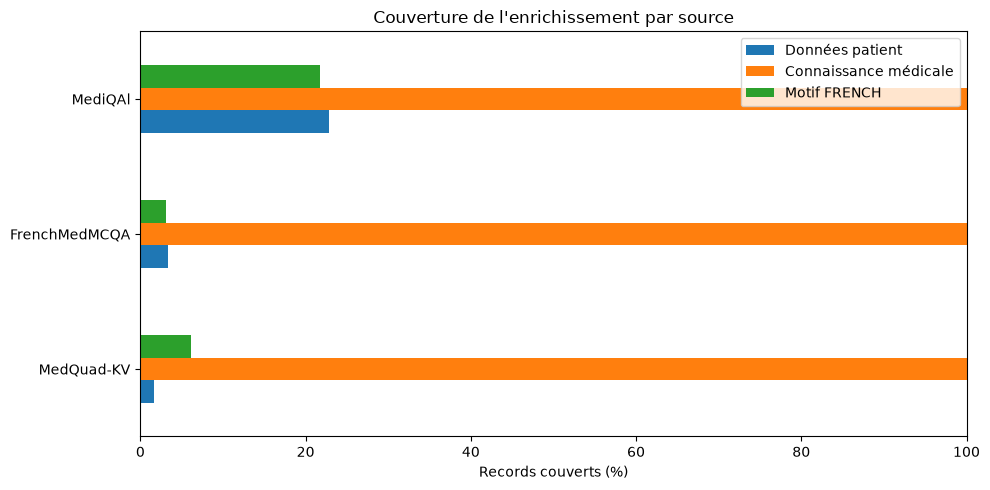

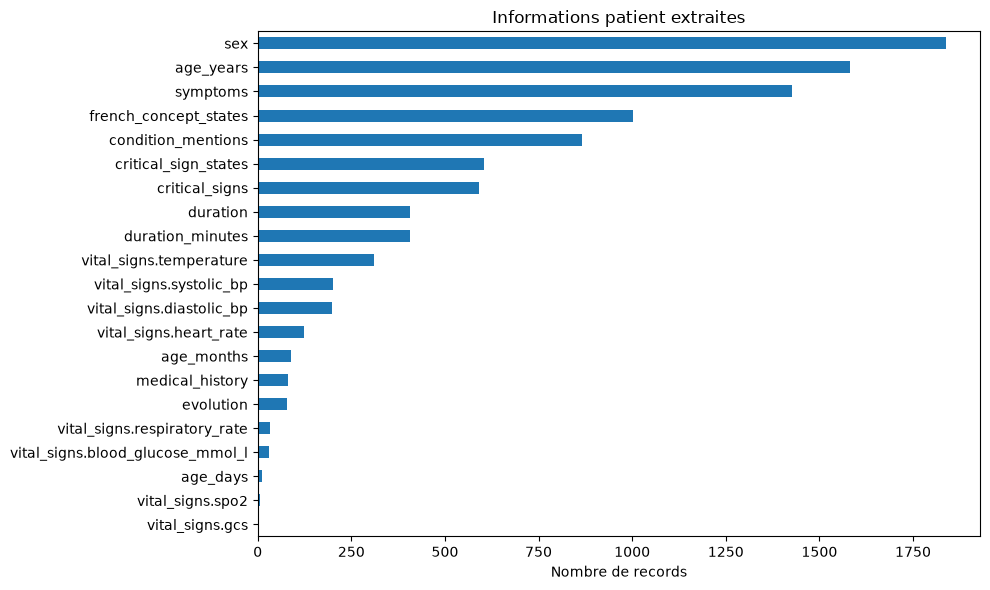

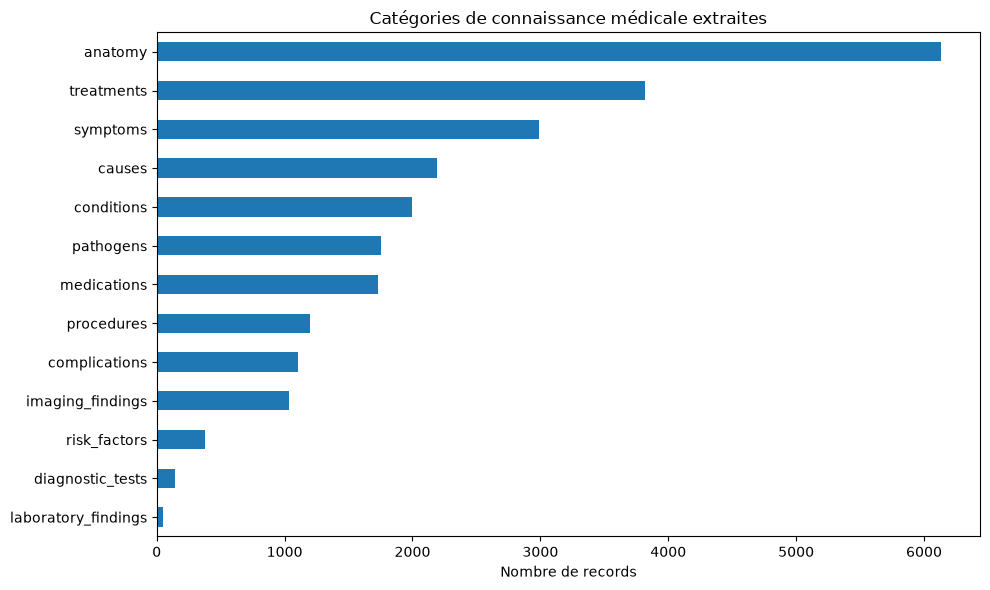

✓ SFT=29,151 | Motifs FRENCH=100/115


In [137]:
# Intégrité
# Vérifie IDs, structures, hashes et motifs FRENCH du checkpoint SFT.

if not clinical_enriched_records:
    raise ValueError("Aucun record clinique enrichi.")

ids = [r.get("id") for r in clinical_enriched_records]

if not all(ids) or len(ids) != len(set(ids)):
    raise ValueError("IDs absents ou dupliqués.")

for r in clinical_enriched_records:
    patient = r.get("patient")
    knowledge = r.get("medical_knowledge")
    metadata = r.get("medical_extraction")
    source_hash = r.get("clean_content_hash")

    if not all(isinstance(x, dict) for x in [patient, knowledge, metadata]):
        raise ValueError(f"Extraction incomplète : {r['id']}")

    if not source_hash or any(
        meta.get("source_clean_content_hash") != source_hash
        for meta in [patient.get("extraction") or {}, metadata]
    ):
        raise ValueError(f"Traçabilité incohérente : {r['id']}")

    if any(
        c.get("rule_id") not in FRENCH_MOTIF_LEXICON
        for c in patient.get("french_motif_candidates") or []
    ):
        raise ValueError(f"Motif FRENCH inconnu : {r['id']}")


# Indicateurs
# Sépare données patient, connaissance médicale, motifs FRENCH et conflits.

rows = []

for r in clinical_enriched_records:
    patient = r["patient"]
    meta = patient.get("extraction") or {}
    knowledge = r["medical_knowledge"]

    rows.append({
        "source": r.get("source") or "UNKNOWN",
        "language": clean_text(r.get("language")).lower(),
        "clinical": bool(meta.get("extracted_fields")),
        "knowledge": bool(knowledge.get("has_medical_information")),
        "correct_answer": bool(knowledge.get("has_correct_answer")),
        "french_motif": bool(patient.get("french_motif_candidates")),
        "critical_conflict": bool(meta.get("critical_sign_conflicts")),
        "concept_conflict": bool(meta.get("french_concept_conflicts"))
    })

audit_df = pd.DataFrame(rows)


# Comptages
# Compte les champs extraits et mesure la couverture des motifs FRENCH.

patient_field_counts = Counter(
    f
    for r in clinical_enriched_records
    for f in r["patient"].get("extraction", {}).get("extracted_fields", [])
)
medical_field_counts = Counter(
    f
    for r in clinical_enriched_records
    for f in r["medical_knowledge"].get("extracted_fields", [])
)
motif_counts = Counter(
    c["rule_id"]
    for r in clinical_enriched_records
    for c in r["patient"].get("french_motif_candidates", [])
)


# Synthèse
# Affiche les volumes et taux globaux de l'enrichissement clinique.

metrics = {
    "Records": len(audit_df),
    "Données patient": audit_df["clinical"].sum(),
    "Connaissance médicale": audit_df["knowledge"].sum(),
    "Réponse correcte disponible": audit_df["correct_answer"].sum(),
    "Motif FRENCH patient": audit_df["french_motif"].sum(),
    "Conflits critiques": audit_df["critical_conflict"].sum(),
    "Conflits concepts": audit_df["concept_conflict"].sum()
}

summary = pd.DataFrame({
    "Indicateur": metrics.keys(),
    "Nombre": metrics.values()
})
summary["% records"] = (summary["Nombre"] / len(audit_df) * 100).round(1)

display(
    summary.style
    .format({"Nombre": "{:,.0f}", "% records": "{:.1f} %"})
    .hide(axis="index")
)


# Couverture
# Compare les taux d'extraction par source et langue.

coverage = (
    audit_df.groupby(["source", "language"], as_index=False)
    .agg(
        records=("clinical", "size"),
        clinique=("clinical", "mean"),
        connaissance=("knowledge", "mean"),
        reponse_correcte=("correct_answer", "mean"),
        motif_french=("french_motif", "mean")
    )
)

rates = ["clinique", "connaissance", "reponse_correcte", "motif_french"]
coverage[rates] = coverage[rates].mul(100).round(1)

display(
    coverage.style
    .format({
        "records": "{:,.0f}",
        **{c: "{:.1f} %" for c in rates}
    })
    .hide(axis="index")
)


# Graphiques
# Visualise couverture globale puis fréquences des champs patient et médicaux.

plot = (
    audit_df.groupby("source")[["clinical", "knowledge", "french_motif"]]
    .mean().mul(100).sort_values("clinical")
)

ax = plot.plot(kind="barh", figsize=(10, 5))
ax.set(
    title="Couverture de l'enrichissement par source",
    xlabel="Records couverts (%)",
    ylabel="",
    xlim=(0, 100)
)
ax.legend(["Données patient", "Connaissance médicale", "Motif FRENCH"])
plt.tight_layout()
plt.show()

for counts, title in [
    (patient_field_counts, "Informations patient extraites"),
    (medical_field_counts, "Catégories de connaissance médicale extraites")
]:
    series = pd.Series(counts, dtype="int64").sort_values()

    if not series.empty:
        ax = series.plot(kind="barh", figsize=(10, 6))
        ax.set(title=title, xlabel="Nombre de records", ylabel="")
        plt.tight_layout()
        plt.show()


# Rapport
# Conserve les métriques utiles aux prochaines étapes TRIAGE.

clinical_extraction_info = {
    "records": len(audit_df),
    "with_patient_data": int(audit_df["clinical"].sum()),
    "with_medical_knowledge": int(audit_df["knowledge"].sum()),
    "with_correct_answer": int(audit_df["correct_answer"].sum()),
    "with_french_motif": int(audit_df["french_motif"].sum()),
    "critical_conflicts": int(audit_df["critical_conflict"].sum()),
    "concept_conflicts": int(audit_df["concept_conflict"].sum()),
    "distinct_french_motifs": len(motif_counts),
    "french_motifs_total": len(FRENCH_MOTIF_LEXICON),
    "patient_fields": dict(patient_field_counts),
    "medical_knowledge_fields": dict(medical_field_counts),
    "french_motif_matches": dict(motif_counts)
}

print(
    f"✓ SFT={len(audit_df):,} | "
    f"Motifs FRENCH={len(motif_counts):,}/{len(FRENCH_MOTIF_LEXICON):,}"
)

In [144]:
# Validation SFT
# Vérifie le checkpoint final et sa correspondance exacte avec les données en mémoire.

TRIAGE_CLINICAL_EXTRACTION_REPORT_PATH = (
    TRIAGE_DATA_DIR / "1_triage_clinical_extraction_report.json"
)

if not TRIAGE_CLINICAL_EXTRACTED_PATH.exists():
    raise RuntimeError("Checkpoint clinique SFT absent.")

saved = read_jsonl(TRIAGE_CLINICAL_EXTRACTED_PATH)

if (
    len(saved) != len(clinical_enriched_records)
    or {r["id"] for r in saved} != {r["id"] for r in clinical_enriched_records}
):
    raise RuntimeError("Checkpoint clinique SFT incohérent.")


# Rapport
# Sauvegarde les indicateurs du checkpoint validé dans le run courant.

write_json(
    TRIAGE_CLINICAL_EXTRACTION_REPORT_PATH,
    clinical_extraction_info
)

print(f"✓ Checkpoint SFT={len(saved):,} | Intégrité=OK | Rapport=OK")

✓ Checkpoint SFT=29,151 | Intégrité=OK | Rapport=OK


<h3 style="color:#48C9B0;">9.5 Analyse de l'extraction clinique DPO</h3>

Indicateur,Nombre,% branches
Branches,"219,324",100.0 %
Données patient,"103,850",47.4 %
Connaissance médicale,"174,705",79.7 %
Motif FRENCH patient,"97,727",44.6 %
Motif FRENCH knowledge,"97,441",44.4 %
Conflits critiques,16,0.0 %
Conflits concepts,277,0.1 %


field,records,patient,knowledge,patient_motif,knowledge_motif,critical_conflict,concept_conflict
chosen,"73,108",49.2 %,91.8 %,50.9 %,50.8 %,0.0 %,0.2 %
prompt,"73,108",46.1 %,59.2 %,35.3 %,35.1 %,0.0 %,0.1 %
rejected,"73,108",46.7 %,88.0 %,47.5 %,47.4 %,0.0 %,0.1 %


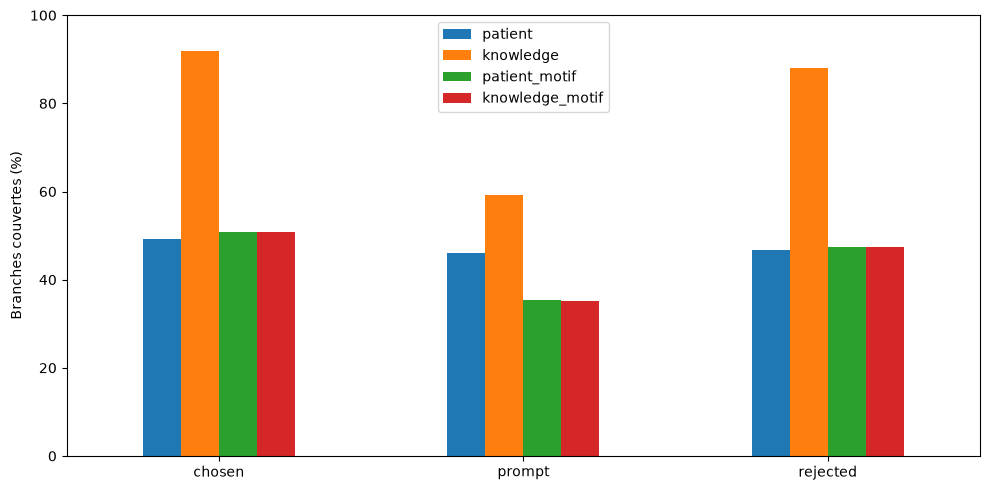

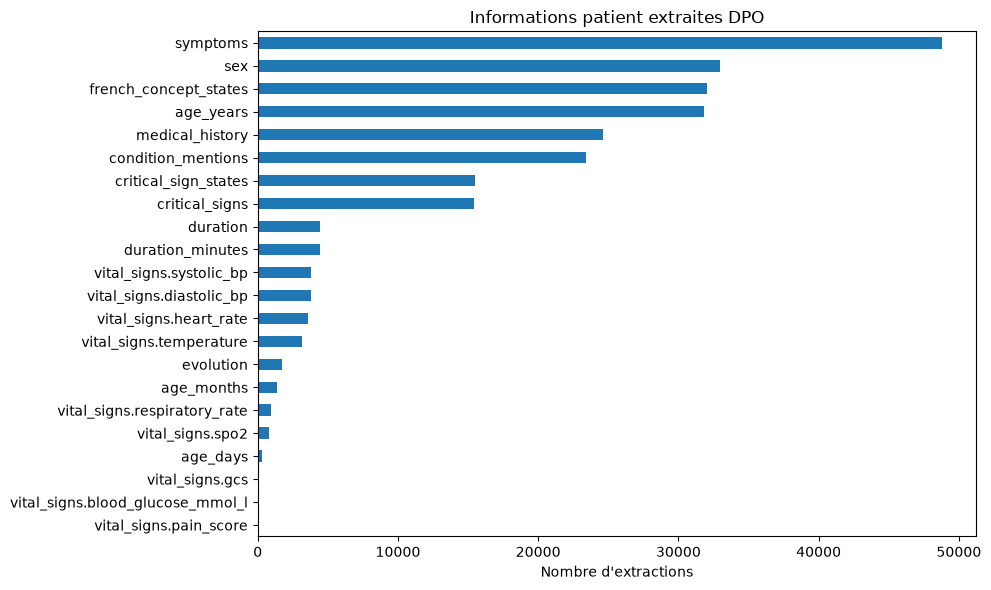

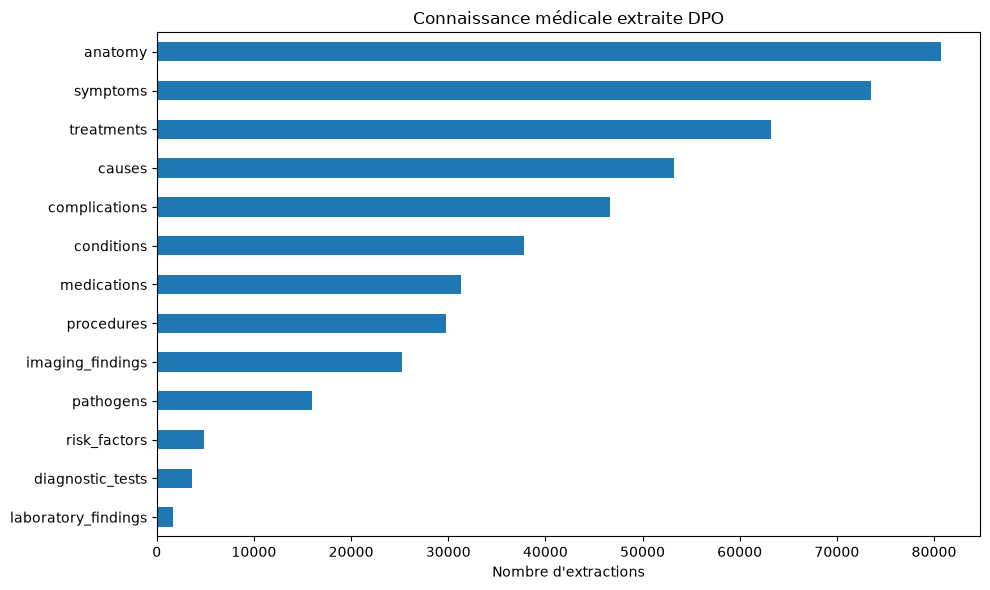

✓ DPO=73,108 | Branches=219,324 | FRENCH patient=113/115 | knowledge=113/115


In [138]:
# Intégrité DPO
# Vérifie IDs, structures, hashes et motifs FRENCH des trois branches.

DPO_FIELDS = ["prompt", "chosen", "rejected"]

if not dpo_clinical_enriched_records:
    raise ValueError("Aucun record DPO enrichi.")

ids = [r.get("id") for r in dpo_clinical_enriched_records]

if not all(ids) or len(ids) != len(set(ids)):
    raise ValueError("IDs DPO absents ou dupliqués.")

for r in dpo_clinical_enriched_records:
    source_hash = r.get("clean_content_hash")

    for field in DPO_FIELDS:
        data = r.get(f"{field}_medical") or {}
        patient = data.get("patient")
        knowledge = data.get("medical_knowledge")
        metadata = data.get("medical_extraction")

        if not source_hash or not all(
            isinstance(x, dict) for x in [patient, knowledge, metadata]
        ):
            raise ValueError(f"Extraction {field} invalide : {r['id']}")

        if metadata.get("source_clean_content_hash") != source_hash:
            raise ValueError(f"Traçabilité {field} incohérente : {r['id']}")

        if any(
            c.get("rule_id") not in FRENCH_MOTIF_LEXICON
            for x in [patient, knowledge]
            for c in x.get("french_motif_candidates") or []
        ):
            raise ValueError(f"Motif FRENCH inconnu : {r['id']}")


# Indicateurs
# Transforme prompt, chosen et rejected en lignes auditables homogènes.

rows = []

for r in dpo_clinical_enriched_records:
    for field in DPO_FIELDS:
        data = r[f"{field}_medical"]
        patient = data.get("patient") or {}
        meta = patient.get("extraction") or {}
        medical = data.get("medical_extraction") or {}

        rows.append({
            "id": r["id"],
            "field": field,
            "source": r.get("source") or "UNKNOWN",
            "patient": bool(medical.get("has_patient_information")),
            "knowledge": bool(medical.get("has_medical_knowledge")),
            "patient_motif": bool(medical.get("patient_french_motifs")),
            "knowledge_motif": bool(medical.get("knowledge_french_motifs")),
            "critical_conflict": bool(meta.get("critical_sign_conflicts")),
            "concept_conflict": bool(meta.get("french_concept_conflicts"))
        })

dpo_audit_df = pd.DataFrame(rows)


# Comptages
# Compte champs médicaux et motifs FRENCH sur l'ensemble des branches.

def dpo_count(path: tuple[str, ...]) -> Counter:
    """Compte les valeurs d'un champ DPO imbriqué."""
    values = []

    for r in dpo_clinical_enriched_records:
        for field in DPO_FIELDS:
            data = r[f"{field}_medical"]

            for key in path:
                data = data.get(key, {})

            values.extend(data or [])

    return Counter(values)

dpo_patient_field_counts = dpo_count(("patient", "extraction", "extracted_fields"))
dpo_medical_field_counts = dpo_count(("medical_knowledge", "extracted_fields"))
dpo_patient_motif_counts = dpo_count(("medical_extraction", "patient_french_motifs"))
dpo_knowledge_motif_counts = dpo_count(("medical_extraction", "knowledge_french_motifs"))


# Synthèse
# Affiche volumes et couverture globale des branches DPO.

metrics = {
    "Branches": len(dpo_audit_df),
    "Données patient": dpo_audit_df["patient"].sum(),
    "Connaissance médicale": dpo_audit_df["knowledge"].sum(),
    "Motif FRENCH patient": dpo_audit_df["patient_motif"].sum(),
    "Motif FRENCH knowledge": dpo_audit_df["knowledge_motif"].sum(),
    "Conflits critiques": dpo_audit_df["critical_conflict"].sum(),
    "Conflits concepts": dpo_audit_df["concept_conflict"].sum()
}

summary = pd.DataFrame({
    "Indicateur": metrics.keys(),
    "Nombre": metrics.values()
})
summary["% branches"] = (
    summary["Nombre"] / len(dpo_audit_df) * 100
).round(1)

display(
    summary.style
    .format({"Nombre": "{:,.0f}", "% branches": "{:.1f} %"})
    .hide(axis="index")
)


# Couverture
# Compare directement prompt, chosen et rejected.

rates = [
    "patient",
    "knowledge",
    "patient_motif",
    "knowledge_motif",
    "critical_conflict",
    "concept_conflict"
]

coverage = (
    dpo_audit_df.groupby("field", as_index=False)
    .agg(records=("id", "size"), **{c: (c, "mean") for c in rates})
)
coverage[rates] = coverage[rates].mul(100).round(1)

display(
    coverage.style
    .format({"records": "{:,.0f}", **{c: "{:.1f} %" for c in rates}})
    .hide(axis="index")
)


# Graphiques
# Visualise la couverture par branche puis les champs patient et médicaux.

plot = dpo_audit_df.groupby("field")[rates[:4]].mean().mul(100)
ax = plot.plot(kind="bar", figsize=(10, 5))
ax.set(xlabel="", ylabel="Branches couvertes (%)", ylim=(0, 100))
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

for counts, title in [
    (dpo_patient_field_counts, "Informations patient extraites DPO"),
    (dpo_medical_field_counts, "Connaissance médicale extraite DPO")
]:
    series = pd.Series(counts, dtype="int64").sort_values()

    if not series.empty:
        ax = series.plot(kind="barh", figsize=(10, 6))
        ax.set(title=title, xlabel="Nombre d'extractions", ylabel="")
        plt.tight_layout()
        plt.show()


# Rapport
# Conserve les métriques DPO nécessaires aux prochaines étapes TRIAGE.

dpo_extraction_info = {
    "records": len(dpo_clinical_enriched_records),
    "branches": len(dpo_audit_df),
    "with_patient_data": int(dpo_audit_df["patient"].sum()),
    "with_medical_knowledge": int(dpo_audit_df["knowledge"].sum()),
    "with_patient_french_motif": int(dpo_audit_df["patient_motif"].sum()),
    "with_knowledge_french_motif": int(dpo_audit_df["knowledge_motif"].sum()),
    "critical_conflicts": int(dpo_audit_df["critical_conflict"].sum()),
    "concept_conflicts": int(dpo_audit_df["concept_conflict"].sum()),
    "distinct_patient_french_motifs": len(dpo_patient_motif_counts),
    "distinct_knowledge_french_motifs": len(dpo_knowledge_motif_counts),
    "french_motifs_total": len(FRENCH_MOTIF_LEXICON),
    "patient_fields": dict(dpo_patient_field_counts),
    "medical_knowledge_fields": dict(dpo_medical_field_counts)
}

print(
    f"✓ DPO={len(dpo_clinical_enriched_records):,} | "
    f"Branches={len(dpo_audit_df):,} | "
    f"FRENCH patient={len(dpo_patient_motif_counts)}/"
    f"{len(FRENCH_MOTIF_LEXICON)} | "
    f"knowledge={len(dpo_knowledge_motif_counts)}/"
    f"{len(FRENCH_MOTIF_LEXICON)}"
)

In [78]:
# Validation DPO
# Vérifie la correspondance exacte entre checkpoint disque et données en mémoire.

DPO_CLINICAL_EXTRACTION_REPORT_PATH = (
    TRIAGE_DATA_DIR / "2_dpo_clinical_extraction_report.json"
)

if not DPO_CLINICAL_EXTRACTED_PATH.exists():
    raise RuntimeError("Checkpoint clinique DPO absent.")

saved = read_jsonl(DPO_CLINICAL_EXTRACTED_PATH)

if (
    len(saved) != len(dpo_clinical_enriched_records)
    or {r["id"] for r in saved} != {r["id"] for r in dpo_clinical_enriched_records}
):
    raise RuntimeError("Checkpoint clinique DPO incohérent.")


# Rapport
# Sauvegarde les indicateurs du checkpoint DPO validé dans le run courant.

write_json(
    DPO_CLINICAL_EXTRACTION_REPORT_PATH,
    dpo_extraction_info
)

print(f"✓ Checkpoint DPO={len(saved):,} | Intégrité=OK | Rapport=OK")

✓ Checkpoint DPO=73,108 | Intégrité=OK | Rapport=OK


In [79]:
# Consolidation DPO
# Patient = prompt, knowledge = prompt + chosen ; rejected reste uniquement traçable.

DPO_PAIR_TRIAGE_SOURCE_PATH = TRIAGE_DATA_DIR / "3_dpo_pair_triage_source.jsonl"

DPO_KNOWLEDGE_FIELDS = [
    "symptoms", "conditions", "complications", "diagnostic_tests",
    "laboratory_findings", "imaging_findings", "risk_factors",
    "treatments", "medications", "procedures", "pathogens", "anatomy"
]


# Fusion knowledge
# Fusionne sans doublons les connaissances et motifs fiables de prompt + chosen.

def merge_dpo_knowledge(record: dict) -> dict:
    """Fusionne la connaissance DPO fiable."""
    merged, fields, motifs = {}, set(), {}

    for branch in ["prompt", "chosen"]:
        knowledge = (
            record.get(f"{branch}_medical") or {}
        ).get("medical_knowledge") or {}

        fields.update(knowledge.get("extracted_fields") or [])

        for field in DPO_KNOWLEDGE_FIELDS:
            value = knowledge.get(field)
            if value not in (None, "", [], {}):
                merged.setdefault(field, []).extend(
                    value if isinstance(value, list) else [value]
                )

        for candidate in knowledge.get("french_motif_candidates") or []:
            if candidate.get("rule_id"):
                motifs.setdefault(candidate["rule_id"], candidate)

    merged.update({
        field: list(dict.fromkeys(map(str, values)))
        for field, values in merged.items()
    })
    merged["extracted_fields"] = sorted(fields)
    merged["french_motif_candidates"] = list(motifs.values())
    merged["has_medical_information"] = bool(fields)
    merged["has_french_motif"] = bool(motifs)

    return merged


# Construction
# Construit une représentation clinique unique par paire en conservant les trois branches.

dpo_pair_triage_records = []

for r in dpo_clinical_enriched_records:
    prompt = r.get("prompt_medical") or {}
    patient = deepcopy(prompt.get("patient") or {})
    knowledge = merge_dpo_knowledge(r)
    patient_fields = patient.get("extraction", {}).get("extracted_fields") or []

    patient_motifs = [
        c["rule_id"] for c in patient.get("french_motif_candidates") or []
        if c.get("rule_id")
    ]
    knowledge_motifs = [
        c["rule_id"] for c in knowledge.get("french_motif_candidates") or []
        if c.get("rule_id")
    ]

    pair = deepcopy(prompt)
    pair.update({
        "id": r["id"],
        "question": dpo_field_text(r, "prompt"),
        "patient": patient,
        "medical_knowledge": knowledge,
        "prompt_medical": prompt,
        "chosen_medical": r.get("chosen_medical") or {},
        "rejected_medical": r.get("rejected_medical") or {},
        "medical_extraction": {
            "method": "dpo_pair_consolidation_v3",
            "has_patient_information": bool(patient_fields),
            "has_medical_knowledge": bool(knowledge["extracted_fields"]),
            "patient_fields": patient_fields,
            "medical_knowledge_fields": knowledge["extracted_fields"],
            "patient_french_motifs": patient_motifs,
            "knowledge_french_motifs": knowledge_motifs,
            "source_clean_content_hash": r.get("clean_content_hash")
        },
        "dpo_pair": {
            "chosen": r.get("chosen"),
            "rejected": r.get("rejected")
        }
    })
    dpo_pair_triage_records.append(pair)


# Validation et export
# Vérifie volume, unicité et structures cliniques avant sauvegarde.

ids = [r["id"] for r in dpo_pair_triage_records]

if (
    len(ids) != len(dpo_clinical_enriched_records)
    or len(ids) != len(set(ids))
):
    raise RuntimeError("Consolidation DPO incomplète ou dupliquée.")

if any(
    not isinstance(r.get(field), dict)
    for r in dpo_pair_triage_records
    for field in ["patient", "medical_knowledge"]
):
    raise RuntimeError("Structure clinique DPO invalide.")

write_jsonl(DPO_PAIR_TRIAGE_SOURCE_PATH, dpo_pair_triage_records)


# Résultat
# Résume la disponibilité patient, knowledge et motifs FRENCH consolidés.

meta = [r["medical_extraction"] for r in dpo_pair_triage_records]

print(
    f"✓ DPO={len(meta):,} | "
    f"Patient={sum(m['has_patient_information'] for m in meta):,} | "
    f"Knowledge={sum(m['has_medical_knowledge'] for m in meta):,} | "
    f"Motifs patient={sum(bool(m['patient_french_motifs']) for m in meta):,} | "
    f"knowledge={sum(bool(m['knowledge_french_motifs']) for m in meta):,}"
)
print(f"✓ {DPO_PAIR_TRIAGE_SOURCE_PATH}")

✓ DPO=73,108 | Patient=33,725 | Knowledge=68,631 | Motifs patient=25,821 | knowledge=39,979
✓ c:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\data\processed\runs\20260918_205745\data\3_dpo_pair_triage_source.jsonl


<h3 style="color:#48C9B0;">9.6 Routage TRIAGE SFT/DPO</h3>

In [145]:
# Routage TRIAGE
# Définit les entrées/sorties du run puis route séparément SFT et DPO.

SFT_SOURCE_PATH = TRIAGE_DATA_DIR / "1_triage_clinical_extracted.jsonl"
DPO_SOURCE_PATH = TRIAGE_DATA_DIR / "3_dpo_pair_triage_source.jsonl"
SFT_ROUTING_PATH = TRIAGE_DATA_DIR / "4_triage_routing.jsonl"
DPO_ROUTING_PATH = TRIAGE_DATA_DIR / "5_dpo_triage_routing.jsonl"

sft_routes = create_triage_routing(SFT_SOURCE_PATH, SFT_ROUTING_PATH)
dpo_routes = create_triage_routing(DPO_SOURCE_PATH, DPO_ROUTING_PATH)


# Validation
# Vérifie qu'une route existe pour chaque record source.

if sum(sft_routes.values()) != len(clinical_enriched_records):
    raise RuntimeError("Routage SFT incomplet.")

if sum(dpo_routes.values()) != len(dpo_pair_triage_records):
    raise RuntimeError("Routage DPO incomplet.")

print(
    f"✓ Routage | SFT={sum(sft_routes.values()):,} | "
    f"DPO={sum(dpo_routes.values()):,}"
)

✓ Routage | SFT=29,151 | DPO=73,108


 <h3 style="color:#48C9B0;">9.7 Audit des entrées TRIAGE SFT/DPO</h3>

In [82]:
# Audit TRIAGE
# Vérifie volumes, routage, hashes et protocole des flux SFT et DPO.

TRIAGE_AUDITS = {
    "SFT": (TRIAGE_CLINICAL_EXTRACTED_PATH, SFT_ROUTING_PATH),
    "DPO": (DPO_PAIR_TRIAGE_SOURCE_PATH, DPO_ROUTING_PATH)
}

triage_audit_reports = {}

for name, (source, routing) in TRIAGE_AUDITS.items():
    report = audit_triage_inputs(source, routing, PROTOCOL_PATH)
    triage_audit_reports[name] = report

    records = report["rows"]["records"]
    routed = report["rows"]["routing"]

    print(
        f"\n{name} | Records={records:,} | Routés={routed:,} | "
        f"Hash={len(report['hash_mismatches']):,}"
    )

    for route, count in report["route_counts"].items():
        print(
            f"{route:<24} {count:>7,} "
            f"({count / routed * 100 if routed else 0:5.1f} %)"
        )

    if not report["valid"]:
        raise RuntimeError(f"Audit TRIAGE {name} invalide.")

print("\n✓ Audits TRIAGE SFT/DPO : OK")


SFT | Records=29,151 | Routés=29,151 | Hash=0
controlled_synthesis      24,163 ( 82.9 %)
human_review               3,535 ( 12.1 %)
protocol_annotation        1,453 (  5.0 %)

DPO | Records=73,108 | Routés=73,108 | Hash=0
human_review              50,211 ( 68.7 %)
protocol_annotation       19,636 ( 26.9 %)
triage_rejected            3,261 (  4.5 %)

✓ Audits TRIAGE SFT/DPO : OK


<h3 style="color:#48C9B0;">9.8 Application du TRIAGE SFT/DPO</h3>

In [164]:
# Résultats TRIAGE
# Centralise les décisions SFT et DPO produites par le moteur.

triage_results = {}

In [178]:
# TRIAGE SFT
# Applique le moteur aux routes automatiques et conserve le contexte SFT.

SFT_DECISIONS_PATH = TRIAGE_DATA_DIR / "6_triage_protocol_decisions.jsonl"
AUTOMATIC_TRIAGE_ROUTES = {"protocol_annotation", "controlled_synthesis"}

sft_records = read_jsonl(TRIAGE_CLINICAL_EXTRACTED_PATH)
sft_routes = {
    r["id"]: r["triage_route"]
    for r in read_jsonl(SFT_ROUTING_PATH)
}
sft_selected = [
    r for r in sft_records
    if sft_routes.get(r["id"]) in AUTOMATIC_TRIAGE_ROUTES
]

sft_decisions = automatic_triage_engine.build_decisions(sft_selected)
write_jsonl(SFT_DECISIONS_PATH, sft_decisions)
triage_results["SFT"] = sft_decisions

print(
    f"SFT | Records={len(sft_records):,} | Moteur={len(sft_selected):,} | "
    f"Hors moteur={len(sft_records) - len(sft_selected):,}"
)
print("Méthodes =", dict(Counter(r["decision_method"] for r in sft_decisions)))
print("Priorités =", dict(Counter(r["priority"] for r in sft_decisions)))

SFT | Records=29,151 | Moteur=25,616 | Hors moteur=3,535
Méthodes = {'no_knowledge_motif': 17202, 'knowledge_priority_conflict': 3905, 'knowledge_reference': 3247, 'knowledge_common_priority_review': 746, 'knowledge_full_convergence_review': 516}
Priorités = {None: 22369, 3: 1622, 1: 470, 2: 1155}


In [184]:
# Pool SFT avec connaissance FRENCH exploitable
TARGET_METHODS = {
    "knowledge_reference",
    "knowledge_priority_conflict",
    "knowledge_common_priority_review",
    "knowledge_full_convergence_review"
}

decision_by_id = {
    d["id"]: d
    for d in sft_decisions
    if d["decision_method"] in TARGET_METHODS
}

french_sft_candidate_pool = [
    {
        **r,
        "triage_engine_decision": decision_by_id[r["id"]]
    }
    for r in sft_selected
    if r["id"] in decision_by_id
]

print(f"Pool FRENCH SFT exploitable : {len(french_sft_candidate_pool):,}")

Pool FRENCH SFT exploitable : 8,414


In [ ]:
# Cas avec connaissance FRENCH mais sans priorité définitive
REVIEW_METHODS = {
    "knowledge_priority_conflict",
    "knowledge_common_priority_review",
    "knowledge_full_convergence_review"
}

review_pool = [
    r for r in french_sft_candidate_pool
    if r["triage_engine_decision"]["decision_method"] in REVIEW_METHODS
    and r["triage_engine_decision"]["priority"] is None
]

print(f"À résoudre : {len(review_pool):,}")

print(
    pd.Series(
        r["triage_engine_decision"]["decision_method"]
        for r in review_pool
    ).value_counts()
)

À résoudre : 5,167
knowledge_priority_conflict          3905
knowledge_common_priority_review      746
knowledge_full_convergence_review     516
Name: count, dtype: int64


In [179]:
# TRIAGE DPO
# Applique le même moteur et conserve un contexte DPO indépendant.

DPO_DECISIONS_PATH = TRIAGE_DATA_DIR / "7_dpo_triage_protocol_decisions.jsonl"

dpo_records = read_jsonl(DPO_PAIR_TRIAGE_SOURCE_PATH)
dpo_routes = {
    r["id"]: r["triage_route"]
    for r in read_jsonl(DPO_ROUTING_PATH)
}
dpo_selected = [
    r for r in dpo_records
    if dpo_routes.get(r["id"]) in AUTOMATIC_TRIAGE_ROUTES
]

dpo_decisions = automatic_triage_engine.build_decisions(dpo_selected)
write_jsonl(DPO_DECISIONS_PATH, dpo_decisions)
triage_results["DPO"] = dpo_decisions

print(
    f"DPO | Records={len(dpo_records):,} | Moteur={len(dpo_selected):,} | "
    f"Hors moteur={len(dpo_records) - len(dpo_selected):,}"
)
print("Méthodes =", dict(Counter(r["decision_method"] for r in dpo_decisions)))
print("Priorités =", dict(Counter(r["priority"] for r in dpo_decisions)))

DPO | Records=73,108 | Moteur=19,636 | Hors moteur=53,472
Méthodes = {'knowledge_priority_conflict': 12348, 'knowledge_reference': 3961, 'knowledge_common_priority_review': 2174, 'knowledge_full_convergence_review': 1073, 'no_knowledge_motif': 80}
Priorités = {None: 15675, 1: 594, 2: 1587, 3: 1780}


In [183]:
# Pool SFT avec connaissance FRENCH exploitable
TARGET_METHODS = {
    "knowledge_reference",
    "knowledge_priority_conflict",
    "knowledge_common_priority_review",
    "knowledge_full_convergence_review"
}

decision_by_id = {
    d["id"]: d
    for d in dpo_decisions
    if d["decision_method"] in TARGET_METHODS
}

french_dpo_candidate_pool = [
    {
        **r,
        "triage_engine_decision": decision_by_id[r["id"]]
    }
    for r in dpo_selected
    if r["id"] in decision_by_id
]

print(f"Pool FRENCH DPO exploitable : {len(french_dpo_candidate_pool):,}")

Pool FRENCH DPO exploitable : 19,556


In [186]:
# Cas avec connaissance FRENCH mais sans priorité définitive
REVIEW_METHODS = {
    "knowledge_priority_conflict",
    "knowledge_common_priority_review",
    "knowledge_full_convergence_review"
}

review_pool = [
    r for r in french_dpo_candidate_pool
    if r["triage_engine_decision"]["decision_method"] in REVIEW_METHODS
    and r["triage_engine_decision"]["priority"] is None
]

print(f"À résoudre : {len(review_pool):,}")

print(
    pd.Series(
        r["triage_engine_decision"]["decision_method"]
        for r in review_pool
    ).value_counts()
)

À résoudre : 15,595
knowledge_priority_conflict          12348
knowledge_common_priority_review      2174
knowledge_full_convergence_review     1073
Name: count, dtype: int64


<h3 style="color:#48C9B0;">9.9 Création revue humaine pour SFT</h3>

In [90]:
# Revue humaine SFT
# Construit la file des records human_review avec leurs preuves cliniques.

SFT_REVIEW_QUEUE_PATH = TRIAGE_DATA_DIR / "8_routing_human_review_queue.jsonl"

routes = {r["id"]: r for r in read_jsonl(SFT_ROUTING_PATH)}
routing_review_queue = []

for record in clinical_enriched_records:
    route = routes.get(record["id"], {})

    if route.get("triage_route") != "human_review":
        continue

    medical = record.get("medical_extraction") or {}

    routing_review_queue.append({
        **record,
        "routing": route,
        "review_context": {
            "current_priority": route.get("priority"),
            "routing_reason": route.get("routing_reason"),
            "patient_motifs": medical.get("patient_french_motifs", []),
            "knowledge_motifs": medical.get("knowledge_french_motifs", [])
        }
    })


# Validation et export
# Vérifie unicité et couverture complète des routes human_review.

ids = [r["id"] for r in routing_review_queue]
expected = sum(
    r.get("triage_route") == "human_review"
    for r in routes.values()
)

if len(ids) != len(set(ids)):
    raise RuntimeError("IDs dupliqués dans la revue SFT.")

if len(ids) != expected:
    raise RuntimeError(
        f"File human_review incomplète : {len(ids):,}/{expected:,}."
    )

write_jsonl(SFT_REVIEW_QUEUE_PATH, routing_review_queue)

print(
    f"✓ Human review SFT={len(ids):,}/{expected:,} | "
    f"{SFT_REVIEW_QUEUE_PATH}"
)

✓ Human review SFT=3,535/3,535 | c:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\data\processed\runs\20260918_205745\data\8_routing_human_review_queue.jsonl


## protocol revue

In [189]:
# Revue des décisions moteur SFT
# Regroupe les cas FRENCH non résolus avec leur record clinique complet.

SFT_ENGINE_REVIEW_PATH = TRIAGE_DATA_DIR / "8_protocol_review_queue.jsonl"

REVIEW_METHODS = {
    "knowledge_priority_conflict",
    "knowledge_common_priority_review",
    "knowledge_full_convergence_review"
}

decision_by_id = {
    d["id"]: d
    for d in sft_decisions
    if d["decision_method"] in REVIEW_METHODS
}

sft_engine_review_queue = [
    {
        **record,
        "triage_decision": decision_by_id[record["id"]]
    }
    for record in sft_selected
    if record["id"] in decision_by_id
]

# Validation et export
ids = [r["id"] for r in sft_engine_review_queue]

if len(ids) != len(set(ids)):
    raise RuntimeError("IDs dupliqués dans la revue moteur SFT.")

if len(ids) != len(decision_by_id):
    raise RuntimeError(
        f"File moteur incomplète : {len(ids):,}/{len(decision_by_id):,}."
    )

write_jsonl(SFT_ENGINE_REVIEW_PATH, sft_engine_review_queue)

print(
    f"✓ Revue moteur SFT={len(ids):,}/{len(decision_by_id):,} | "
    f"{SFT_ENGINE_REVIEW_PATH}"
)

✓ Revue moteur SFT=5,167/5,167 | c:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\data\processed\runs\20260918_205745\data\8_protocol_review_queue.jsonl


<h3 style="color:#48C9B0;">9.10 Application de la revue humaine pour SFT</h3>

In [192]:
# Décisions humaines SFT
# Nettoie, valide et partitionne les décisions de revue.

SFT_REVIEW_DECISIONS_PATH = TRIAGE_DATA_DIR / "9_routing_human_review_decisions.jsonl"

queue_ids = {r["id"] for r in routing_review_queue}
reviews = (
    read_jsonl(SFT_REVIEW_DECISIONS_PATH)
    if SFT_REVIEW_DECISIONS_PATH.exists() else []
)

kept = [r for r in reviews if r.get("id") in queue_ids]
review_by_id = {r["id"]: r for r in kept}

if len(review_by_id) != len(kept):
    raise ValueError("Décisions humaines dupliquées.")

for review in kept:
    if review.get("decision") not in {"approve", "reject", "review"}:
        raise ValueError(f"Décision invalide : {review['id']}")
    if review.get("priority") not in {None, 1, 2, 3}:
        raise ValueError(f"Priorité invalide : {review['id']}")

write_jsonl(SFT_REVIEW_DECISIONS_PATH, kept)


# Partition
# Sépare les décisions approuvées, rejetées et restantes.

approved_review, rejected_review, pending_review = [], [], []

for record in routing_review_queue:
    review = review_by_id.get(record["id"])
    enriched = {**record, **({"human_triage_review": review} if review else {})}

    if review and review.get("decision") == "approve" \
            and review.get("priority") in {1, 2, 3}:
        approved_review.append(enriched)
    elif review and review.get("decision") == "reject":
        rejected_review.append(enriched)
    else:
        pending_review.append(enriched)


# Résultats
# Vérifie la partition et affiche les priorités approuvées.

if len(approved_review) + len(rejected_review) + len(pending_review) != len(
    routing_review_queue
):
    raise RuntimeError("Partition de la revue humaine incohérente.")

priorities = Counter(
    r["human_triage_review"]["priority"]
    for r in approved_review
)

print(
    f"File={len(routing_review_queue):,} | "
    f"Décisions={len(reviews):,} | Conservées={len(kept):,} | "
    f"Supprimées={len(reviews) - len(kept):,}"
)
print(
    f"Approuvés={len(approved_review):,} | Rejetés={len(rejected_review):,} | "
    f"Restants={len(pending_review):,}"
)
print(f"P1={priorities[1]:,} | P2={priorities[2]:,} | P3={priorities[3]:,}")

File=3,535 | Décisions=3,535 | Conservées=3,535 | Supprimées=0
Approuvés=665 | Rejetés=1,828 | Restants=1,042
P1=184 | P2=363 | P3=118


In [194]:
# Décisions de revue protocole SFT
# Nettoie, valide et applique les décisions à la file moteur.

SFT_PROTOCOL_DECISIONS_PATH = TRIAGE_DATA_DIR / "9_protocol_review_decisions.jsonl"

queue_ids = {r["id"] for r in sft_engine_review_queue}
reviews = (
    read_jsonl(SFT_PROTOCOL_DECISIONS_PATH)
    if SFT_PROTOCOL_DECISIONS_PATH.exists() else []
)

kept = [r for r in reviews if r.get("id") in queue_ids]
review_by_id = {r["id"]: r for r in kept}

if len(review_by_id) != len(kept):
    raise ValueError("Décisions protocole dupliquées.")

for review in kept:
    if review.get("decision") not in {"approve", "reject", "review"}:
        raise ValueError(f"Décision invalide : {review['id']}")
    if review.get("priority") not in {None, 1, 2, 3}:
        raise ValueError(f"Priorité invalide : {review['id']}")

write_jsonl(SFT_PROTOCOL_DECISIONS_PATH, kept)


# Partition
# Sépare les décisions approuvées, rejetées et restantes.

approved_protocol, rejected_protocol, pending_protocol = [], [], []

for record in sft_engine_review_queue:
    review = review_by_id.get(record["id"])
    enriched = {**record, **({"protocol_triage_review": review} if review else {})}

    if review and review.get("decision") == "approve" \
            and review.get("priority") in {1, 2, 3}:
        approved_protocol.append(enriched)
    elif review and review.get("decision") == "reject":
        rejected_protocol.append(enriched)
    else:
        pending_protocol.append(enriched)


# Résultats
# Vérifie la partition et affiche les priorités attribuées.

if sum(map(len, [
    approved_protocol,
    rejected_protocol,
    pending_protocol
])) != len(sft_engine_review_queue):
    raise RuntimeError("Partition de la revue protocole incohérente.")

priorities = Counter(
    r["protocol_triage_review"]["priority"]
    for r in approved_protocol
)

print(
    f"File={len(sft_engine_review_queue):,} | "
    f"Décisions={len(reviews):,} | Conservées={len(kept):,} | "
    f"Supprimées={len(reviews) - len(kept):,}"
)
print(
    f"Approuvés={len(approved_protocol):,} | "
    f"Rejetés={len(rejected_protocol):,} | "
    f"Restants={len(pending_protocol):,}"
)
print(f"P1={priorities[1]:,} | P2={priorities[2]:,} | P3={priorities[3]:,}")

File=5,167 | Décisions=5,167 | Conservées=5,167 | Supprimées=0
Approuvés=764 | Rejetés=0 | Restants=4,403
P1=185 | P2=530 | P3=49


<h3 style="color:#48C9B0;">9.11 Consolidation des décisions TRIAGE SFT</h3>

In [195]:
# Consolidation SFT
# Résout la revue protocole puis ajoute les cas de routage approuvés.

protocol_by_id = {
    r["id"]: r["protocol_triage_review"]
    for r in approved_protocol
}

sft_final_decisions = []

for decision in triage_results["SFT"]:
    review = protocol_by_id.get(decision["id"])

    if review:
        decision = {
            **decision,
            "priority": review["priority"],
            "decision_method": "protocol_review",
            "reason": review.get("reason"),
            "confidence": review.get("confidence"),
            "confidence_score": 1.0 if review.get("confidence") == "high" else 0.7
        }

    sft_final_decisions.append(decision)


# Revue de routage
# Ajoute les records initialement exclus du moteur puis approuvés.

sft_final_decisions.extend({
    "id": r["id"],
    "priority": r["human_triage_review"]["priority"],
    "decision_method": "routing_review",
    "rule_ids": r["human_triage_review"].get("rule_ids") or [],
    "reference_french_levels": (
        r["human_triage_review"].get("reference_french_levels") or []
    ),
    "reason": r["human_triage_review"].get("reason"),
    "confidence": r["human_triage_review"].get("confidence"),
    "confidence_score": 1.0
}
for r in approved_review)


# Validation
# Garantit une décision unique par record.

decision_by_id = {r["id"]: r for r in sft_final_decisions}

if len(decision_by_id) != len(sft_final_decisions):
    raise RuntimeError("Décisions TRIAGE SFT dupliquées.")

priorities = Counter(
    r.get("priority")
    for r in sft_final_decisions
    if r.get("priority") in {1, 2, 3}
)

print(
    f"✓ Moteur={len(triage_results['SFT']):,} | "
    f"Protocole={len(approved_protocol):,} | "
    f"Routage={len(approved_review):,} | "
    f"Total={len(sft_final_decisions):,}"
)
print(
    f"✓ P1={priorities[1]:,} | "
    f"P2={priorities[2]:,} | "
    f"P3={priorities[3]:,}"
)

✓ Moteur=25,616 | Protocole=764 | Routage=665 | Total=26,281
✓ P1=839 | P2=2,048 | P3=1,789


<h3 style="color:#48C9B0;">9.12 Références TRIAGE DPO</h3>

In [196]:
# Références TRIAGE DPO
# Qualifie la référence FRENCH de chaque paire sans filtrer le pool.

DPO_REFERENCE_PATH = TRIAGE_DATA_DIR / "10_dpo_triage_reference_pool.jsonl"

SAFE_DPO_METHODS = {
    "exact_rule", "exact_rule_convergence", "deterministic_unique",
    "deterministic_same_priority", "deterministic_evidence_dominance",
    "deterministic_multi_evidence_dominance"
}
SUPPORTED_DPO_METHODS = {
    "knowledge_reference", "knowledge_full_convergence",
    "knowledge_common_priority"
}
AMBIGUOUS_DPO_METHODS = {
    "deterministic_priority_conflict", "exact_rule_conflict",
    "knowledge_priority_conflict", "unsupported_protocol_rule",
    "no_matching_criterion"
}

dpo_decision_by_id = {r["id"]: r for r in triage_results["DPO"]}


# Classification
# Distingue références fortes, supportées, ambiguës ou absentes.

def dpo_reference_status(decision: dict | None) -> str:
    """Classe une référence TRIAGE DPO."""
    if not decision:
        return "none"

    method = decision.get("decision_method")
    priority = decision.get("priority")

    if priority in {1, 2, 3}:
        if method in SAFE_DPO_METHODS:
            return "strong"
        if method in SUPPORTED_DPO_METHODS:
            return "supported"

    if method in AMBIGUOUS_DPO_METHODS or decision.get("candidate_priorities"):
        return "ambiguous"

    return "none"


# Construction
# Ajoute la référence TRIAGE à chaque paire DPO sans supprimer aucun record.

dpo_reference_records = []

for record in dpo_pair_triage_records:
    decision = dpo_decision_by_id.get(record["id"]) or {}
    priority = decision.get("priority")

    dpo_reference_records.append({
        **record,
        "triage_reference": {
            "status": dpo_reference_status(decision),
            "priority": priority if priority in {1, 2, 3} else None,
            "decision_method": decision.get("decision_method"),
            "confidence_score": decision.get("confidence_score"),
            "rule_ids": decision.get("rule_ids") or [],
            "candidate_priorities": decision.get("candidate_priorities") or [],
            "candidate_french_levels": (
                decision.get("candidate_french_levels") or []
            )
        }
    })


# Validation et export
# Garantit conservation exacte des IDs et unicité du pool DPO.

source_ids = {r["id"] for r in dpo_pair_triage_records}
reference_ids = [r["id"] for r in dpo_reference_records]

if set(reference_ids) != source_ids:
    raise RuntimeError("Perte d'IDs pendant la classification DPO.")

if len(reference_ids) != len(set(reference_ids)):
    raise RuntimeError("IDs DPO dupliqués.")

write_jsonl(DPO_REFERENCE_PATH, dpo_reference_records)


# Résultats
# Résume statuts, priorités et méthodes de référence obtenus.

statuses = Counter(r["triage_reference"]["status"] for r in dpo_reference_records)
priorities = Counter(r["triage_reference"]["priority"] for r in dpo_reference_records)
methods = Counter(r["triage_reference"]["decision_method"] for r in dpo_reference_records)

print(
    f"DPO={len(dpo_reference_records):,} | Strong={statuses['strong']:,} | "
    f"Supported={statuses['supported']:,} | Ambiguous={statuses['ambiguous']:,} | "
    f"None={statuses['none']:,}"
)
print(
    f"P1={priorities[1]:,} | P2={priorities[2]:,} | "
    f"P3={priorities[3]:,} | Sans priorité={priorities[None]:,}"
)
print(f"Méthodes={dict(methods)}")
print(f"✓ {DPO_REFERENCE_PATH}")

DPO=73,108 | Strong=0 | Supported=3,961 | Ambiguous=15,595 | None=53,552
P1=594 | P2=1,587 | P3=1,780 | Sans priorité=69,147
Méthodes={None: 53472, 'knowledge_priority_conflict': 12348, 'knowledge_reference': 3961, 'knowledge_common_priority_review': 2174, 'knowledge_full_convergence_review': 1073, 'no_knowledge_motif': 80}
✓ c:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\data\processed\runs\20260918_205745\data\10_dpo_triage_reference_pool.jsonl


<h3 style="color:#48C9B0;">9.13 Candidats LLM Judge SFT</h3>

In [197]:
# Candidats LLM Judge SFT
# Prépare uniquement les conflits protocole encore non résolus.

LLM_RECORDS_PATH = TRIAGE_DATA_DIR / "11_llm_judge_candidates.jsonl"

protocol_by_rule = {
    r["rule_id"]: r
    for r in TRIAGE_PROTOCOL["motifs"]
}


# Règles FRENCH
# Retourne les règles associées aux candidats de la décision moteur.

def protocol_rules(rule_ids: list[str]) -> list[dict]:
    """Retourne les règles FRENCH utiles."""
    return [
        {
            "rule_id": rule_id,
            "section": rule.get("section"),
            "motif": rule.get("motif"),
            "triage_levels": rule.get("triage_levels")
        }
        for rule_id in rule_ids
        if (rule := protocol_by_rule.get(rule_id))
    ]


# Construction
# Envoie au Judge les seuls cas protocole encore ambigus.

judge_candidates = []

for record in pending_protocol:
    decision = record.get("triage_decision") or {}
    review = record.get("protocol_triage_review") or {}

    rule_ids = decision.get("rule_ids") or []

    judge_candidates.append({
        "id": record["id"],
        "language": record.get("language") or record.get("detected_language"),
        "source": record.get("source"),
        "question": record.get("question"),
        "context": record.get("context"),
        "answer": record.get("answer"),
        "patient": record.get("patient") or {},
        "critical_signs": record.get("critical_signs") or [],
        "vital_signs": record.get("vital_signs") or {},
        "symptoms": record.get("symptoms") or [],
        "medical_knowledge": record.get("medical_knowledge") or {},
        "candidate_priorities": decision.get("candidate_priorities") or [],
        "candidate_french_levels": decision.get("candidate_french_levels") or [],
        "decision_method": decision.get("decision_method"),
        "rule_ids": rule_ids,
        "protocol_rules": protocol_rules(rule_ids),
        "review_reason": review.get("reason")
    })


# Validation et export
# Garantit unicité et absence de priorité déjà résolue.

ids = [r["id"] for r in judge_candidates]

if len(ids) != len(set(ids)):
    raise RuntimeError("IDs dupliqués dans le Judge SFT.")

if any(r["id"] in {x["id"] for x in approved_protocol} for r in judge_candidates):
    raise RuntimeError("Un cas protocole déjà résolu est envoyé au Judge.")

write_jsonl(LLM_RECORDS_PATH, judge_candidates)


# Résultats
# Contrôle le volume et les informations FRENCH disponibles.

methods = Counter(r["decision_method"] for r in judge_candidates)
with_rules = sum(bool(r["protocol_rules"]) for r in judge_candidates)

print(f"✓ Judge SFT={len(judge_candidates):,}")
print(f"Méthodes={dict(methods)}")
print(
    f"Règles={with_rules:,}/{len(judge_candidates):,} | "
    f"Déjà résolus=0"
)

✓ Judge SFT=4,403
Méthodes={'knowledge_common_priority_review': 558, 'knowledge_priority_conflict': 3368, 'knowledge_full_convergence_review': 477}
Règles=4,403/4,403 | Déjà résolus=0


<h4 style="color:#48C9B0;">9.13.1 Configuration et sélection du LLM Judge SFT</h3>

In [207]:
# Configuration Judge
# Sépare les décisions sûres des conflits protocole soumis à Gemma.

MODEL = "gemma3:4b"
OLLAMA_URL = "http://localhost:11434/api/chat"

SAFE_ENGINE_METHODS = {
    "exact_rule",
    "exact_rule_convergence",
    "deterministic_unique",
    "deterministic_same_priority",
    "deterministic_evidence_dominance",
    "deterministic_multi_evidence_dominance",
    "knowledge_reference"
}

JUDGE_METHODS = {
    "knowledge_priority_conflict",
    "knowledge_common_priority_review",
    "knowledge_full_convergence_review"
}

engine_records = [
    r for r in sft_final_decisions
    if r.get("priority") in {1, 2, 3}
]

judge_records = list(judge_candidates)


# Validation
# Garantit deux pools disjoints et conformes aux méthodes attendues.

engine_ids = {r["id"] for r in engine_records}
judge_ids = {r["id"] for r in judge_records}
unexpected = {
    r["decision_method"]
    for r in judge_records
} - JUDGE_METHODS

if engine_ids & judge_ids:
    raise RuntimeError("Chevauchement moteur / Judge.")

if unexpected:
    raise RuntimeError(f"Méthodes Judge inattendues : {sorted(unexpected)}")

print(
    f"✓ Déjà résolus={len(engine_records):,} | "
    f"Judge={len(judge_records):,}"
)
print("Judge =", dict(Counter(r["decision_method"] for r in judge_records)))

✓ Déjà résolus=4,676 | Judge=4,403
Judge = {'knowledge_common_priority_review': 558, 'knowledge_priority_conflict': 3368, 'knowledge_full_convergence_review': 477}


In [ ]:
SYSTEM_PROMPT = """
Tu es un juge clinique indépendant chargé de résoudre les cas de triage
restés ambigus après l'application déterministe du protocole FRENCH.

Ton objectif est d'attribuer le niveau de priorité permettant à l'hôpital
d'intervenir au moment approprié selon la gravité clinique du patient.

Tu dois distinguer :

P1 = urgence majeure
P2 = urgence modérée
P3 = urgence différée

SOURCE_TEXT contient :
- context
- question

REFERENCE_ANSWER fournit une connaissance médicale complémentaire.
Les extractions automatiques, motifs détectés et règles FRENCH sont des
aides à l'interprétation.

SOURCE_TEXT reste la preuve principale concernant l'état réel du patient.


## 1. Situation patient

Détermine d'abord si SOURCE_TEXT décrit une situation clinique suffisamment
concrète pour permettre un triage.

source_is_patient_case=true si le texte décrit un patient, des symptômes,
signes, constantes, antécédents, circonstances ou une situation clinique
permettant raisonnablement d'évaluer l'urgence.

Une formulation issue d'un cas clinique ou d'un QCM peut être considérée
comme un cas patient si elle décrit effectivement une situation clinique
individualisée.

Une question purement théorique, une définition, une description générale
d'une maladie ou une liste de symptômes possibles ne suffit pas.


## 2. Preuves cliniques

Utilise en priorité les éléments explicitement présents dans SOURCE_TEXT :

- symptômes ;
- signes cliniques ;
- constantes vitales ;
- état neurologique ;
- douleur ;
- traumatisme ;
- saignement ;
- détresse respiratoire ;
- état hémodynamique ;
- évolution aiguë ;
- âge et facteurs de risque lorsqu'ils modifient réellement l'urgence.

REFERENCE_ANSWER peut aider à comprendre le contexte médical mais ne doit
pas transformer une complication seulement possible en signe réellement
présent chez le patient.

N'invente aucun symptôme ou signe absent des données.


## 3. Priorité P1 : urgence majeure

Attribue P1 lorsque les éléments disponibles indiquent une situation grave
nécessitant une prise en charge immédiate ou très rapide afin d'éviter une
menace vitale, fonctionnelle ou une aggravation majeure.

Exemples de critères pouvant soutenir P1 lorsqu'ils sont réellement
présents ou directement établis :

- détresse ou insuffisance respiratoire sévère ;
- arrêt cardiaque ou respiratoire ;
- état de choc ou instabilité hémodynamique ;
- altération majeure de la conscience ou coma ;
- déficit neurologique aigu grave ;
- AVC aigu compatible avec les critères fournis ;
- syndrome coronarien aigu ou infarctus ;
- hémorragie importante ou incontrôlée ;
- anaphylaxie ;
- convulsions prolongées ou état de mal ;
- traumatisme grave ;
- sepsis grave ou choc septique ;
- autre situation explicitement décrite comme immédiatement menaçante
  selon les critères FRENCH fournis.

P1 ne doit pas être réservé aux patients déjà en arrêt vital.
Une situation présentant un risque immédiat sérieux peut justifier P1
si les preuves du cas et le protocole le soutiennent.


## 4. Priorité P2 : urgence modérée

Attribue P2 lorsque le patient nécessite une prise en charge rapide mais
qu'aucun élément suffisamment solide ne justifie P1.

Cela peut notamment correspondre à :

- symptômes aigus significatifs ;
- douleur importante sans instabilité majeure ;
- dyspnée sans détresse respiratoire sévère ;
- saignement significatif mais contrôlé ;
- fracture ou traumatisme sans critère de gravité P1 ;
- déshydratation ou vomissements importants ;
- infection ou fièvre nécessitant une évaluation rapide ;
- aggravation clinique nécessitant une prise en charge urgente ;
- autre situation correspondant aux critères FRENCH de niveau intermédiaire.

La présence d'une pathologie potentiellement grave ne suffit pas à elle
seule pour P1 si les signes de gravité correspondants ne sont pas démontrés.


## 5. Priorité P3 : urgence différée

Attribue P3 lorsque la situation peut raisonnablement attendre davantage
sans élément indiquant une menace immédiate ou une aggravation rapide.

Cela peut notamment correspondre à :

- symptômes légers ;
- état stable ;
- problème chronique sans décompensation aiguë ;
- traumatisme mineur ;
- douleur faible ou modérée sans signe de gravité ;
- situation nécessitant une évaluation médicale mais sans critère P1 ou P2 ;
- autre situation explicitement compatible avec une prise en charge
  différée selon FRENCH.

P3 ne signifie pas absence de besoin médical.
Il signifie que la prise en charge peut être différée par rapport aux
patients P1 et P2.


## 6. Utilisation du protocole FRENCH

candidate_priorities contient les niveaux proposés par les règles FRENCH
applicables au cas.

candidate_french_levels et protocol_rules donnent les informations
protocolaires ayant conduit à ces possibilités.

Utilise ces éléments comme cadre de décision.

Lorsqu'une seule priorité candidate est cohérente avec les preuves
cliniques, privilégie cette priorité.

Lorsqu'il existe plusieurs priorités candidates, tranche selon la gravité
réellement démontrée :

1. rechercher d'abord les critères justifiant P1 ;
2. sinon rechercher les critères justifiant P2 ;
3. sinon retenir P3 si une prise en charge différée est justifiée.

Ne choisis jamais P1 simplement parce que P1 apparaît dans
candidate_priorities.

Inversement, ne refuse pas P1 lorsqu'un critère de gravité suffisamment
explicite le justifie.


## 7. Résolution des conflits

Ton rôle est de résoudre les conflits lorsque les informations disponibles
permettent raisonnablement de le faire.

APPROVE :
les données permettent de défendre une priorité P1, P2 ou P3.

REVIEW :
le cas est clinique mais les informations sont réellement insuffisantes
ou contradictoires pour distinguer les priorités candidates.

REJECT :
le contenu ne constitue pas une situation clinique exploitable pour un
triage ou ne fournit aucune information permettant d'évaluer l'urgence.

Ne choisis pas REVIEW uniquement parce que plusieurs priorités candidates
existent. Essaie d'abord de résoudre le conflit à partir de la gravité,
des preuves explicites et des règles FRENCH.


## 8. Flags

source_is_patient_case :
true si une situation patient exploitable est présente.

evidence_supported :
true si les éléments cliniques nécessaires à la décision sont présents.

motif_supported :
true si le motif FRENCH retenu correspond réellement au cas.

protocol_consistent :
true si l'interprétation est compatible avec les règles FRENCH fournies.

priority_supported :
true uniquement si la priorité choisie est effectivement défendable à
partir des preuves cliniques et du protocole.


## 9. Confidence score

confidence_score mesure la confiance dans la décision :

0.00 à < 0.50 : faible
0.50 à < 0.75 : modérée
0.75 à 1.00 : forte

Une décision APPROVE destinée au SFT doit idéalement avoir une confiance
d'au moins 0.75.


## Règles absolues

- Priorise la gravité clinique et le délai nécessaire de prise en charge.
- Recherche systématiquement les critères P1 avant P2, puis P3.
- N'invente aucune information patient.
- Ne déduis pas automatiquement la gravité à partir du seul nom d'une maladie.
- Un risque potentiel n'est pas automatiquement un signe présent.
- Une complication possible n'est pas automatiquement une complication présente.
- SOURCE_TEXT prévaut pour déterminer l'état réel du patient.
- Utilise FRENCH pour encadrer et départager la décision.
- Ne cherche jamais à équilibrer artificiellement P1, P2 et P3.
- Utilise REVIEW seulement lorsque le conflit ne peut réellement pas être résolu.
- Utilise REJECT lorsqu'il n'existe pas de véritable situation clinique exploitable.

Si decision="approve", priority doit être 1, 2 ou 3.
Si decision="review" ou "reject", priority doit être null.

Réponds uniquement avec un objet JSON contenant exactement :

{
  "decision": "approve|review|reject",
  "priority": null,
  "confidence_score": 0.0,
  "source_is_patient_case": true,
  "evidence_supported": true,
  "motif_supported": true,
  "protocol_consistent": true,
  "priority_supported": true,
  "reason": "justification clinique courte fondée sur les preuves et FRENCH"
}
""".strip()

In [216]:

# Patient et knowledge
# Conserve uniquement les informations utiles au contrôle du Judge.

def compact_fields(data: dict, fields: list[str]) -> dict:
    """Supprime les champs médicaux vides."""
    return {
        field: data[field]
        for field in fields
        if data.get(field) not in (None, "", [], {})
    }


PATIENT_FIELDS = [
    "age_days", "age_months", "age_years", "sex", "vital_signs",
    "symptoms", "medical_history", "critical_signs", "condition_mentions"
]

KNOWLEDGE_FIELDS = [
    "symptoms", "conditions", "complications", "diagnostic_tests",
    "laboratory_findings", "imaging_findings", "risk_factors",
    "treatments", "medications", "procedures"
]

def compact_patient(patient: dict) -> dict:
    """Compacte les preuves patient."""
    return compact_fields(patient, PATIENT_FIELDS)


def compact_knowledge(knowledge: dict) -> dict:
    """Compacte la connaissance médicale."""
    return compact_fields(knowledge, KNOWLEDGE_FIELDS)


# Protocole
# Conserve uniquement les règles FRENCH nécessaires au jugement.

def compact_protocol_rules(candidate: dict) -> list[dict]:
    """Compacte les règles FRENCH."""
    return [
        {
            "rule_id": r.get("rule_id"),
            "motif": r.get("motif"),
            "triage_levels": r.get("triage_levels") or {}
        }
        for r in candidate.get("protocol_rules") or []
    ]


# Prompt candidat
# Assemble les preuves patient et les règles nécessaires à la résolution.

def build_judge_prompt(candidate: dict) -> str:
    """Construit le prompt candidat."""
    payload = {
        "id": candidate["id"],
        "language": candidate.get("language"),
        "source_text": {
            "context": candidate.get("context"),
            "question": candidate.get("question")
        },
        "reference_answer": candidate.get("answer"),
        "extracted_patient": compact_patient(candidate.get("patient") or {}),
        "extracted_knowledge": compact_knowledge(
            candidate.get("medical_knowledge") or {}
        ),
        "candidate_priorities": candidate.get("candidate_priorities") or [],
        "candidate_french_levels": (
            candidate.get("candidate_french_levels") or []
        ),
        "decision_method": candidate.get("decision_method"),
        "rule_ids": candidate.get("rule_ids") or [],
        "protocol_rules": compact_protocol_rules(candidate)
    }

    return json.dumps(payload, ensure_ascii=False)

In [217]:
# Normalisation Judge
# Sécurise décision, priorité, confiance et flags avant validation Pydantic.

# Schéma Judge
# Valide la résolution clinique produite par le LLM.

class JudgeResult(BaseModel):
    """Résolution LLM d'un conflit FRENCH."""

    id: str
    decision: str = Field(pattern="^(approve|review|reject)$")
    priority: int | None = Field(default=None, ge=1, le=3)
    confidence_score: float = Field(ge=0.0, le=1.0)
    source_is_patient_case: bool
    evidence_supported: bool
    motif_supported: bool
    protocol_consistent: bool
    priority_supported: bool
    reason: str
    
def normalize_judge_result(content: dict, candidate: dict) -> dict:
    """Normalise la réponse Ollama."""
    decision = str(content.get("decision", "review")).lower()

    if decision not in {"approve", "review", "reject"}:
        decision = "review"

    try:
        score = float(content.get("confidence_score", 0.5))
    except (TypeError, ValueError):
        score = 0.5

    try:
        priority = int(content["priority"]) if content.get("priority") else None
    except (TypeError, ValueError):
        priority = None

    if priority not in {None, 1, 2, 3}:
        priority = None

    flags = {
        key: bool(content.get(key, False))
        for key in [
            "source_is_patient_case",
            "evidence_supported",
            "motif_supported",
            "protocol_consistent",
            "priority_supported"
        ]
    }


    # Cohérence métier
    # APPROVE exige toutes les preuves et une priorité valide.

    if not flags["source_is_patient_case"]:
        decision = "reject"
        priority = None
    elif decision == "approve" and (
        not all(flags.values()) or priority not in {1, 2, 3}
    ):
        decision = "review"
        priority = None
    elif decision != "approve":
        priority = None

    return {
        "id": candidate["id"],
        "decision": decision,
        "priority": priority,
        "confidence_score": round(max(0.0, min(score, 1.0)), 4),
        **flags,
        "reason": str(
            content.get("reason") or "Réponse incomplète du juge."
        )
    }

<h4 style="color:#48C9B0;">9.13.2 Exécution du LLM Judge SFT</h3>

In [218]:
# Configuration Judge
# Reprend uniquement les candidats absents du fichier de résultats.

MAX_RETRIES = 3
LLM_JUDGE_PATH = TRIAGE_DATA_DIR / "12_llm_judge_audit.jsonl"
LLM_JUDGE_ERROR_PATH = TRIAGE_DATA_DIR / "12_llm_judge_errors.jsonl"


# Helpers
# Classe les verdicts et gère la persistance JSONL.

def is_sft_eligible(r: dict) -> bool:
    """Vérifie l'éligibilité SFT."""
    return (
        r["decision"] == "approve"
        and r.get("priority") in {1, 2, 3}
        and r["confidence_score"] >= 0.75
        and all(r.get(k, False) for k in [
            "source_is_patient_case",
            "evidence_supported",
            "motif_supported",
            "protocol_consistent",
            "priority_supported"
        ])
    )


def judge_status(r: dict) -> str:
    """Classe le verdict."""
    if is_sft_eligible(r):
        return "accepted"
    if r["decision"] == "reject" and r["confidence_score"] >= 0.75:
        return "rejected"
    return "human_review"


def append_jsonl(path: Path, record: dict) -> None:
    """Ajoute une ligne JSONL."""
    with path.open("a", encoding="utf-8") as f:
        f.write(json.dumps(record, ensure_ascii=False) + "\n")


def load_processed_ids(path: Path, valid_ids: set[str]) -> set[str]:
    """Retourne les IDs valides déjà jugés."""
    if not path.exists():
        return set()

    return {
        r["id"]
        for r in read_jsonl(path)
        if r.get("id") in valid_ids
        and r.get("decision") in {"approve", "review", "reject"}
    }


# Jugement
# Interroge Ollama uniquement pour un candidat encore absent.

def judge_record(candidate: dict) -> dict:
    """Juge un candidat SFT."""
    payload = {
        "model": MODEL,
        "stream": False,
        "format": "json",
        "messages": [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": build_judge_prompt(candidate)}
        ],
        "options": {"temperature": 0}
    }

    for attempt in range(MAX_RETRIES):
        try:
            request = urllib.request.Request(
                OLLAMA_URL,
                data=json.dumps(payload).encode(),
                headers={"Content-Type": "application/json"}
            )

            with urllib.request.urlopen(request, timeout=180) as response:
                raw = json.loads(response.read())

            content = json.loads(raw["message"]["content"])
            normalized = normalize_judge_result(content, candidate)

            return JudgeResult(**{
                k: normalized[k]
                for k in JudgeResult.model_fields
            }).model_dump()

        except Exception:
            if attempt == MAX_RETRIES - 1:
                raise
            time.sleep(2 ** attempt)


# Reprise
# Vérifie le fichier 12 uniquement contre les 4 403 candidats actuels.

judge_ids = {r["id"] for r in judge_records}
processed_ids = load_processed_ids(LLM_JUDGE_PATH, judge_ids)

pending_records = [
    r for r in judge_records
    if r["id"] not in processed_ids
]

print(
    f"Pool={len(judge_records):,} | "
    f"Jugés={len(processed_ids):,} | "
    f"Restants={len(pending_records):,}"
)


# Exécution
# Ne lance Ollama que pour les éventuels candidats manquants.

for candidate in tqdm(
    pending_records,
    desc="LLM Judge SFT",
    unit="record",
    dynamic_ncols=True
):
    try:
        result = judge_record(candidate)

        result.update({
            "judge_status": judge_status(result),
            "sft_eligible": is_sft_eligible(result),
            "decision_method": candidate["decision_method"],
            "candidate_priorities": (
                candidate.get("candidate_priorities") or []
            ),
            "language": candidate.get("language")
        })

        append_jsonl(LLM_JUDGE_PATH, result)

    except Exception as exc:
        append_jsonl(LLM_JUDGE_ERROR_PATH, {
            "id": candidate["id"],
            "error": type(exc).__name__,
            "message": str(exc)
        })

print("✓ Jugement SFT terminé")

Pool=4,403 | Jugés=4,403 | Restants=0


LLM Judge SFT: 0record [00:00, ?record/s]

✓ Jugement SFT terminé


In [219]:
# Nettoyage des erreurs
# Retire les erreurs dont l'ID possède maintenant un jugement valide.

judge_ids = {r["id"] for r in judge_records}
processed_ids = load_processed_ids(LLM_JUDGE_PATH, judge_ids)

errors = []

if LLM_JUDGE_ERROR_PATH.exists():
    errors = read_jsonl(LLM_JUDGE_ERROR_PATH)
    errors = [
        r for r in errors
        if r.get("id") not in processed_ids
    ]
    write_jsonl(LLM_JUDGE_ERROR_PATH, errors)


# Contrôle final
# Vérifie les jugements obtenus et les erreurs encore rejouables.

remaining = [
    r for r in judge_records
    if r["id"] not in processed_ids
]

print(
    f"✓ Pool={len(judge_records):,} | "
    f"Jugés={len(processed_ids):,} | "
    f"Restants={len(remaining):,} | "
    f"Erreurs={len(errors):,}"
)

✓ Pool=4,403 | Jugés=4,403 | Restants=0 | Erreurs=8


<h4 style="color:#48C9B0;">9.13.3 Audit qualité du LLM Judge SFT</h3>

In [225]:
# Audit LLM Judge
# Analyse les résolutions obtenues et les erreurs techniques restantes.

judge_results = read_jsonl(LLM_JUDGE_PATH) if LLM_JUDGE_PATH.exists() else []
errors = read_jsonl(LLM_JUDGE_ERROR_PATH) if LLM_JUDGE_ERROR_PATH.exists() else []

checks = [
    "source_is_patient_case",
    "evidence_supported",
    "motif_supported",
    "protocol_consistent",
    "priority_supported"
]


# Statistiques
# Mesure statuts, contrôles et distributions méthode × langue × priorité.

status_counts = Counter(
    r.get("judge_status", "unknown")
    for r in judge_results
)

failed_checks = Counter(
    check
    for r in judge_results
    for check in checks
    if not r.get(check, False)
)

method_stats = defaultdict(Counter)
cross_stats = defaultdict(Counter)

for r in judge_results:
    status = r.get("judge_status", "unknown")
    method = r.get("decision_method", "unknown")
    language = r.get("language", "unknown")
    priority = r.get("priority")

    method_stats[method][status] += 1
    cross_stats[(language, priority)][status] += 1


# Sélections
# Isole les priorités acceptées, les revues et les rejets.

accepted = [
    r for r in judge_results
    if r.get("sft_eligible")
]

reviews = [
    r for r in judge_results
    if r.get("judge_status") == "human_review"
]

rejected = [
    r for r in judge_results
    if r.get("judge_status") == "rejected"
]

accepted_priorities = Counter(
    r["priority"]
    for r in accepted
)

review_causes = Counter(
    " + ".join(
        check for check in checks
        if not r.get(check, False)
    ) or "all_true"
    for r in reviews
)


# Résultats
# Affiche le bilan avant intégration des décisions Judge.

print(
    f"=== JUDGE SFT ===\n"
    f"Attendus={len(judge_records):,} | "
    f"Jugés={len(judge_results):,} | "
    f"Erreurs={len(errors):,} | "
    f"Restants={len(judge_records) - len(judge_results):,}"
)

for status in ["accepted", "human_review", "rejected"]:
    n = status_counts[status]
    rate = n / len(judge_results) * 100 if judge_results else 0
    print(f"{status:<13} {n:>5,} ({rate:5.1f} %)")

print("\n=== PRIORITÉS ACCEPTÉES ===")
print(
    f"P1={accepted_priorities[1]:,} | "
    f"P2={accepted_priorities[2]:,} | "
    f"P3={accepted_priorities[3]:,}"
)

print("\n=== CONTRÔLES NON VALIDÉS ===")
for check, n in failed_checks.most_common():
    print(f"{check:<25} {n:>5,}")

print("\n=== MÉTHODE × STATUT ===")
for method, stats in sorted(method_stats.items()):
    print(
        f"{method:<42} N={sum(stats.values()):>5,} | "
        f"A={stats['accepted']:>4,} | "
        f"R={stats['human_review']:>4,} | "
        f"X={stats['rejected']:>4,}"
    )

print("\n=== LANGUE × PRIORITÉ JUDGE ===")
for (language, priority), stats in sorted(
    cross_stats.items(),
    key=lambda x: (str(x[0][0]), x[0][1] or 0)
):
    label = f"P{priority}" if priority in {1, 2, 3} else "P-"

    print(
        f"{str(language).upper()} {label} | "
        f"A={stats['accepted']:>4,} | "
        f"R={stats['human_review']:>4,} | "
        f"X={stats['rejected']:>4,}"
    )

print("\n=== CAUSES REVIEW ===")
for cause, n in review_causes.most_common():
    print(f"{cause:<70} {n:>5,}")

print(
    f"\n=== POTENTIEL SFT ===\n"
    f"Déjà labellisés   : {sum(r.get('priority') in {1, 2, 3} for r in sft_final_decisions):,}\n"
    f"Judge acceptés    : {len(accepted):,}\n"
    f"Human review      : {len(reviews):,}\n"
    f"Judge rejetés     : {len(rejected):,}\n"
    f"Erreurs à rejouer : {len(errors):,}"
)

=== JUDGE SFT ===
Attendus=4,403 | Jugés=4,403 | Erreurs=8 | Restants=0
accepted      2,301 ( 52.3 %)
human_review  2,102 ( 47.7 %)
rejected          0 (  0.0 %)

=== PRIORITÉS ACCEPTÉES ===
P1=579 | P2=1,238 | P3=484

=== CONTRÔLES NON VALIDÉS ===
evidence_supported        2,102
priority_supported        2,102
source_is_patient_case    1,917

=== MÉTHODE × STATUT ===
knowledge_common_priority_review           N=  558 | A= 558 | R=   0 | X=   0
knowledge_full_convergence_review          N=  477 | A= 477 | R=   0 | X=   0
knowledge_priority_conflict                N=3,368 | A=1,266 | R=2,102 | X=   0

=== LANGUE × PRIORITÉ JUDGE ===
EN P- | A=   0 | R= 920 | X=   0
EN P1 | A= 505 | R=   0 | X=   0
EN P2 | A= 755 | R=   0 | X=   0
EN P3 | A= 332 | R=   0 | X=   0
FR P- | A=   0 | R=1,182 | X=   0
FR P1 | A=  74 | R=   0 | X=   0
FR P2 | A= 483 | R=   0 | X=   0
FR P3 | A= 152 | R=   0 | X=   0

=== CAUSES REVIEW ===
source_is_patient_case + evidence_supported + priority_supported       1

<h4 style="color:#48C9B0;">9.13.4 Création d'une revue post llm</h3>

In [226]:
# Revue humaine du Judge
# Associe chaque verdict incertain au candidat complet correspondant.

LLM_REVIEW_QUEUE_PATH = TRIAGE_DATA_DIR / "13_llm_judge_human_review_queue.jsonl"

candidate_by_id = {r["id"]: r for r in judge_records}

llm_review_queue = [
    {**candidate_by_id[r["id"]], "llm_judge": r}
    for r in reviews
    if r["id"] in candidate_by_id
]


# Validation et export
# Garantit unicité et exhaustivité de la file de revue humaine.

ids = [r["id"] for r in llm_review_queue]

if len(ids) != len(set(ids)):
    raise RuntimeError("IDs dupliqués dans la revue humaine LLM.")

if len(llm_review_queue) != len(reviews):
    raise RuntimeError(
        f"File LLM incomplète : {len(llm_review_queue):,}/{len(reviews):,}."
    )

write_jsonl(LLM_REVIEW_QUEUE_PATH, llm_review_queue)


# Résultats
# Contrôle les volumes par langue et priorités candidates FRENCH.

languages = Counter(
    (r.get("language") or "UNKNOWN").lower()
    for r in llm_review_queue
)

candidate_priorities = Counter(
    tuple(r.get("candidate_priorities") or [])
    for r in llm_review_queue
)

print(
    f"✓ Review LLM={len(llm_review_queue):,} | "
    f"FR={languages['fr']:,} | EN={languages['en']:,}"
)

print("Priorités candidates =", dict(candidate_priorities))

✓ Review LLM=2,102 | FR=1,182 | EN=920
Priorités candidates = {(2, 3): 1017, (1, 2, 3): 463, (1, 2): 498, (1, 3): 124}


<h4 style="color:#48C9B0;">9.13.5 Récupération de la revue renseignée</h3>

In [279]:
# Décisions humaines après LLM Judge
# Nettoie, valide et applique les décisions manuelles de la file 13.

LLM_REVIEW_DECISIONS_PATH = (
    TRIAGE_DATA_DIR / "14_llm_judge_human_review_decisions.jsonl"
)

queue_ids = {r["id"] for r in llm_review_queue}
reviews = (
    read_jsonl(LLM_REVIEW_DECISIONS_PATH)
    if LLM_REVIEW_DECISIONS_PATH.exists() else []
)

kept = [r for r in reviews if r.get("id") in queue_ids]
review_by_id = {r["id"]: r for r in kept}

if len(review_by_id) != len(kept):
    raise ValueError("Décisions humaines LLM dupliquées.")

for review in kept:
    if review.get("decision") not in {"approve", "reject", "review"}:
        raise ValueError(f"Décision invalide : {review['id']}")
    if review.get("priority") not in {None, 1, 2, 3}:
        raise ValueError(f"Priorité invalide : {review['id']}")

write_jsonl(LLM_REVIEW_DECISIONS_PATH, kept)


# Partition
# Sépare les validations, rejets et cas restant à traiter.

llm_human_approved, llm_human_rejected, llm_human_pending = [], [], []

for record in llm_review_queue:
    review = review_by_id.get(record["id"])
    enriched = {**record, **({"human_triage_review": review} if review else {})}

    if review and review.get("decision") == "approve" \
            and review.get("priority") in {1, 2, 3}:
        llm_human_approved.append(enriched)
    elif review and review.get("decision") == "reject":
        llm_human_rejected.append(enriched)
    else:
        llm_human_pending.append(enriched)


# Résultats
# Vérifie la partition et affiche les priorités approuvées.

if sum(map(len, [
    llm_human_approved,
    llm_human_rejected,
    llm_human_pending
])) != len(llm_review_queue):
    raise RuntimeError("Classification de la revue LLM incomplète.")

priorities = Counter(
    r["human_triage_review"]["priority"]
    for r in llm_human_approved
)

print(
    f"File={len(llm_review_queue):,} | "
    f"Décisions={len(reviews):,} | Conservées={len(kept):,} | "
    f"Supprimées={len(reviews) - len(kept):,}"
)
print(
    f"Approuvés={len(llm_human_approved):,} | "
    f"Rejetés={len(llm_human_rejected):,} | "
    f"Restants={len(llm_human_pending):,}"
)
print(
    f"P1={priorities[1]:,} | "
    f"P2={priorities[2]:,} | P3={priorities[3]:,}"
)

File=2,102 | Décisions=2,102 | Conservées=2,102 | Supprimées=0
Approuvés=2,102 | Rejetés=0 | Restants=0
P1=260 | P2=1,596 | P3=246


<h4 style="color:#48C9B0;">9.13.6 bilan SFT</h3>

In [280]:
# Pool TRIAGE SFT validé
# Fusionne les décisions validées avant Judge, par Judge et par revue humaine finale.

FINAL_POOL_PATH = TRIAGE_DATA_DIR / "15_triage_validated_pool.jsonl"

source_by_id = {
    r["id"]: r
    for r in clinical_enriched_records
}

validated_by_id = {
    r["id"]: r
    for r in sft_final_decisions
    if r.get("priority") in {1, 2, 3}
}

judge_by_id = {
    r["id"]: r
    for r in accepted
}

llm_human_by_id = {
    r["id"]: r["human_triage_review"]
    for r in llm_human_approved
}


# Voies validées
# Vérifie qu'un même ID ne reçoit pas deux validations finales.

validated_ids = set(validated_by_id)
judge_ids = set(judge_by_id)
llm_human_ids = set(llm_human_by_id)

validation_sets = {
    "validated_before_judge": validated_ids,
    "llm_judge": judge_ids,
    "human_review_after_llm": llm_human_ids
}

names = list(validation_sets)

for i, left in enumerate(names):
    for right in names[i + 1:]:
        overlap = validation_sets[left] & validation_sets[right]

        if overlap:
            raise RuntimeError(
                f"Chevauchement {left}/{right} : {len(overlap):,}."
            )


# Décision finale
# Reconstruit la priorité depuis la voie qui l'a réellement validée.

def final_decision(record_id: str) -> tuple[dict, str]:
    """Retourne la décision finale et sa source."""
    if record_id in validated_ids:
        decision = dict(validated_by_id[record_id])
        source = decision.get("decision_method", "validated_before_judge")
        return decision, source

    if record_id in judge_ids:
        result = judge_by_id[record_id]

        return {
            "id": record_id,
            "priority": result["priority"],
            "decision_method": "llm_judge",
            "reason": result.get("reason"),
            "confidence_score": result.get("confidence_score")
        }, "llm_judge"

    review = llm_human_by_id[record_id]

    return {
        "id": record_id,
        "priority": review["priority"],
        "decision_method": "human_review_after_llm",
        "reason": review.get("reason"),
        "confidence_score": 1.0
    }, "human_review_after_llm"


# Construction
# Reconstruit chaque exemple depuis le record clinique complet.

selected_ids = set().union(*validation_sets.values())
final_records = []

for record_id in selected_ids:
    record = source_by_id.get(record_id)

    if not record:
        continue

    decision, source = final_decision(record_id)

    if decision.get("priority") not in {1, 2, 3}:
        continue

    final_records.append({
        **record,
        "triage_decision": decision,
        "llm_judge": judge_by_id.get(record_id),
        "human_review_after_llm": llm_human_by_id.get(record_id),
        "validation_source": source
    })


# Intégrité et export
# Refuse doublons et pertes silencieuses avant écriture.

ids = [r["id"] for r in final_records]
missing = selected_ids - set(ids)

if len(ids) != len(set(ids)):
    raise RuntimeError("IDs dupliqués dans le pool SFT.")

if missing:
    raise RuntimeError(
        f"IDs sélectionnés absents du dataset source : {len(missing):,}."
    )

write_jsonl(FINAL_POOL_PATH, final_records)


# Résultats
# Mesure le pool disponible avant sélection équilibrée des 5 000.

languages = Counter(
    (
        r.get("language")
        or r.get("detected_language")
        or "UNKNOWN"
    ).lower()
    for r in final_records
)

priorities = Counter(
    r["triage_decision"]["priority"]
    for r in final_records
)

validation = Counter(
    r["validation_source"]
    for r in final_records
)

print(
    f"✓ Pool={len(final_records):,} | "
    f"FR={languages['fr']:,} | EN={languages['en']:,}"
)

print(
    f"P1={priorities[1]:,} | "
    f"P2={priorities[2]:,} | "
    f"P3={priorities[3]:,}"
)

print(f"Validation={dict(validation)}")
print(f"✓ {FINAL_POOL_PATH.resolve()}")

✓ Pool=9,079 | FR=5,085 | EN=3,994
P1=1,678 | P2=4,882 | P3=2,519
Validation={'llm_judge': 2301, 'knowledge_reference': 3247, 'protocol_review': 764, 'human_review_after_llm': 2102, 'routing_review': 665}
✓ C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\data\processed\runs\20260918_205745\data\15_triage_validated_pool.jsonl


9.14 Audit déterministe DPO

In [249]:
import re


# Audit déterministe DPO
# Mesure la qualité des paires du pool FRENCH sans appliquer de filtre.

DPO_QUALITY_PATH = (
    TRIAGE_DATA_DIR / "16_dpo_deterministic_quality.jsonl"
)


def normalize_text(text: str | None) -> str:
    """Normalise un texte."""
    return " ".join(str(text or "").lower().split())


def token_set(text: str) -> set[str]:
    """Retourne les tokens uniques."""
    return set(re.findall(r"\w+", text, flags=re.UNICODE))


def jaccard_similarity(first: str, second: str) -> float:
    """Mesure la similarité lexicale."""
    left = token_set(first)
    right = token_set(second)

    if not left and not right:
        return 1.0

    union = left | right
    return len(left & right) / len(union) if union else 0.0


# Qualité des paires

dpo_quality_records = []

for record in french_dpo_candidate_pool:
    pair = record.get("dpo_pair") or {}

    context = normalize_text(record.get("context"))
    question = normalize_text(record.get("question"))
    prompt = " ".join(filter(None, [context, question]))

    chosen = normalize_text(pair.get("chosen"))
    rejected = normalize_text(pair.get("rejected"))

    chosen_length = len(chosen)
    rejected_length = len(rejected)

    length_ratio = (
        max(chosen_length, rejected_length)
        / max(min(chosen_length, rejected_length), 1)
    )

    result = dict(record)
    result["dpo_quality"] = {
        "prompt_present": bool(prompt),
        "chosen_present": bool(chosen),
        "rejected_present": bool(rejected),
        "identical": chosen == rejected,
        "similarity": round(jaccard_similarity(chosen, rejected), 4),
        "chosen_length": chosen_length,
        "rejected_length": rejected_length,
        "length_ratio": round(length_ratio, 4),
        "chosen_longer": chosen_length > rejected_length
    }

    dpo_quality_records.append(result)


# Intégrité

source_ids = {
    r["id"]
    for r in french_dpo_candidate_pool
}

quality_ids = {
    r["id"]
    for r in dpo_quality_records
}

if source_ids != quality_ids:
    raise RuntimeError("Perte d'IDs pendant l'audit DPO.")

if len(quality_ids) != len(dpo_quality_records):
    raise RuntimeError("IDs DPO dupliqués.")


# Export

write_jsonl(
    DPO_QUALITY_PATH,
    dpo_quality_records
)


# Résultats

audits = [
    r["dpo_quality"]
    for r in dpo_quality_records
]

similarities = [
    r["similarity"]
    for r in audits
]

ratios = [
    r["length_ratio"]
    for r in audits
]

print(
    f"DPO={len(audits):,} | "
    f"Prompt vide={sum(not r['prompt_present'] for r in audits):,} | "
    f"Chosen vide={sum(not r['chosen_present'] for r in audits):,} | "
    f"Rejected vide={sum(not r['rejected_present'] for r in audits):,}"
)

print(
    f"Identiques={sum(r['identical'] for r in audits):,} | "
    f"Chosen plus long={sum(r['chosen_longer'] for r in audits):,}"
)

for threshold in (0.80, 0.90, 0.95):
    count = sum(v >= threshold for v in similarities)
    print(f"Similarité >= {threshold:.2f} : {count:,}")

for threshold in (2, 3, 5, 10):
    count = sum(v >= threshold for v in ratios)
    print(f"Ratio longueur >= {threshold}: {count:,}")

print(f"✓ {DPO_QUALITY_PATH.resolve()}")

DPO=19,556 | Prompt vide=0 | Chosen vide=0 | Rejected vide=0
Identiques=0 | Chosen plus long=13,920
Similarité >= 0.80 : 0
Similarité >= 0.90 : 0
Similarité >= 0.95 : 0
Ratio longueur >= 2: 4,108
Ratio longueur >= 3: 1,005
Ratio longueur >= 5: 105
Ratio longueur >= 10: 24
✓ C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\data\processed\runs\20260918_205745\data\16_dpo_deterministic_quality.jsonl


In [268]:
# Analyse médicale des préférences DPO
# Compare chosen/rejected sans modifier ni sélectionner les paires.

DPO_MEDICAL_PATH = (
    TRIAGE_DATA_DIR / "17_dpo_medical_preference.jsonl"
)

MEDICAL_FIELDS = (
    "symptoms",
    "conditions",
    "complications",
    "diagnostic_tests",
    "laboratory_findings",
    "imaging_findings",
    "risk_factors",
    "treatments",
    "medications",
    "procedures",
    "pathogens",
    "anatomy"
)


def branch_medical(record: dict, branch: str) -> dict:
    """Retourne les informations médicales d'une branche."""
    medical = record.get(f"{branch}_medical") or {}
    knowledge = medical.get("medical_knowledge") or {}

    items = {
        str(item).strip().lower()
        for field in MEDICAL_FIELDS
        for item in (
            knowledge.get(field)
            if isinstance(knowledge.get(field), list)
            else [knowledge.get(field)]
        )
        if item not in (None, "")
    }

    motifs = {
        candidate["rule_id"]
        for candidate in knowledge.get("french_motif_candidates") or []
        if candidate.get("rule_id")
    }

    return {
        "items": items,
        "motifs": motifs
    }


# Comparaison médicale

dpo_medical_records = []

for record in dpo_quality_records:
    chosen = branch_medical(record, "chosen")
    rejected = branch_medical(record, "rejected")

    decision = record.get("triage_engine_decision") or {}
    reference_rules = set(decision.get("rule_ids") or [])

    chosen_unique = chosen["items"] - rejected["items"]
    rejected_unique = rejected["items"] - chosen["items"]

    result = dict(record)

    result["dpo_medical_preference"] = {
        "chosen_items": len(chosen["items"]),
        "rejected_items": len(rejected["items"]),
        "shared_items": len(chosen["items"] & rejected["items"]),
        "chosen_unique": len(chosen_unique),
        "rejected_unique": len(rejected_unique),
        "chosen_motifs": len(chosen["motifs"]),
        "rejected_motifs": len(rejected["motifs"]),
        "chosen_reference_match": bool(
            reference_rules & chosen["motifs"]
        ),
        "rejected_reference_match": bool(
            reference_rules & rejected["motifs"]
        ),
        "medical_relation": (
            "chosen_richer"
            if len(chosen_unique) > len(rejected_unique)
            else "rejected_richer"
            if len(rejected_unique) > len(chosen_unique)
            else "balanced"
        )
    }

    dpo_medical_records.append(result)


# Intégrité

ids = [
    record["id"]
    for record in dpo_medical_records
]

if len(dpo_medical_records) != len(dpo_quality_records):
    raise RuntimeError("Perte de paires pendant l'analyse DPO.")

if len(ids) != len(set(ids)):
    raise RuntimeError("IDs DPO dupliqués.")


# Export

write_jsonl(
    DPO_MEDICAL_PATH,
    dpo_medical_records
)


# Résultats

relations = Counter(
    r["dpo_medical_preference"]["medical_relation"]
    for r in dpo_medical_records
)

chosen_match = sum(
    r["dpo_medical_preference"]["chosen_reference_match"]
    for r in dpo_medical_records
)

rejected_match = sum(
    r["dpo_medical_preference"]["rejected_reference_match"]
    for r in dpo_medical_records
)

print(
    f"DPO={len(dpo_medical_records):,} | "
    f"Chosen richer={relations['chosen_richer']:,} | "
    f"Balanced={relations['balanced']:,} | "
    f"Rejected richer={relations['rejected_richer']:,}"
)

print(
    f"Chosen ↔ FRENCH={chosen_match:,} | "
    f"Rejected ↔ FRENCH={rejected_match:,}"
)

print(f"✓ {DPO_MEDICAL_PATH.resolve()}")

DPO=19,556 | Chosen richer=11,368 | Balanced=2,912 | Rejected richer=5,276
Chosen ↔ FRENCH=17,398 | Rejected ↔ FRENCH=16,505
✓ C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\data\processed\runs\20260918_205745\data\17_dpo_medical_preference.jsonl


In [251]:
# Pool DPO à priorité non ambiguë
# Conserve les priorités moteur et les priorités candidates uniques.

DPO_SAFE_POOL_PATH = (
    TRIAGE_DATA_DIR / "19_dpo_safe_pool.jsonl"
)

dpo_safe_records = []

for record in french_dpo_candidate_pool:
    decision = record.get("triage_engine_decision") or {}
    priority = decision.get("priority")

    candidates = sorted(set(
        decision.get("candidate_priorities") or []
    ))

    if priority in {1, 2, 3}:
        final_priority = priority
        validation = "engine_priority"

    elif len(candidates) == 1 and candidates[0] in {1, 2, 3}:
        final_priority = candidates[0]
        validation = "unique_candidate_priority"

    else:
        continue

    result = dict(record)
    result["dpo_final_priority"] = final_priority
    result["dpo_priority_validation"] = validation

    dpo_safe_records.append(result)


# Intégrité

ids = [
    r["id"]
    for r in dpo_safe_records
]

if len(ids) != len(set(ids)):
    raise RuntimeError("IDs dupliqués dans le pool DPO.")


# Contrôle chosen/rejected

invalid_pairs = [
    r["id"]
    for r in dpo_safe_records
    if not (r.get("dpo_pair") or {}).get("chosen")
    or not (r.get("dpo_pair") or {}).get("rejected")
    or (
        str((r.get("dpo_pair") or {}).get("chosen")).strip()
        == str((r.get("dpo_pair") or {}).get("rejected")).strip()
    )
]

if invalid_pairs:
    raise RuntimeError(
        f"Paires DPO invalides : {len(invalid_pairs):,}"
    )


# Export

write_jsonl(
    DPO_SAFE_POOL_PATH,
    dpo_safe_records
)


# Résultats

priorities = Counter(
    r["dpo_final_priority"]
    for r in dpo_safe_records
)

validations = Counter(
    r["dpo_priority_validation"]
    for r in dpo_safe_records
)

methods = Counter(
    r["triage_engine_decision"]["decision_method"]
    for r in dpo_safe_records
)

print(f"Pool DPO sûr={len(dpo_safe_records):,}")
print(f"Priorités={dict(priorities)}")
print(f"Validation={dict(validations)}")
print(f"Méthodes={dict(methods)}")
print(f"✓ {DPO_SAFE_POOL_PATH.resolve()}")

Pool DPO sûr=7,208
Priorités={1: 1225, 2: 3184, 3: 2799}
Validation={'engine_priority': 3961, 'unique_candidate_priority': 3247}
Méthodes={'knowledge_reference': 3961, 'knowledge_common_priority_review': 2174, 'knowledge_full_convergence_review': 1073}
✓ C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\data\processed\runs\20260918_205745\data\19_dpo_safe_pool.jsonl


<h3 style="color:#48C9B0;">9.15 SFT total</h3>

In [273]:
# SFT final équilibré
# Équilibre P1/P2/P3 et FR/EN sans duplication ni modification des labels.

SFT_SOURCE_PATH = (
    TRIAGE_DATA_DIR / "15_triage_validated_pool.jsonl"
)

SFT_FINAL_PATH = (
    TRIAGE_DATA_DIR / "20_sft_final_balanced.jsonl"
)

sft_records = read_jsonl(SFT_SOURCE_PATH)


# Lecture des champs

def priority_of(record: dict) -> int | None:
    """Retourne la priorité finale."""
    return (
        record.get("final_priority")
        or (record.get("triage_decision") or {}).get("priority")
        or (record.get("triage_engine_decision") or {}).get("priority")
    )


def language_of(record: dict) -> str | None:
    """Retourne la langue."""
    return (
        record.get("language")
        or (record.get("metadata") or {}).get("language")
    )


# Intégrité

ids = [r.get("id") for r in sft_records]

if None in ids or len(ids) != len(set(ids)):
    raise RuntimeError("IDs SFT invalides ou dupliqués.")

if any(priority_of(r) not in {1, 2, 3} for r in sft_records):
    raise RuntimeError("Priorité SFT invalide.")

if any(language_of(r) not in {"fr", "en"} for r in sft_records):
    raise RuntimeError("Langue SFT invalide.")


# Groupes langue × priorité

groups = {
    (language, priority): sorted(
        [
            r for r in sft_records
            if language_of(r) == language
            and priority_of(r) == priority
        ],
        key=lambda r: r["id"]
    )
    for language in ("fr", "en")
    for priority in (1, 2, 3)
}


# Taille maximale équilibrée
# Chaque priorité reçoit le même volume, réparti au mieux FR/EN.

priority_available = {
    priority: sum(
        len(groups[(language, priority)])
        for language in ("fr", "en")
    )
    for priority in (1, 2, 3)
}

target_per_priority = min(priority_available.values())
target_total = target_per_priority * 3

sft_final = []


# Sélection FR/EN équilibrée dans chaque priorité

for priority in (1, 2, 3):
    fr = groups[("fr", priority)]
    en = groups[("en", priority)]

    half = target_per_priority // 2

    fr_target = min(len(fr), half)
    en_target = min(len(en), half)

    remaining = target_per_priority - fr_target - en_target

    if remaining:
        fr_extra = min(len(fr) - fr_target, remaining)
        fr_target += fr_extra
        remaining -= fr_extra

    if remaining:
        en_extra = min(len(en) - en_target, remaining)
        en_target += en_extra
        remaining -= en_extra

    if remaining:
        raise RuntimeError(
            f"Volume insuffisant pour P{priority}."
        )

    sft_final.extend(fr[:fr_target])
    sft_final.extend(en[:en_target])


# Contrôle final

final_ids = [r["id"] for r in sft_final]

if len(final_ids) != len(set(final_ids)):
    raise RuntimeError("IDs dupliqués dans le SFT final.")

languages = Counter(
    language_of(r)
    for r in sft_final
)

priorities = Counter(
    priority_of(r)
    for r in sft_final
)

cross = Counter(
    (language_of(r), priority_of(r))
    for r in sft_final
)


# Export

write_jsonl(SFT_FINAL_PATH, sft_final)


# Résultats

print("=== SFT FINAL ÉQUILIBRÉ ===")
print(f"Total={len(sft_final):,}")

print(
    f"FR={languages['fr']:,} | "
    f"EN={languages['en']:,}"
)

print(
    f"P1={priorities[1]:,} | "
    f"P2={priorities[2]:,} | "
    f"P3={priorities[3]:,}"
)

for priority in (1, 2, 3):
    print(
        f"P{priority} | "
        f"FR={cross[('fr', priority)]:,} | "
        f"EN={cross[('en', priority)]:,}"
    )

print(f"✓ {SFT_FINAL_PATH.resolve()}")

=== SFT FINAL ÉQUILIBRÉ ===
Total=5,034
FR=2,434 | EN=2,600
P1=1,678 | P2=1,678 | P3=1,678
P1 | FR=756 | EN=922
P2 | FR=839 | EN=839
P3 | FR=839 | EN=839
✓ C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\data\processed\runs\20260918_205745\data\20_sft_final_balanced.jsonl


In [345]:
# Dataset SFT d'entraînement

# Extrait les textes complets des exemples SFT sélectionnés.
# Aucun texte n'est résumé, tronqué ou reformulé.
SFT_TRAINING_PATH = (
    TRIAGE_DATA_DIR / "21_sft_training_dataset.jsonl"
)


def text_of(record: dict, field: str) -> str:
    """Retourne le texte source complet."""
    value = record.get(field)

    if value is None:
        return ""

    return str(value).strip()


def build_sft_record(record: dict) -> dict:
    """Construit un exemple SFT d'entraînement."""
    return {
        "id": record["id"],
        "language": language_of(record),
        "source_split": record.get("source_split") or "unsplit",
        "question": text_of(record, "question"),
        "context": text_of(record, "context"),
        "answer": text_of(record, "answer"),
        "priority": priority_of(record)
    }


# Construction

sft_training = [
    build_sft_record(record)
    for record in sft_final
]


# Intégrité

if len(sft_training) != len(sft_final):
    raise RuntimeError("Perte d'exemples pendant la conversion SFT.")

ids = [record["id"] for record in sft_training]

if len(ids) != len(set(ids)):
    raise RuntimeError("IDs dupliqués dans le dataset SFT.")

if any(
    record["language"] not in {"fr", "en"}
    for record in sft_training
):
    raise RuntimeError("Langue SFT invalide.")

if any(
    record["priority"] not in {1, 2, 3}
    for record in sft_training
):
    raise RuntimeError("Priorité SFT invalide.")


# Vérifie que les textes sources sont conservés intégralement

source_by_id = {
    record["id"]: record
    for record in sft_final
}

for record in sft_training:
    source = source_by_id[record["id"]]

    for field in ("question", "context", "answer"):
        if record[field] != text_of(source, field):
            raise RuntimeError(
                f"Texte modifié : {record['id']} / {field}"
            )


# Export

write_jsonl(
    SFT_TRAINING_PATH,
    sft_training
)


# Résultats

languages = Counter(
    record["language"]
    for record in sft_training
)

priorities = Counter(
    record["priority"]
    for record in sft_training
)

print("=== DATASET SFT ENTRAÎNEMENT ===")
print(f"Exemples : {len(sft_training):,}")
print(f"Langues : {dict(languages)}")
print(f"Priorités : {dict(priorities)}")
print(f"✓ {SFT_TRAINING_PATH.resolve()}")

=== DATASET SFT ENTRAÎNEMENT ===
Exemples : 5,034
Langues : {'fr': 2434, 'en': 2600}
Priorités : {1: 1678, 2: 1678, 3: 1678}
✓ C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\data\processed\runs\20260918_205745\data\21_sft_training_dataset.jsonl


<h3 style="color:#48C9B0;">9.16 DPO Total</h3>

In [253]:
# Dataset DPO final équilibré
# Sélectionne le même nombre de P1, P2 et P3 sans sur-échantillonnage.

DPO_FINAL_PATH = (
    TRIAGE_DATA_DIR / "20_dpo_final_balanced.jsonl"
)


def pair_ratio(record: dict) -> float:
    """Mesure l'écart de longueur chosen/rejected."""
    pair = record.get("dpo_pair") or {}

    chosen = len(str(pair.get("chosen") or "").strip())
    rejected = len(str(pair.get("rejected") or "").strip())

    return max(chosen, rejected) / max(min(chosen, rejected), 1)


# Sélection par priorité

by_priority = {
    priority: [
        r for r in dpo_safe_records
        if r["dpo_final_priority"] == priority
    ]
    for priority in (1, 2, 3)
}

target_per_priority = min(
    len(records)
    for records in by_priority.values()
)


# Priorité aux validations moteur puis aux meilleurs ratios de longueur

def selection_key(record: dict) -> tuple:
    """Classe les meilleures paires en premier."""
    validation_rank = (
        0
        if record["dpo_priority_validation"] == "engine_priority"
        else 1
    )

    return (
        validation_rank,
        pair_ratio(record),
        record["id"]
    )


dpo_final_records = []

for priority in (1, 2, 3):
    records = sorted(
        by_priority[priority],
        key=selection_key
    )

    dpo_final_records.extend(
        records[:target_per_priority]
    )


# Intégrité

ids = [r["id"] for r in dpo_final_records]

if len(ids) != len(set(ids)):
    raise RuntimeError("IDs dupliqués dans le DPO final.")

expected = target_per_priority * 3

if len(dpo_final_records) != expected:
    raise RuntimeError(
        f"DPO final incomplet : {len(dpo_final_records):,}/{expected:,}"
    )


# Export

write_jsonl(
    DPO_FINAL_PATH,
    dpo_final_records
)


# Résultats

priorities = Counter(
    r["dpo_final_priority"]
    for r in dpo_final_records
)

validations = Counter(
    r["dpo_priority_validation"]
    for r in dpo_final_records
)

methods = Counter(
    r["triage_engine_decision"]["decision_method"]
    for r in dpo_final_records
)

print(f"DPO final={len(dpo_final_records):,}")
print(f"Par priorité={target_per_priority:,}")
print(f"Priorités={dict(priorities)}")
print(f"Validation={dict(validations)}")
print(f"Méthodes={dict(methods)}")
print(f"✓ {DPO_FINAL_PATH.resolve()}")

DPO final=3,675
Par priorité=1,225
Priorités={1: 1225, 2: 1225, 3: 1225}
Validation={'engine_priority': 3044, 'unique_candidate_priority': 631}
Méthodes={'knowledge_reference': 3044, 'knowledge_full_convergence_review': 458, 'knowledge_common_priority_review': 173}
✓ C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\data\processed\runs\20260918_205745\data\20_dpo_final_balanced.jsonl


In [349]:
# Dataset DPO d'entraînement

# Extrait les textes complets des paires DPO sélectionnées.
# Aucun prompt, chosen ou rejected n'est résumé, tronqué ou reformulé.
DPO_TRAINING_PATH = (
    TRIAGE_DATA_DIR / "21_dpo_training_dataset.jsonl"
)


# Construction du prompt

def dpo_prompt(record: dict) -> str:
    """Construit le prompt depuis les textes sources complets."""
    context = str(record.get("context") or "").strip()
    question = str(record.get("question") or "").strip()

    return "\n\n".join(
        text
        for text in (context, question)
        if text
    )


def build_dpo_record(record: dict) -> dict:
    """Construit une paire DPO d'entraînement."""
    pair = record.get("dpo_pair") or {}

    return {
        "id": record["id"],
        "language": language_of(record),
        "source_split": record.get("source_split") or "unsplit",
        "prompt": dpo_prompt(record),
        "chosen": str(pair.get("chosen") or "").strip(),
        "rejected": str(pair.get("rejected") or "").strip(),
        "priority": record["dpo_final_priority"]
    }


# Construction

dpo_training = [
    build_dpo_record(record)
    for record in dpo_final_records
]


# Intégrité

if len(dpo_training) != len(dpo_final_records):
    raise RuntimeError(
        "Perte de paires pendant la conversion DPO."
    )

ids = [
    record["id"]
    for record in dpo_training
]

if len(ids) != len(set(ids)):
    raise RuntimeError(
        "IDs dupliqués dans le dataset DPO."
    )

if any(
    record["language"] not in {"fr", "en"}
    for record in dpo_training
):
    raise RuntimeError(
        "Langue DPO invalide."
    )

if any(
    record["priority"] not in {1, 2, 3}
    for record in dpo_training
):
    raise RuntimeError(
        "Priorité DPO invalide."
    )

if any(
    not record["prompt"]
    or not record["chosen"]
    or not record["rejected"]
    for record in dpo_training
):
    raise RuntimeError(
        "Paire DPO incomplète."
    )

if any(
    record["chosen"] == record["rejected"]
    for record in dpo_training
):
    raise RuntimeError(
        "Paire DPO chosen/rejected identique."
    )


# Conservation exacte des textes

source_by_id = {
    record["id"]: record
    for record in dpo_final_records
}

for record in dpo_training:
    source = source_by_id[record["id"]]
    pair = source.get("dpo_pair") or {}

    if record["prompt"] != dpo_prompt(source):
        raise RuntimeError(
            f"Prompt DPO modifié : {record['id']}"
        )

    for field in ("chosen", "rejected"):
        source_text = str(
            pair.get(field) or ""
        ).strip()

        if record[field] != source_text:
            raise RuntimeError(
                f"Texte DPO modifié : "
                f"{record['id']} / {field}"
            )


# Export

write_jsonl(
    DPO_TRAINING_PATH,
    dpo_training
)


# Résultats

languages = Counter(
    record["language"]
    for record in dpo_training
)

priorities = Counter(
    record["priority"]
    for record in dpo_training
)

print("=== DATASET DPO ENTRAÎNEMENT ===")
print(f"Paires : {len(dpo_training):,}")
print(f"Langues : {dict(languages)}")
print(f"Priorités : {dict(priorities)}")
print(f"✓ {DPO_TRAINING_PATH.resolve()}")

=== DATASET DPO ENTRAÎNEMENT ===
Paires : 3,675
Langues : {'en': 3675}
Priorités : {1: 1225, 2: 1225, 3: 1225}
✓ C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\data\processed\runs\20260918_205745\data\21_dpo_training_dataset.jsonl


<h2 id="section-11" style="color:#48C9B0;">11. Rapports et traçabilité</h2>

In [281]:
# Profil de sélection SFT / DPO
# Décrit les datasets finaux utilisés pour l'entraînement.

SELECTION_PROFILE_PATH = (
    RUN_DIR / "manifest" / "selection_profile.json"
)

SFT_PATH = (
    TRIAGE_DATA_DIR / "20_sft_final_balanced.jsonl"
)

DPO_PATH = (
    TRIAGE_DATA_DIR / "20_dpo_final_balanced.jsonl"
)

SELECTION_PROFILE_PATH.parent.mkdir(
    parents=True,
    exist_ok=True
)

sft_records = read_jsonl(SFT_PATH)
dpo_records = read_jsonl(DPO_PATH)


# Helpers

def profile_counts(values) -> dict:
    """Compte les valeurs."""
    return {
        str(key): value
        for key, value in sorted(
            Counter(values).items(),
            key=lambda item: str(item[0])
        )
    }


def language_of(record: dict) -> str:
    """Retourne la langue."""
    return (
        record.get("language")
        or record.get("detected_language")
        or (record.get("metadata") or {}).get("language")
        or "UNKNOWN"
    ).lower()


def sft_priority(record: dict) -> int | None:
    """Retourne la priorité SFT."""
    return (
        record.get("final_priority")
        or (record.get("triage_decision") or {}).get("priority")
        or (record.get("triage_engine_decision") or {}).get("priority")
    )


# Profil SFT

sft_profile = {
    "records": len(sft_records),
    "unique_ids": len({r["id"] for r in sft_records}),
    "languages": profile_counts(
        language_of(r)
        for r in sft_records
    ),
    "priorities": profile_counts(
        sft_priority(r)
        for r in sft_records
    ),
    "language_priority": profile_counts(
        f"{language_of(r)}_P{sft_priority(r)}"
        for r in sft_records
    ),
    "validation_sources": profile_counts(
        r.get("validation_source", "UNKNOWN")
        for r in sft_records
    )
}


# Profil DPO

def dpo_pair(record: dict) -> dict:
    """Retourne la paire DPO."""
    return record.get("dpo_pair") or {}


dpo_profile = {
    "records": len(dpo_records),
    "unique_ids": len({r["id"] for r in dpo_records}),
    "languages": profile_counts(
        language_of(r)
        for r in dpo_records
    ),
    "priorities": profile_counts(
        r.get("dpo_final_priority", "UNKNOWN")
        for r in dpo_records
    ),
    "priority_validations": profile_counts(
        r.get("dpo_priority_validation", "UNKNOWN")
        for r in dpo_records
    ),
    "decision_methods": profile_counts(
        (r.get("triage_engine_decision") or {}).get(
            "decision_method",
            "UNKNOWN"
        )
        for r in dpo_records
    ),
    "chosen_present": sum(
        bool(dpo_pair(r).get("chosen"))
        for r in dpo_records
    ),
    "rejected_present": sum(
        bool(dpo_pair(r).get("rejected"))
        for r in dpo_records
    ),
    "identical_preferences": sum(
        str(dpo_pair(r).get("chosen") or "").strip()
        == str(dpo_pair(r).get("rejected") or "").strip()
        for r in dpo_records
    )
}


# Synthèse

selection_profile = {
    "sft": sft_profile,
    "dpo": dpo_profile,
    "training_design": {
        "sft_language_strategy": "balanced_fr_en",
        "sft_priority_strategy": "balanced_p1_p2_p3",
        "dpo_language_strategy": "english_source_only",
        "dpo_priority_strategy": "balanced_p1_p2_p3",
        "sft_target": "triage_priority_and_instructions",
        "dpo_target": "response_preference"
    }
}


# Export

with open(
    SELECTION_PROFILE_PATH,
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        selection_profile,
        file,
        ensure_ascii=False,
        indent=2
    )

with open(
    SELECTION_PROFILE_PATH,
    encoding="utf-8"
) as file:
    written_profile = json.load(file)

if written_profile != selection_profile:
    raise RuntimeError("Écriture du profil invalide.")


# Résultats

print("=== SELECTION PROFILE ===")

print(
    f"SFT={sft_profile['records']:,} | "
    f"Langues={sft_profile['languages']} | "
    f"Priorités={sft_profile['priorities']}"
)

print(
    f"SFT langue × priorité="
    f"{sft_profile['language_priority']}"
)

print(
    f"DPO={dpo_profile['records']:,} | "
    f"Langues={dpo_profile['languages']} | "
    f"Priorités={dpo_profile['priorities']}"
)

print(
    f"DPO chosen={dpo_profile['chosen_present']:,} | "
    f"rejected={dpo_profile['rejected_present']:,} | "
    f"identiques={dpo_profile['identical_preferences']:,}"
)

print(
    f"IDs uniques | "
    f"SFT={sft_profile['unique_ids']:,} | "
    f"DPO={dpo_profile['unique_ids']:,}"
)

print(f"✓ {SELECTION_PROFILE_PATH.resolve()}")

=== SELECTION PROFILE ===
SFT=5,034 | Langues={'en': 2600, 'fr': 2434} | Priorités={'1': 1678, '2': 1678, '3': 1678}
SFT langue × priorité={'en_P1': 922, 'en_P2': 839, 'en_P3': 839, 'fr_P1': 756, 'fr_P2': 839, 'fr_P3': 839}
DPO=3,675 | Langues={'en': 3675} | Priorités={'1': 1225, '2': 1225, '3': 1225}
DPO chosen=3,675 | rejected=3,675 | identiques=0
IDs uniques | SFT=5,034 | DPO=3,675
✓ C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\data\processed\runs\20260918_205745\manifest\selection_profile.json


<h3 style="color:#48C9B0;">11.1 Validation structurelle</h3>

In [282]:
# Validation structurelle SFT

# Vérifie IDs, langues et priorités du dataset final.
# Les exemples FR et EN sont indépendants, sans paire bilingue imposée.
class SFTStructureValidator:
    """Vérifie l'intégrité structurelle du SFT."""

    @classmethod
    def validate(cls, records: list[dict]) -> dict:
        """Vérifie identifiants, langues et priorités."""
        if not records:
            raise ValueError("Le dataset SFT est vide.")

        cls._validate_unique_ids(records)

        languages = Counter(
            language_of(record)
            for record in records
        )

        priorities = Counter(
            priority_of(record)
            for record in records
        )

        if set(languages) - {"fr", "en"}:
            raise ValueError(
                f"Langues SFT invalides : {dict(languages)}"
            )

        if set(priorities) - {1, 2, 3}:
            raise ValueError(
                f"Priorités SFT invalides : {dict(priorities)}"
            )

        return {
            "rows": len(records),
            "languages": dict(languages),
            "priorities": dict(priorities)
        }

    @staticmethod
    def _validate_unique_ids(records: list[dict]) -> None:
        """Vérifie l'unicité des identifiants."""
        ids = [record.get("id") for record in records]

        if None in ids:
            raise ValueError(
                "Au moins un exemple SFT ne possède pas d'id."
            )

        if len(ids) != len(set(ids)):
            raise ValueError(
                "Le SFT contient des identifiants dupliqués."
            )

In [283]:
# Validation structurelle DPO

# Vérifie les invariants du dataset DPO final.
# Le volume reste libre, mais les trois priorités doivent être équilibrées.
class DPOStructureValidator:
    """Vérifie l'intégrité structurelle du DPO."""

    @classmethod
    def validate(cls, records: list[dict]) -> dict:
        """Vérifie IDs, préférences, priorités et équilibre."""
        if not records:
            raise ValueError("Le dataset DPO est vide.")

        cls._validate_unique_ids(records)

        missing_preferences = [
            row.get("id")
            for row in records
            if not cls._chosen(row) or not cls._rejected(row)
        ]

        if missing_preferences:
            raise ValueError(
                f"{len(missing_preferences):,} paire(s) DPO incomplète(s)."
            )

        identical = [
            row.get("id")
            for row in records
            if cls._chosen(row).strip() == cls._rejected(row).strip()
        ]

        if identical:
            raise ValueError(
                f"{len(identical):,} paire(s) chosen/rejected identique(s)."
            )

        priorities = Counter(
            row.get("dpo_final_priority")
            for row in records
        )

        invalid_priorities = [
            row.get("id")
            for row in records
            if row.get("dpo_final_priority") not in {1, 2, 3}
        ]

        if invalid_priorities:
            raise ValueError(
                f"{len(invalid_priorities):,} priorité(s) DPO invalide(s)."
            )

        if len(set(priorities.values())) != 1:
            raise ValueError(
                f"Priorités DPO déséquilibrées : {dict(priorities)}."
            )

        languages = Counter(
            (
                row.get("language")
                or row.get("detected_language")
                or "UNKNOWN"
            ).lower()
            for row in records
        )

        validations = Counter(
            row.get("dpo_priority_validation", "UNKNOWN")
            for row in records
        )

        return {
            "rows": len(records),
            "languages": dict(languages),
            "priorities": dict(priorities),
            "priority_validations": dict(validations),
            "complete_preferences": len(records),
            "identical_preferences": 0
        }

    @staticmethod
    def _chosen(record: dict) -> str:
        """Retourne la réponse préférée."""
        return str(
            (record.get("dpo_pair") or {}).get("chosen")
            or ""
        )

    @staticmethod
    def _rejected(record: dict) -> str:
        """Retourne la réponse rejetée."""
        return str(
            (record.get("dpo_pair") or {}).get("rejected")
            or ""
        )

    @staticmethod
    def _validate_unique_ids(records: list[dict]) -> None:
        """Vérifie l'unicité des identifiants."""
        ids = [row.get("id") for row in records]

        if None in ids:
            raise ValueError(
                "Au moins une paire DPO ne possède pas d'id."
            )

        if len(ids) != len(set(ids)):
            raise ValueError(
                "Le DPO contient des identifiants dupliqués."
            )

In [284]:
# Contrôle SFT / DPO

# Exécute les validations structurelles avant construction des ledgers.
# Affiche une synthèse des deux datasets validés.
sft_structure = SFTStructureValidator.validate(sft_records)
dpo_structure = DPOStructureValidator.validate(dpo_records)

print("=== STRUCTURE SFT ===")
print(f"Exemples : {sft_structure['rows']:,}")
print(f"Langues : {sft_structure['languages']}")
print(f"Priorités : {sft_structure['priorities']}")
print("Structure SFT : OK")

print("\n=== STRUCTURE DPO ===")
print(f"Paires : {dpo_structure['rows']:,}")
print(f"Langues : {dpo_structure['languages']}")
print(
    f"Paires complètes : "
    f"{dpo_structure['complete_preferences']:,}"
)
print(
    f"Chosen = rejected : "
    f"{dpo_structure['identical_preferences']:,}"
)
print("Structure DPO : OK")

print("\n=== SYNTHÈSE ===")
print(f"SFT : {sft_structure['rows']:,} exemples")
print(f"DPO : {dpo_structure['rows']:,} paires préférentielles")

=== STRUCTURE SFT ===
Exemples : 5,034
Langues : {'fr': 2434, 'en': 2600}
Priorités : {1: 1678, 2: 1678, 3: 1678}
Structure SFT : OK

=== STRUCTURE DPO ===
Paires : 3,675
Langues : {'en': 3675}
Paires complètes : 3,675
Chosen = rejected : 0
Structure DPO : OK

=== SYNTHÈSE ===
SFT : 5,034 exemples
DPO : 3,675 paires préférentielles


<h3 style="color:#48C9B0;">11.2 Profil des datasets</h3>

In [285]:
# ## Profil du SFT

# Agrège les dimensions linguistiques, cliniques et de traçabilité.
# Aucun contenu médical individuel n'est recopié dans le rapport.
class SFTProfiler:
    """Produit le profil descriptif du dataset SFT."""

    @staticmethod
    def counts(values) -> dict:
        """Compte les valeurs dans un ordre stable."""
        return dict(sorted(Counter(values).items(), key=lambda x: str(x[0])))

    @classmethod
    def build(cls, rows: list[dict]) -> dict:
        """Construit le profil agrégé du SFT."""
        metadata = [row.get("metadata", {}) for row in rows]

        return {
            "rows": len(rows),
            "pairs": len({
                meta.get("clinical_pair_id")
                for meta in metadata
                if meta.get("clinical_pair_id")
            }),
            "languages": cls.counts(
                row.get("language", "UNKNOWN") for row in rows
            ),
            "priorities": cls.counts(
                meta.get("priority", "UNKNOWN") for meta in metadata
            ),
            "french_levels": cls.counts(
                meta.get("french_level", "UNKNOWN") for meta in metadata
            ),
            "rules": cls.counts(
                meta.get("rule_id", "UNKNOWN") for meta in metadata
            ),
            "sections": cls.counts(
                meta.get("section", "UNKNOWN") for meta in metadata
            ),
            "generation_sources": cls.counts(
                meta.get("generation_source", "UNKNOWN") for meta in metadata
            ),
            "validation_statuses": cls.counts(
                meta.get("validation_status", "UNKNOWN") for meta in metadata
            )
        }

In [286]:
# ## Profil du DPO

# Agrège les dimensions cliniques et de validation des préférences DPO.
# Utilise la structure réelle du dataset final 19_dpo_final.jsonl.
class DPOProfiler:
    """Produit le profil descriptif du dataset DPO."""

    @staticmethod
    def counts(values) -> dict:
        """Compte les valeurs dans un ordre stable."""
        return dict(
            sorted(
                Counter(values).items(),
                key=lambda item: str(item[0])
            )
        )

    @classmethod
    def build(cls, rows: list[dict]) -> dict:
        """Construit le profil agrégé du DPO."""
        return {
            "rows": len(rows),
            "languages": cls.counts(
                row.get("language")
                or row.get("detected_language")
                or "UNKNOWN"
                for row in rows
            ),
            "priorities": cls.counts(
                (row.get("dpo_priority") or {}).get("priority", "UNKNOWN")
                for row in rows
            ),
            "priority_statuses": cls.counts(
                (row.get("dpo_priority") or {}).get("status", "UNKNOWN")
                for row in rows
            ),
            "decision_methods": cls.counts(
                (row.get("dpo_priority") or {}).get(
                    "decision_method",
                    "UNKNOWN"
                )
                for row in rows
            ),
            "reference_statuses": cls.counts(
                (row.get("triage_reference") or {}).get("status", "UNKNOWN")
                for row in rows
            ),
            "medical_relations": cls.counts(
                (row.get("dpo_medical_preference") or {}).get(
                    "medical_relation",
                    "UNKNOWN"
                )
                for row in rows
            ),
            "chosen_present": sum(
                bool(row.get("chosen"))
                for row in rows
            ),
            "rejected_present": sum(
                bool(row.get("rejected"))
                for row in rows
            ),
            "identical_preferences": sum(
                row.get("chosen") == row.get("rejected")
                for row in rows
            ),
            "rules_covered": len({
                rule_id
                for row in rows
                for rule_id in (
                    (row.get("dpo_priority") or {}).get("rule_ids")
                    or []
                )
            })
        }

In [287]:
# Analyse

# Construit les profils descriptifs des datasets finaux.
# Contrôle composition, équilibre et couverture clinique.
sft_profile = SFTProfiler.build(sft_records)
dpo_profile = DPOProfiler.build(dpo_records)

print("=== SFT ===")
print(f"Lignes : {sft_profile['rows']:,}")
print(f"Paires bilingues : {sft_profile['pairs']:,}")
print(f"Langues : {sft_profile['languages']}")
print(f"Priorités : {sft_profile['priorities']}")
print(f"Niveaux FRENCH : {sft_profile['french_levels']}")
print(f"Origines : {sft_profile['generation_sources']}")
print(f"Statuts : {sft_profile['validation_statuses']}")
print(f"Règles couvertes : {len(sft_profile['rules'])}")
print(f"Sections couvertes : {len(sft_profile['sections'])}")

print("\n=== DPO ===")
print(f"Paires : {dpo_profile['rows']:,}")
print(f"Langues : {dpo_profile['languages']}")
print(f"Priorités : {dpo_profile['priorities']}")
print(f"Chosen présents : {dpo_profile['chosen_present']:,}")
print(f"Rejected présents : {dpo_profile['rejected_present']:,}")
print(f"Chosen = rejected : {dpo_profile['identical_preferences']:,}")
print(f"Règles couvertes : {dpo_profile['rules_covered']:,}")

=== SFT ===
Lignes : 5,034
Paires bilingues : 0
Langues : {'en': 2600, 'fr': 2434}
Priorités : {'UNKNOWN': 5034}
Niveaux FRENCH : {'UNKNOWN': 5034}
Origines : {'UNKNOWN': 5034}
Statuts : {'UNKNOWN': 5034}
Règles couvertes : 1
Sections couvertes : 1

=== DPO ===
Paires : 3,675
Langues : {'en': 3675}
Priorités : {'UNKNOWN': 3675}
Chosen présents : 0
Rejected présents : 0
Chosen = rejected : 3,675
Règles couvertes : 0


In [288]:
# Concentration clinique

# Identifie les 10 règles les plus représentées dans le dataset.
# Mesure leur poids relatif pour détecter une éventuelle concentration.
top_rules = sorted(
    sft_profile["rules"].items(),
    key=lambda item: item[1],
    reverse=True
)[:10]

print("10 règles les plus représentées :")

for rule_id, count in top_rules:
    ratio = count / sft_profile["rows"]

    print(
        f"{rule_id}: {count:,} "
        f"({ratio:.1%})"
    )

10 règles les plus représentées :
UNKNOWN: 5,034 (100.0%)


<h3 style="color:#48C9B0;">11.3 Construction des ledger SFT et DPO</h3>

In [293]:
# Construction du ledger SFT

# Extrait la traçabilité réelle du SFT sans dupliquer le contenu clinique.
# Les exemples FR et EN sont indépendants et ne nécessitent pas de clinical_pair_id.
class SFTLedgerBuilder:
    """Construit le ledger de traçabilité du SFT."""

    @staticmethod
    def row(record: dict) -> dict:
        """Construit une ligne SFT."""
        decision = record.get("triage_decision") or {}

        return {
            "id": record.get("id"),
            "language": language_of(record),
            "dataset": record.get("dataset"),
            "source": record.get("source"),
            "source_id": record.get("source_id"),
            "source_split": record.get("source_split"),
            "source_task": record.get("source_task"),
            "family": record.get("family"),
            "priority": priority_of(record),
            "priority_label": record.get("priority_label"),
            "priority_source": record.get("priority_source"),
            "validation_source": record.get("validation_source"),
            "decision_method": decision.get("decision_method"),
            "confidence_score": decision.get("confidence_score"),
            "clean_content_hash": record.get("clean_content_hash"),
            "raw_content_hash": record.get("raw_content_hash")
        }

    @classmethod
    def build(cls, records: list[dict]) -> list[dict]:
        """Construit et valide le ledger SFT."""
        ledger = [cls.row(record) for record in records]
        cls.validate(ledger)
        return ledger

    @staticmethod
    def validate(ledger: list[dict]) -> None:
        """Vérifie les invariants du ledger."""
        ids = [row["id"] for row in ledger]

        if None in ids:
            raise ValueError(
                "Au moins une ligne SFT ne possède pas d'id."
            )

        if len(ids) != len(set(ids)):
            raise ValueError(
                "Le ledger SFT contient des IDs dupliqués."
            )

        if any(
            row["language"] not in {"fr", "en"}
            for row in ledger
        ):
            raise ValueError(
                "Langue invalide dans le ledger SFT."
            )

        if any(
            row["priority"] not in {1, 2, 3}
            for row in ledger
        ):
            raise ValueError(
                "Priorité invalide dans le ledger SFT."
            )

In [297]:
# Génération du ledger SFT

# Sauvegarde le ledger SFT directement dans le run courant.
# Les contenus médicaux restent uniquement dans les datasets sources.
sft_ledger = SFTLedgerBuilder.build(sft_records)

SFT_LEDGER_PATH = RUN_DIR / "sft_ledger.jsonl"

write_jsonl(
    SFT_LEDGER_PATH,
    sft_ledger
)


# Résultats

print("=== LEDGER SFT ===")
print(f"SFT : {len(sft_ledger):,} lignes")
print(f"SFT : {SFT_LEDGER_PATH.resolve()}")

=== LEDGER SFT ===
SFT : 5,034 lignes
SFT : C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\data\processed\runs\20260918_205745\sft_ledger.jsonl


In [298]:
# Construction du ledger DPO

# Extrait la traçabilité réelle des préférences DPO finales.
# Les contenus chosen et rejected ne sont pas dupliqués dans le ledger.
class DPOLedgerBuilder:
    """Construit le ledger de traçabilité du DPO."""

    @staticmethod
    def row(record: dict) -> dict:
        """Construit une ligne DPO."""
        pair = record.get("dpo_pair") or {}
        decision = record.get("triage_engine_decision") or {}

        chosen = str(pair.get("chosen") or "").strip()
        rejected = str(pair.get("rejected") or "").strip()

        return {
            "id": record.get("id"),
            "language": language_of(record),
            "priority": record.get("dpo_final_priority"),
            "priority_validation": record.get(
                "dpo_priority_validation"
            ),
            "decision_method": decision.get(
                "decision_method"
            ),
            "chosen_present": bool(chosen),
            "rejected_present": bool(rejected),
            "preference_distinct": chosen != rejected
        }

    @classmethod
    def build(cls, records: list[dict]) -> list[dict]:
        """Construit et valide le ledger DPO."""
        ledger = [
            cls.row(record)
            for record in records
        ]

        cls.validate(ledger)
        return ledger

    @staticmethod
    def validate(ledger: list[dict]) -> None:
        """Vérifie les invariants du ledger."""
        ids = [row["id"] for row in ledger]

        if None in ids:
            raise ValueError(
                "Au moins une paire DPO ne possède pas d'id."
            )

        if len(ids) != len(set(ids)):
            raise ValueError(
                "Le ledger DPO contient des IDs dupliqués."
            )

        if any(
            not row["chosen_present"]
            or not row["rejected_present"]
            for row in ledger
        ):
            raise ValueError(
                "Paire chosen/rejected DPO incomplète."
            )

        if any(
            not row["preference_distinct"]
            for row in ledger
        ):
            raise ValueError(
                "Paire chosen/rejected DPO identique."
            )

        if any(
            row["priority"] not in {1, 2, 3}
            for row in ledger
        ):
            raise ValueError(
                "Priorité DPO invalide ou manquante."
            )

In [299]:
# Génération du ledger DPO

# Sauvegarde le ledger DPO directement dans le run courant.
# Les contenus médicaux restent uniquement dans les datasets sources.
dpo_ledger = DPOLedgerBuilder.build(dpo_records)

DPO_LEDGER_PATH = RUN_DIR / "dpo_ledger.jsonl"

write_jsonl(
    DPO_LEDGER_PATH,
    dpo_ledger
)


# Résultats

print("=== LEDGERS ===")
print(f"DPO : {len(dpo_ledger):,} paires")
print(f"DPO : {DPO_LEDGER_PATH.resolve()}")

=== LEDGERS ===
DPO : 3,675 paires
DPO : C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\data\processed\runs\20260918_205745\dpo_ledger.jsonl


In [300]:
# Contrôle de cohérence du ledger SFT

# Vérifie que le ledger couvre exactement le SFT final.
# Contrôle les langues et priorités réellement utilisées.
sft_ids = {record["id"] for record in sft_records}
ledger_ids = {row["id"] for row in sft_ledger}

if sft_ids != ledger_ids:
    raise ValueError(
        "Le ledger SFT ne correspond pas exactement au dataset SFT."
    )

languages = Counter(
    row["language"]
    for row in sft_ledger
)

priorities = Counter(
    row["priority"]
    for row in sft_ledger
)

if set(languages) - {"fr", "en"}:
    raise ValueError("Langue invalide dans le ledger SFT.")

if set(priorities) - {1, 2, 3}:
    raise ValueError("Priorité invalide dans le ledger SFT.")


# Résultats

print(f"Exemples tracés : {len(sft_ledger):,}")
print(f"Langues : {dict(languages)}")
print(f"Priorités : {dict(priorities)}")
print("Cohérence dataset / ledger : OK")

Exemples tracés : 5,034
Langues : {'fr': 2434, 'en': 2600}
Priorités : {1: 1678, 2: 1678, 3: 1678}
Cohérence dataset / ledger : OK


In [301]:
# Contrôle des préférences DPO

# Vérifie l'intégrité des paires préférentielles tracées dans le ledger.
# Contrôle présence, distinction chosen/rejected, priorité et langue.
invalid_preferences = [
    row["id"]
    for row in dpo_ledger
    if (
        not row["chosen_present"]
        or not row["rejected_present"]
        or not row["preference_distinct"]
        or row["priority"] is None
        or not row["language"]
    )
]

if invalid_preferences:
    raise ValueError(
        f"{len(invalid_preferences):,} paire(s) DPO invalides."
    )

print(f"Paires préférentielles tracées : {len(dpo_ledger):,}")
print("Chosen / rejected : complets et distincts")
print("Priorités : présentes")
print("Langues : tracées")
print("Intégrité DPO : OK")

Paires préférentielles tracées : 3,675
Chosen / rejected : complets et distincts
Priorités : présentes
Langues : tracées
Intégrité DPO : OK


In [304]:
# Analyse des ledgers SFT / DPO

# Résume la traçabilité réelle des datasets finaux.
# Ces statistiques pourront alimenter le manifeste et W&B.

# SFT

sft_language_counts = Counter(
    row["language"]
    for row in sft_ledger
)

sft_priority_counts = Counter(
    row["priority"]
    for row in sft_ledger
)

sft_dataset_counts = Counter(
    row["dataset"] or "UNKNOWN"
    for row in sft_ledger
)

sft_validation_counts = Counter(
    row["validation_source"] or "UNKNOWN"
    for row in sft_ledger
)

sft_method_counts = Counter(
    row["decision_method"] or "UNKNOWN"
    for row in sft_ledger
)


# DPO

dpo_language_counts = Counter(
    row["language"]
    for row in dpo_ledger
)

dpo_priority_counts = Counter(
    row["priority"]
    for row in dpo_ledger
)

dpo_validation_counts = Counter(
    row["priority_validation"] or "UNKNOWN"
    for row in dpo_ledger
)

dpo_method_counts = Counter(
    row["decision_method"] or "UNKNOWN"
    for row in dpo_ledger
)

dpo_complete = sum(
    row["chosen_present"]
    and row["rejected_present"]
    for row in dpo_ledger
)

dpo_distinct = sum(
    row["preference_distinct"]
    for row in dpo_ledger
)


# Résultats

print("=== LEDGER SFT ===")
print(f"Lignes tracées : {len(sft_ledger):,}")
print(f"Langues : {dict(sft_language_counts)}")
print(f"Priorités : {dict(sft_priority_counts)}")
print(f"Datasets : {dict(sft_dataset_counts)}")
print(f"Validations : {dict(sft_validation_counts)}")
print(f"Méthodes : {dict(sft_method_counts)}")

print("\n=== LEDGER DPO ===")
print(f"Paires tracées : {len(dpo_ledger):,}")
print(f"Langues : {dict(dpo_language_counts)}")
print(f"Priorités : {dict(dpo_priority_counts)}")
print(f"Validations : {dict(dpo_validation_counts)}")
print(f"Méthodes : {dict(dpo_method_counts)}")
print(f"Paires complètes : {dpo_complete:,}")
print(f"Préférences distinctes : {dpo_distinct:,}")

=== LEDGER SFT ===
Lignes tracées : 5,034
Langues : {'fr': 2434, 'en': 2600}
Priorités : {1: 1678, 2: 1678, 3: 1678}
Datasets : {'mqal_mcqm_train': 572, 'mqal_mcqu_train': 728, 'mqal_mcqm_test': 335, 'mqal_mcqu_test': 331, 'fmmcqa_train': 106, 'mqal_mcqu_validation': 194, 'mqal_mcqm_validation': 141, 'fmmcqa_test': 14, 'fmmcqa_validation': 13, 'mquad': 2600}
Validations : {'protocol_review': 481, 'knowledge_reference': 1905, 'human_review_after_llm': 878, 'llm_judge': 1341, 'routing_review': 429}
Méthodes : {'protocol_review': 481, 'knowledge_reference': 1905, 'human_review_after_llm': 878, 'llm_judge': 1341, 'routing_review': 429}

=== LEDGER DPO ===
Paires tracées : 3,675
Langues : {'en': 3675}
Priorités : {1: 1225, 2: 1225, 3: 1225}
Validations : {'engine_priority': 3044, 'unique_candidate_priority': 631}
Méthodes : {'knowledge_reference': 3044, 'knowledge_full_convergence_review': 458, 'knowledge_common_priority_review': 173}
Paires complètes : 3,675
Préférences distinctes : 3,675


<h3 style="color:#48C9B0;">11.4 Construction du manifeste d'exécution</h3>

In [311]:
# Empreintes des datasets

# Calcule les empreintes des datasets réellement utilisés pour l'entraînement.
# Toute modification des fichiers produira une empreinte différente.
sft_file_sha256 = file_sha256(SFT_PATH)
dpo_file_sha256 = file_sha256(DPO_PATH)

print("SHA-256 SFT :", sft_file_sha256)
print("SHA-256 DPO :", dpo_file_sha256)

SHA-256 SFT : a67b2d15f1f7e7330316cc2629cbb1d98ff2962bfb3bcbe6c785e8dc1f6db6e1
SHA-256 DPO : 3b580c4273260abd81d4c6e5fbf2e731f1127579ce9aea314d6440dc04d5e5cb


In [312]:
# Identité du run SFT

# Identifie le run à partir du dataset, ledger, protocole et seed.
# Toute modification d'un de ces éléments produit un nouvel identifiant.
sft_run_identity = {
    "dataset_sha256": sft_file_sha256,
    "ledger_digest": digest(sft_ledger),
    "protocol_sha256": file_sha256(PROTOCOL_PATH),
    "seed": CONFIG.seed
}

sft_run_id = (
    "sft_"
    + digest(sft_run_identity)[:12]
)

print("SFT Run ID :", sft_run_id)

SFT Run ID : sft_99522694fb1c


In [313]:
# Identité du run DPO

# Identifie le DPO à partir du dataset, ledger, protocole et seed.
# Le run reste ainsi rattaché exactement aux préférences utilisées.
dpo_run_identity = {
    "dataset_sha256": dpo_file_sha256,
    "ledger_digest": digest(dpo_ledger),
    "protocol_sha256": file_sha256(PROTOCOL_PATH),
    "seed": CONFIG.seed
}

dpo_run_id = (
    "dpo_"
    + digest(dpo_run_identity)[:12]
)

print("DPO Run ID :", dpo_run_id)

DPO Run ID : dpo_7e4a6c955665


In [314]:
dpo_run_identity = {
    "dataset_sha256": dpo_file_sha256,
    "ledger_digest": digest(dpo_ledger),
    "protocol_sha256": file_sha256(PROTOCOL_PATH),
    "parent_sft_run_id": sft_run_id,
    "seed": CONFIG.seed
}

In [316]:
# Statut du SFT

# Vérifie que tous les exemples finaux possèdent une priorité exploitable.
# La confidentialité est contrôlée séparément avec Presidio.
sft_invalid_count = sum(
    row["priority"] not in {1, 2, 3}
    for row in sft_ledger
)

sft_dataset_status = (
    "READY_FOR_SPLIT"
    if sft_invalid_count == 0
    else "CANDIDATE"
)

print("=== STATUT SFT ===")
print(f"Statut : {sft_dataset_status}")
print(f"Exemples invalides : {sft_invalid_count:,}")

=== STATUT SFT ===
Statut : READY_FOR_SPLIT
Exemples invalides : 0


In [317]:
# Statut du DPO

# Vérifie que les préférences DPO sont complètes, distinctes et attribuées.
# Une paire invalide empêche le gel du dataset pour l'entraînement.
dpo_blocking_count = sum(
    not row["chosen_present"]
    or not row["rejected_present"]
    or not row["preference_distinct"]
    or row["priority"] is None
    for row in dpo_ledger
)

dpo_dataset_status = (
    "READY_FOR_SPLIT"
    if dpo_blocking_count == 0
    else "CANDIDATE"
)

print("\n=== STATUT DPO ===")
print(f"Statut : {dpo_dataset_status}")
print(f"Préférences bloquantes : {dpo_blocking_count:,}")


=== STATUT DPO ===
Statut : READY_FOR_SPLIT
Préférences bloquantes : 0


In [318]:
# Statut global

# Autorise la suite uniquement lorsque les deux datasets sont exploitables.
# Le statut global sera enregistré dans le manifeste d'exécution.
training_data_status = (
    "READY"
    if (
        sft_dataset_status == "READY_FOR_SPLIT"
        and dpo_dataset_status == "READY_FOR_SPLIT"
    )
    else "CANDIDATE"
)

print("\n=== STATUT GLOBAL ===")
print(f"Données d'entraînement : {training_data_status}")


=== STATUT GLOBAL ===
Données d'entraînement : READY


In [320]:
# Construction du manifeste

# Centralise la structure, le profil et la traçabilité des datasets finaux.
# Les données médicales elles-mêmes ne sont jamais copiées dans le manifeste.
run_manifest = {
    "status": training_data_status,
    "seed": CONFIG.seed,

    "sft": {
        "dataset": "medical_triage_sft",
        "run_id": sft_run_id,
        "status": sft_dataset_status,

        "source": {
            "path": str(SFT_PATH),
            "sha256": sft_file_sha256
        },

        "structure": {
            "rows": sft_structure["rows"],
            "languages": sft_structure["languages"],
            "priorities": sft_structure["priorities"]
        },

        "clinical_profile": {
            "priorities": dict(sft_priority_counts),
            "datasets": dict(sft_dataset_counts),
            "validation_sources": dict(sft_validation_counts),
            "decision_methods": dict(sft_method_counts)
        },

        "validation": {
            "invalid_rows": sft_invalid_count,
            "structure_valid": True
        },

        "traceability": {
            "ledger_rows": len(sft_ledger),
            "ledger_digest": digest(sft_ledger)
        }
    },

    "dpo": {
        "dataset": "medical_triage_dpo",
        "run_id": dpo_run_id,
        "parent_sft_run_id": sft_run_id,
        "status": dpo_dataset_status,

        "source": {
            "path": str(DPO_PATH),
            "sha256": dpo_file_sha256
        },

        "structure": {
            "rows": dpo_structure["rows"],
            "languages": dpo_structure["languages"],
            "priorities": dpo_structure["priorities"],
            "complete_preferences": (
                dpo_structure["complete_preferences"]
            ),
            "identical_preferences": (
                dpo_structure["identical_preferences"]
            )
        },

        "clinical_profile": {
            "priorities": dict(dpo_priority_counts),
            "priority_validations": dict(dpo_validation_counts),
            "decision_methods": dict(dpo_method_counts)
        },

        "validation": {
            "blocking": dpo_blocking_count,
            "structure_valid": True
        },

        "traceability": {
            "ledger_rows": len(dpo_ledger),
            "ledger_digest": digest(dpo_ledger)
        }
    },

    "protocol": {
        "name": TRIAGE_PROTOCOL.get("protocol_name"),
        "version": TRIAGE_PROTOCOL.get("protocol_version"),
        "sha256": file_sha256(PROTOCOL_PATH)
    },

    "configuration": {
        "seed": CONFIG.seed,
        "near_threshold": CONFIG.near_threshold,
        "lsh_threshold": CONFIG.lsh_threshold,
        "lsh_num_perm": CONFIG.lsh_num_perm
    }
}

In [323]:
# Qualité des datasets

# Ajoute au manifeste les contrôles structurels réellement disponibles.
# Aucun résultat de duplication n'est inventé s'il n'a pas été calculé.
run_manifest["quality"] = {
    "sft": {
        "rows": len(sft_ledger),
        "unique_ids": len({
            row["id"]
            for row in sft_ledger
        }),
        "invalid_rows": sft_invalid_count
    },

    "dpo": {
        "preference_pairs": len(dpo_ledger),
        "complete_preferences": dpo_complete,
        "distinct_preferences": dpo_distinct,
        "identical_preferences": (
            len(dpo_ledger) - dpo_distinct
        )
    }
}

In [325]:
# Confidentialité

# La détection et la pseudonymisation des PII sont réalisées en amont.
# Le contrôle dédié repose sur Presidio et reste séparé du manifeste dataset.
run_manifest["privacy"] = {
    "method": "presidio",
    "handled_upstream": True
}

In [326]:
# État des partitions

# Documente la stratégie prévue sans déclarer des splits inexistants.
# Les groupes cliniques SFT devront rester indivisibles entre partitions.
run_manifest["splits"] = {
    "sft": {
        "created": False,
        "strategy": "group_based",
        "group_field": "split_group_id"
    },
    "dpo": {
        "created": False,
        "strategy": "group_based"
    }
}

In [327]:
# Limites connues

# Documente les limites résiduelles des contrôles réalisés.
# Elles évitent de présenter les audits automatiques comme des garanties absolues.
run_manifest["limitations"] = [
    (
        "Near-duplicate detection is approximate and may not detect "
        "all semantic or cross-language paraphrases."
    ),
    (
        "Bilingual SFT examples representing the same clinical scenario "
        "must remain within the same data partition."
    ),
    (
        "Automatic privacy detection covers predefined PII patterns and "
        "does not constitute an exhaustive guarantee of GDPR compliance."
    ),
    (
        "Clinical validation and automated protocol checks do not replace "
        "independent validation by a healthcare professional."
    ),
    (
        "The pipeline cannot determine whether equivalent clinical "
        "content was present in the model pretraining corpus."
    )
]

In [329]:
# Analyse du manifeste

# Affiche les informations essentielles des datasets SFT et DPO.
# Vérifie les volumes, distributions, validations et traçabilité avant export.
print("=== MANIFESTE ===")

print(
    f"SFT : {run_manifest['sft']['structure']['rows']:,} exemples"
)

print(
    f"  Langues : "
    f"{run_manifest['sft']['structure']['languages']}"
)

print(
    f"  Priorités : "
    f"{run_manifest['sft']['structure']['priorities']}"
)

print(
    f"  Exemples invalides : "
    f"{run_manifest['sft']['validation']['invalid_rows']:,}"
)

print(
    f"  Ledger : "
    f"{run_manifest['sft']['traceability']['ledger_rows']:,} lignes"
)

print(
    f"DPO : {run_manifest['dpo']['structure']['rows']:,} "
    "paires préférentielles"
)

print(
    f"  Langues : "
    f"{run_manifest['dpo']['structure']['languages']}"
)

print(
    f"  Priorités : "
    f"{run_manifest['dpo']['structure']['priorities']}"
)

print(
    f"  Préférences complètes : "
    f"{run_manifest['dpo']['structure']['complete_preferences']:,}"
)

print(
    f"  Préférences identiques : "
    f"{run_manifest['dpo']['structure']['identical_preferences']:,}"
)

print(
    f"  Blocages : "
    f"{run_manifest['dpo']['validation']['blocking']:,}"
)

print(
    f"  Ledger : "
    f"{run_manifest['dpo']['traceability']['ledger_rows']:,} lignes"
)

print(
    f"Confidentialité : "
    f"{run_manifest['privacy']['method']} "
    f"(traitée en amont)"
)

print(f"Statut global : {run_manifest['status']}")

=== MANIFESTE ===
SFT : 5,034 exemples
  Langues : {'fr': 2434, 'en': 2600}
  Priorités : {1: 1678, 2: 1678, 3: 1678}
  Exemples invalides : 0
  Ledger : 5,034 lignes
DPO : 3,675 paires préférentielles
  Langues : {'en': 3675}
  Priorités : {1: 1225, 2: 1225, 3: 1225}
  Préférences complètes : 3,675
  Préférences identiques : 0
  Blocages : 0
  Ledger : 3,675 lignes
Confidentialité : presidio (traitée en amont)
Statut global : READY


<h3 style="color:#48C9B0;">11.6 Génération des rapports et artefacts</h3>

In [330]:
# Écriture protégée

# Écrit un artefact uniquement s'il n'existe pas déjà avec un contenu différent.
# Cette protection empêche la modification silencieuse d'un même run.
def same_or_write_jsonl(path: Path, rows: list[dict]) -> None:
    """Écrit ou vérifie un artefact JSONL."""
    if path.exists():
        if digest(read_jsonl(path)) != digest(rows):
            raise FileExistsError(
                f"Contenu divergent pour {path}; créer un nouveau run."
            )

        return

    write_jsonl(path, rows)


def same_or_write_json(path: Path, content: dict | list) -> None:
    """Écrit ou vérifie un artefact JSON."""
    if path.exists():
        if digest(read_json(path)) != digest(content):
            raise FileExistsError(
                f"Contenu divergent pour {path}; créer un nouveau run."
            )

        return

    write_json(path, content)

In [331]:
# Identifiant du run

# Identifie une préparation complète commune aux datasets SFT et DPO.
# Le même identifiant est utilisé pour tous les artefacts du run.
data_run_id = datetime.now().strftime("%Y%m%d_%H%M%S")

In [332]:
# Répertoires du run

# Regroupe les artefacts d'une même préparation sous un run unique.
# Les datasets publiés SFT et DPO restent séparés des artefacts d'audit.
SFT_OUTPUT_DIR = PROJECT_ROOT / "data" / "processed" / "sft"
DPO_OUTPUT_DIR = PROJECT_ROOT / "data" / "processed" / "dpo"

RUN_DIR = PROJECT_ROOT / "runs" / data_run_id
RUN_DATA_DIR = RUN_DIR / "data"
MANIFEST_DIR = RUN_DIR / "manifest"
REPORTS_DIR = RUN_DIR / "reports"

for path in (
    SFT_OUTPUT_DIR,
    DPO_OUTPUT_DIR,
    RUN_DATA_DIR,
    MANIFEST_DIR,
    REPORTS_DIR
):
    path.mkdir(parents=True, exist_ok=True)

In [333]:
# Chemins des artefacts

# Centralise les datasets et rapports produits pour le run SFT / DPO.
# Les noms explicites évitent toute ambiguïté entre les deux branches.
SFT_CANDIDATE_PATH = (
    SFT_OUTPUT_DIR
    / f"{sft_run_id}.candidate.jsonl"
)

DPO_CANDIDATE_PATH = (
    DPO_OUTPUT_DIR
    / f"{dpo_run_id}.candidate.jsonl"
)

SFT_LEDGER_PATH = RUN_DIR / "sft_ledger.jsonl"
DPO_LEDGER_PATH = RUN_DIR / "dpo_ledger.jsonl"

STRUCTURE_REPORT_PATH = RUN_DIR / "structure_report.json"
PROFILE_PATH = RUN_DIR / "selection_profile.json"
QUALITY_REPORT_PATH = RUN_DIR / "quality_report.json"
PRIVACY_REPORT_PATH = RUN_DIR / "privacy_report.json"

PROTOCOL_ARCHIVE_PATH = RUN_DIR / "triage_protocol.json"
MANIFEST_PATH = RUN_DIR / "run_manifest.json"

In [334]:
# Datasets candidats

# Archive exactement les datasets validés associés à cette préparation.
# Les écritures protégées empêchent leur modification silencieuse.
same_or_write_jsonl(
    SFT_CANDIDATE_PATH,
    sft_records
)

same_or_write_jsonl(
    DPO_CANDIDATE_PATH,
    dpo_records
)

In [335]:
# Ledgers

# Archive les registres de traçabilité sans dupliquer le contenu clinique.
# Chaque dataset conserve ainsi son propre historique d'audit.
same_or_write_jsonl(
    SFT_LEDGER_PATH,
    sft_ledger
)

same_or_write_jsonl(
    DPO_LEDGER_PATH,
    dpo_ledger
)

In [336]:
# Rapports descriptifs

# Regroupe les contrôles SFT et DPO dans des rapports communs au run.
# Les informations restent agrégées et séparées par type de dataset.
structure_report = {
    "sft": sft_structure,
    "dpo": dpo_structure
}

profile_report = {
    "sft": sft_profile,
    "dpo": dpo_profile
}

same_or_write_json(
    STRUCTURE_REPORT_PATH,
    structure_report
)

same_or_write_json(
    PROFILE_PATH,
    profile_report
)

In [337]:
# Rapport qualité

# Archive les contrôles qualité réellement disponibles pour les datasets finaux.
# Les métriques proviennent des validateurs et ledgers SFT / DPO actuels.
quality_report = {
    "sft": {
        "rows": len(sft_ledger),
        "unique_ids": len({
            row["id"]
            for row in sft_ledger
        }),
        "invalid_rows": sft_invalid_count
    },

    "dpo": {
        "preference_pairs": len(dpo_ledger),
        "complete_preferences": dpo_complete,
        "distinct_preferences": dpo_distinct,
        "identical_preferences": (
            len(dpo_ledger) - dpo_distinct
        ),
        "blocking_preferences": dpo_blocking_count
    }
}

same_or_write_json(
    QUALITY_REPORT_PATH,
    quality_report
)

In [338]:
# Rapport de confidentialité

# Trace le mécanisme de confidentialité appliqué en amont des datasets.
# L'analyse détaillée des PII est réalisée séparément avec Presidio.
privacy_report = {
    "method": "presidio",
    "handled_upstream": True,
    "datasets": {
        "sft": {
            "rows": len(sft_records)
        },
        "dpo": {
            "rows": len(dpo_records)
        }
    }
}

same_or_write_json(
    PRIVACY_REPORT_PATH,
    privacy_report
)

In [339]:
# Référence clinique

# Archive exactement le protocole utilisé pour construire les annotations.
# Une copie différente pour un même run provoque une erreur explicite.
protocol_content = PROTOCOL_PATH.read_bytes()

if PROTOCOL_ARCHIVE_PATH.exists():
    if PROTOCOL_ARCHIVE_PATH.read_bytes() != protocol_content:
        raise FileExistsError(
            "Le protocole archivé diffère du protocole du run."
        )
else:
    PROTOCOL_ARCHIVE_PATH.write_bytes(
        protocol_content
    )

In [340]:
# Vérification du protocole

# Vérifie l'identité binaire entre le protocole source et sa copie archivée.
# Toute divergence invalide la reproductibilité du run.
protocol_source_hash = file_sha256(
    PROTOCOL_PATH
)

protocol_archive_hash = file_sha256(
    PROTOCOL_ARCHIVE_PATH
)

if protocol_source_hash != protocol_archive_hash:
    raise RuntimeError(
        "Le protocole archivé ne correspond pas au protocole source."
    )

print("Protocole archivé : OK")
print(f"SHA-256 : {protocol_archive_hash}")

Protocole archivé : OK
SHA-256 : ed547be55214668100deb828fca9b470acb72107927c7bed8ec7469ba320225d


In [341]:
# Manifeste

# Archive la carte d'identité finale du run après les autres artefacts.
# Il référence les datasets, audits, ledgers et paramètres de préparation.
same_or_write_json(
    MANIFEST_PATH,
    run_manifest
)

print(f"Manifeste : {MANIFEST_PATH}")

Manifeste : c:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\runs\20260919_183438\run_manifest.json


In [342]:
# Contrôle des artefacts

# Vérifie que tous les artefacts attendus ont effectivement été produits.
# Une absence empêche de considérer le run de préparation comme complet.
expected_artifacts = [
    SFT_CANDIDATE_PATH,
    DPO_CANDIDATE_PATH,
    SFT_LEDGER_PATH,
    DPO_LEDGER_PATH,
    STRUCTURE_REPORT_PATH,
    PROFILE_PATH,
    QUALITY_REPORT_PATH,
    PRIVACY_REPORT_PATH,
    PROTOCOL_ARCHIVE_PATH,
    MANIFEST_PATH
]

missing_artifacts = [
    path
    for path in expected_artifacts
    if not path.exists()
]

if missing_artifacts:
    raise FileNotFoundError(
        f"{len(missing_artifacts)} artefact(s) manquant(s)."
    )

print(f"Run : {data_run_id}")
print(f"Artefacts : {len(expected_artifacts)}/{len(expected_artifacts)}")
print("Archivage SFT / DPO : OK")

Run : 20260919_183438
Artefacts : 10/10
Archivage SFT / DPO : OK


In [343]:
# Intégrité des datasets

# Vérifie que les datasets exportés sont identiques aux datasets audités.
# Toute divergence invalide les rapports et le manifeste du run.
written_sft_records = read_jsonl(SFT_CANDIDATE_PATH)
written_dpo_records = read_jsonl(DPO_CANDIDATE_PATH)

if digest(written_sft_records) != digest(sft_records):
    raise RuntimeError(
        "Le contenu du SFT exporté diffère du dataset audité."
    )

if digest(written_dpo_records) != digest(dpo_records):
    raise RuntimeError(
        "Le contenu du DPO exporté diffère du dataset audité."
    )

print("Intégrité SFT : OK")
print("Intégrité DPO : OK")

Intégrité SFT : OK
Intégrité DPO : OK


In [344]:
# Résultat

# Résume les datasets et artefacts effectivement produits pour ce run.
# data_run_id constitue l'identifiant global de cette préparation SFT / DPO.
print("=== RUN DE PRÉPARATION ===")

print(f"Run : {data_run_id}")

print(
    f"SFT : {len(sft_records):,} exemples"
)

print(
    f"  Langues : "
    f"{dict(sft_language_counts)}"
)

print(
    f"  Priorités : "
    f"{dict(sft_priority_counts)}"
)

print(
    f"DPO : {len(dpo_records):,} "
    "paires préférentielles"
)

print(
    f"  Langues : "
    f"{dict(dpo_language_counts)}"
)

print(
    f"  Priorités : "
    f"{dict(dpo_priority_counts)}"
)

print(f"SFT Run ID : {sft_run_id}")
print(f"DPO Run ID : {dpo_run_id}")

print(
    f"Artefacts : "
    f"{len(expected_artifacts):,}/{len(expected_artifacts):,}"
)

print("Confidentialité : Presidio en amont")

print(f"Statut SFT : {sft_dataset_status}")
print(f"Statut DPO : {dpo_dataset_status}")
print(f"Statut global : {run_manifest['status']}")
print(f"Répertoire : {RUN_DIR.resolve()}")

=== RUN DE PRÉPARATION ===
Run : 20260919_183438
SFT : 5,034 exemples
  Langues : {'fr': 2434, 'en': 2600}
  Priorités : {1: 1678, 2: 1678, 3: 1678}
DPO : 3,675 paires préférentielles
  Langues : {'en': 3675}
  Priorités : {1: 1225, 2: 1225, 3: 1225}
SFT Run ID : sft_99522694fb1c
DPO Run ID : dpo_7e4a6c955665
Artefacts : 10/10
Confidentialité : Presidio en amont
Statut SFT : READY_FOR_SPLIT
Statut DPO : READY_FOR_SPLIT
Statut global : READY
Répertoire : C:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\runs\20260919_183438


In [ ]:
stopici

<h2 id="section-12" style="color:#48C9B0;">12. Validation finale et préparation à l’export</h2>

<div style="border-left:5px solid #48C9B0; background-color:#f2fbf9; color:#000000; padding:12px 16px; margin:16px 0;">
    <strong>Objectif</strong><br><br>
    Soumettre le dataset SFT candidat aux derniers contrôles bloquants avant
    de pouvoir le figer comme dataset validé et préparer sa future séparation
    en ensembles d'entraînement, de validation et de test.
</div>

<p>
    Les artefacts produits dans la section précédente décrivent un
    <strong>run candidat traçable</strong>. Leur présence et leur intégrité ne
    signifient toutefois pas que le dataset est déjà prêt pour l'entraînement.
</p>

<p>
    La validation finale repose sur plusieurs contrôles indépendants :
    validation clinique des branches, validation des décisions automatiques,
    confidentialité, qualité du corpus, intégrité des paires bilingues et
    absence d'anomalies bloquantes.
</p>

<p>
    À ce stade, aucune partition <code>train</code>,
    <code>validation</code> ou <code>test</code> n'est encore créée.
    Cette séparation sera réalisée uniquement après validation et
    déduplication finales, au niveau de groupes cliniques, afin d'éviter
    toute fuite entre les partitions.
</p>

<h3 style="color:#48C9B0;">12.1 État des validations restantes</h3>

<div style="border-left:5px solid #48C9B0; background-color:#f2fbf9; color:#000000; padding:12px 16px; margin:16px 0;">
    <strong>Objectif</strong><br><br>
    Identifier les exemples du SFT qui ne disposent pas encore d'un statut
    de validation terminal et déterminer si le dataset peut être considéré
    comme prêt pour les étapes suivantes.
</div>

<p>
    Les validations de branches réalisées précédemment sont conservées dans
    le ledger du run. Les exemples portant le statut
    <code>branch_validated</code> ont terminé leur revue de branche.
</p>

<p>
    Les exemples portant encore le statut
    <code>automatic_candidate</code> nécessitent en revanche une validation
    supplémentaire par le moteur FRENCH avant de pouvoir être considérés comme
    définitivement validés.
</p>

<p>
    Aucune priorité n'est ajoutée ou corrigée artificiellement à cette étape.
    Un exemple dont la validation n'est pas terminée reste explicitement
    identifié comme candidat.
</p>

<h4 style="color:#48C9B0;">Synthèse</h4>

<div style="border-left:4px solid #48C9B0; padding-left:15px; margin-left:5px; margin-bottom:10px;">
    <p>
        La release du SFT n'est autorisée que lorsque tous les exemples retenus
        possèdent un statut de validation terminal et qu'aucun contrôle
        bloquant de qualité ou de confidentialité ne reste ouvert.
    </p>
</div>

In [ ]:
# Construction

# Identifie uniquement les validations nécessitant encore une intervention.
# Les règles automatic_candidate sont autorisées et restent tracées séparément.
validation_status_counts = Counter(
    row["validation_status"]
    for row in sft_ledger
)

automatic_candidates = [
    row
    for row in sft_ledger
    if row["validation_status"] == "automatic_candidate"
]

branch_pending = [
    row
    for row in sft_ledger
    if row["validation_status"] == "branch_validation_required"
]

automatic_review_pending = [
    row
    for row in sft_ledger
    if row["validation_status"] == "automatic_review_required"
]

rejected_rows = [
    row
    for row in sft_ledger
    if row["validation_status"] in {
        "branch_rejected",
        "automatic_rejected"
    }
]

blocking_validation_rows = (
    branch_pending
    + automatic_review_pending
)

In [ ]:
# Validation

# Seules les validations nécessitant encore une intervention bloquent le SFT.
# Les automatic_candidate sont autorisés et restent tracés séparément.
clinical_validation_ready = (
    not blocking_validation_rows
    and not rejected_rows
)

privacy_ready = (
    privacy_report["status"] == "PASS"
)

quality_ready = (
    validation_report["valid"]
)

final_validation_ready = (
    clinical_validation_ready
    and privacy_ready
    and quality_ready
)

In [ ]:
# Analyse

# Présente les validations terminées et les blocages encore ouverts.
# Aucun statut n'est extrapolé au-delà des rapports réellement produits.
print(
    "Statuts de validation :",
    dict(validation_status_counts)
)

print(
    "Validations de branche restantes :",
    f"{len(branch_pending):,}"
)

print(
    "Exemples rejetés :",
    f"{len(rejected_rows):,}"
)

print(
    "Validation clinique prête :",
    clinical_validation_ready
)

print(
    "Confidentialité prête :",
    privacy_ready
)

print(
    "Qualité prête :",
    quality_ready
)

print(
    "Dataset prêt pour le gel final :",
    final_validation_ready
)

Statuts de validation : {'branch_validated': 4526, 'automatic_candidate': 474}
Validations de branche restantes : 0
Exemples rejetés : 0
Validation clinique prête : True
Confidentialité prête : True
Qualité prête : True
Dataset prêt pour le gel final : True


<h3 style="color:#48C9B0;">12.2 Contrôle qualité du SFT</h3>

<div style="border-left:5px solid #48C9B0; background-color:#f2fbf9; color:#000000; padding:12px 16px; margin:16px 0;">
    <strong>Objectif</strong><br><br>
    Vérifier que les 5 000 exemples du SFT candidat respectent le contrat
    final du dataset, que les paires bilingues sont cohérentes et qu'aucune
    anomalie structurelle ou clinique bloquante ne subsiste avant le gel
    du corpus.
</div>

<p>
    Le contrôle est appliqué directement au dataset SFT courant. Chaque
    exemple doit respecter le format conversationnel attendu avec les rôles
    <code>system</code>, <code>user</code> et <code>assistant</code>, ainsi
    qu'une réponse assistant constituée d'un JSON valide.
</p>

<p>
    Les informations de triage sont vérifiées à partir des métadonnées du
    dataset : <code>rule_id</code>, niveau <code>FRENCH</code>,
    priorité CHSA et identifiant de paire clinique. La réponse générée doit
    être cohérente avec ces métadonnées.
</p>

<p>
    Les versions française et anglaise d'un même scénario sont regroupées
    par <code>clinical_pair_id</code>. Elles doivent correspondre à la même
    décision clinique et ne peuvent différer que par la langue et la
    formulation du questionnaire.
</p>

<p>
    Les doublons exacts et les quasi-doublons ont déjà été analysés dans
    le rapport qualité du run. Les quasi-doublons restent des signaux
    d'analyse et ne sont pas supprimés automatiquement.
</p>

<p>
    La validation technique ne remplace pas la validation clinique. Un
    exemple conservant un statut <code>automatic_candidate</code> reste
    bloquant tant que sa décision automatique n'a pas été vérifiée.
</p>

<h4 style="color:#48C9B0;">Synthèse</h4>

<div style="border-left:4px solid #48C9B0; padding-left:15px; margin-left:5px; margin-bottom:10px;">
    <p>
        Le SFT ne peut être considéré comme prêt que si ses 5 000 exemples
        respectent le schéma final, si les 2 500 paires bilingues sont
        cohérentes et si aucun statut de validation bloquant ne subsiste.
    </p>
</div>

In [ ]:
# Validation

# Valide la structure, les paires bilingues et les statuts du SFT candidat.
# Les règles automatiques ne nécessitent pas de revue humaine de branche.
class SFTReleaseValidator:
    """Valide le SFT candidat à la release."""

    EXPECTED_ROLES = [
        "system",
        "user",
        "assistant"
    ]

    EXPECTED_ANSWER_KEYS = {
        "priority",
        "urgency",
        "french_level",
        "rule_id",
        "reason"
    }

    BLOCKING_VALIDATION_STATUSES = {
        "branch_validation_required",
        "automatic_review_required"
    }

    REJECTED_VALIDATION_STATUSES = {
        "branch_rejected",
        "automatic_rejected"
    }

    def __init__(
        self,
        records: list[dict]
    ) -> None:
        self.records = records

    @classmethod
    def validate_record(
        cls,
        record: dict
    ) -> bool:
        """Vérifie le schéma et la réponse d'un exemple."""
        metadata = record.get(
            "metadata",
            {}
        )

        messages = record.get(
            "messages",
            []
        )

        if (
            not record.get("id")
            or record.get("language") not in {"fr", "en"}
            or len(messages) != 3
        ):
            return False

        roles = [
            message.get("role")
            for message in messages
        ]

        if roles != cls.EXPECTED_ROLES:
            return False

        if any(
            not clean_text(
                message.get("content")
            )
            for message in messages
        ):
            return False

        try:
            answer = json.loads(
                messages[2]["content"]
            )
        except (
            json.JSONDecodeError,
            TypeError
        ):
            return False

        if set(answer) != cls.EXPECTED_ANSWER_KEYS:
            return False

        if (
            answer.get("rule_id")
            != metadata.get("rule_id")
            or str(
                answer.get("french_level")
            )
            != str(
                metadata.get("french_level")
            )
            or int(
                answer.get("priority")
            )
            != int(
                metadata.get("priority")
            )
        ):
            return False

        if not metadata.get(
            "clinical_pair_id"
        ):
            return False

        return True

    def checks(
        self
    ) -> tuple[
        dict[str, bool],
        dict[str, list[str]]
    ]:
        """Calcule les contrôles bloquants du SFT."""
        invalid_records = [
            record["id"]
            for record in self.records
            if not self.validate_record(
                record
            )
        ]

        ids = [
            record["id"]
            for record in self.records
        ]

        pair_rows = defaultdict(
            list
        )

        for record in self.records:
            pair_id = (
                record.get(
                    "metadata",
                    {}
                ).get(
                    "clinical_pair_id"
                )
            )

            if pair_id:
                pair_rows[pair_id].append(
                    record
                )

        invalid_pairs = []

        for pair_id, rows in pair_rows.items():
            languages = {
                row.get("language")
                for row in rows
            }

            clinical_labels = {
                (
                    row.get(
                        "metadata",
                        {}
                    ).get("rule_id"),
                    row.get(
                        "metadata",
                        {}
                    ).get("french_level"),
                    row.get(
                        "metadata",
                        {}
                    ).get("priority")
                )
                for row in rows
            }

            if (
                len(rows) != 2
                or languages != {"fr", "en"}
                or len(clinical_labels) != 1
            ):
                invalid_pairs.append(
                    pair_id
                )

        blocking_validation = [
            record["id"]
            for record in self.records
            if record.get(
                "metadata",
                {}
            ).get(
                "validation_status"
            ) in self.BLOCKING_VALIDATION_STATUSES
        ]

        rejected_records = [
            record["id"]
            for record in self.records
            if record.get(
                "metadata",
                {}
            ).get(
                "validation_status"
            ) in self.REJECTED_VALIDATION_STATUSES
        ]

        failures = {
            "invalid_records": invalid_records,
            "invalid_pairs": invalid_pairs,
            "blocking_validation": blocking_validation,
            "rejected_records": rejected_records
        }

        checks = {
            "target_reached": (
                len(self.records)
                == CONFIG.sft_target
            ),
            "unique_ids": (
                len(ids)
                == len(set(ids))
            ),
            "schema_valid": (
                not invalid_records
            ),
            "bilingual_pairs_valid": (
                len(pair_rows) == 2_500
                and not invalid_pairs
            ),
            "no_blocking_validation": (
                not blocking_validation
            ),
            "no_rejected_records": (
                not rejected_records
            )
        }

        return checks, failures

In [ ]:
# Construction

# Applique la validation de release au dataset SFT courant.
# Construit les résultats utilisés par la cellule d'analyse.
sft_release_validator = SFTReleaseValidator(
    sft_records
)

sft_release_checks, sft_release_failures = (
    sft_release_validator.checks()
)

sft_release_ready = all(
    sft_release_checks.values()
)

In [ ]:
# Analyse

# Résume la structure clinique du SFT et les éventuels blocages.
# Les résultats doivent être cohérents avec les rapports du chapitre 11.
sft_language_counts = Counter(
    record.get("language", "UNKNOWN")
    for record in sft_records
)

sft_priority_counts = Counter(
    record.get(
        "metadata",
        {}
    ).get("priority", "UNKNOWN")
    for record in sft_records
)

print(
    f"SFT : {len(sft_records):,} "
    f"/ {CONFIG.sft_target:,}"
)

print(
    "Langues :",
    dict(
        sorted(
            sft_language_counts.items()
        )
    )
)

print(
    "Priorités :",
    dict(
        sorted(
            sft_priority_counts.items()
        )
    )
)

print(
    "Exemples invalides :",
    f"{len(sft_release_failures['invalid_records']):,}"
)

print(
    "Paires bilingues invalides :",
    f"{len(sft_release_failures['invalid_pairs']):,}"
)

print(
    "Validations bloquantes :",
    f"{len(sft_release_failures['blocking_validation']):,}"
)

print(
    "Exemples rejetés :",
    f"{len(sft_release_failures['rejected_records']):,}"
)

for check_name, passed in sft_release_checks.items():
    print(
        f"{check_name} : {passed}"
    )

print(
    "SFT prêt pour la release :",
    sft_release_ready
)

SFT : 5,000 / 5,000
Langues : {'en': 2500, 'fr': 2500}
Priorités : {1: 1668, 2: 1666, 3: 1666}
Exemples invalides : 0
Paires bilingues invalides : 0
Validations bloquantes : 0
Exemples rejetés : 0
target_reached : True
unique_ids : True
schema_valid : True
bilingual_pairs_valid : True
no_blocking_validation : True
no_rejected_records : True
SFT prêt pour la release : True


<h3 style="color:#48C9B0;">12.3 Contrôle qualité du DPO</h3>


<h3 style="color:#48C9B0;">12.4 Contrôle qualité et confidentialité</h3>

<div style="border-left:5px solid #48C9B0; background-color:#f2fbf9; color:#000000; padding:12px 16px; margin:16px 0;">
    <strong>Objectif</strong><br><br>
    Consolider les résultats des audits de qualité et de confidentialité
    appliqués au dataset SFT candidat afin de vérifier qu'aucune anomalie
    bloquante ne subsiste avant son gel.
</div>

<p>
    Cette étape ne recalcule pas les contrôles déjà réalisés. Elle exploite
    les rapports produits précédemment afin de construire un
    <strong>gate transversal de validation</strong> portant sur les
    5 000 exemples du SFT courant.
</p>

<p>
    Le rapport qualité vérifie notamment la structure du dataset,
    la cohérence des paires bilingues, les doublons exacts et la présence
    éventuelle de quasi-doublons. Ces derniers constituent des signaux
    d'analyse et ne provoquent pas automatiquement l'exclusion d'un exemple.
</p>

<p>
    Le rapport de confidentialité correspond à un contrôle final en lecture
    seule du contenu effectivement destiné à l'entraînement. Toute détection
    résiduelle nécessitant une revue empêche le dataset d'être considéré
    comme prêt.
</p>

<p>
    La traçabilité est également contrôlée à partir du ledger. Chaque exemple
    du SFT doit posséder une ligne de traçabilité correspondante et chaque
    paire clinique doit conserver ses deux versions française et anglaise.
</p>

<p>
    La validation clinique reste indépendante de ces contrôles. Un dataset
    structurellement propre et exempt de PII résiduelle ne peut pas être
    déclaré prêt tant que des décisions cliniques restent dans un statut
    de validation non terminal.
</p>

<h4 style="color:#48C9B0;">Synthèse</h4>

<div style="border-left:4px solid #48C9B0; padding-left:15px; margin-left:5px; margin-bottom:10px;">
    <p>
        Le gate transversal combine qualité, confidentialité, traçabilité
        et état des validations cliniques. La présence de quasi-doublons
        reste documentée séparément, tandis qu'une anomalie bloquante de
        confidentialité, de structure ou de validation empêche le gel
        du dataset.
    </p>
</div>

In [ ]:
# Construction

# Consolide les contrôles déjà produits sans recalculer les audits.
# Chaque indicateur repose sur un artefact du run courant.
ledger_ids = {
    row["id"]
    for row in sft_ledger
}

sft_ids = {
    record["id"]
    for record in sft_records
}

missing_ledger_ids = sorted(
    sft_ids - ledger_ids
)

unexpected_ledger_ids = sorted(
    ledger_ids - sft_ids
)

In [ ]:
# Qualité

# Lit les résultats du dernier audit qualité appliqué au SFT.
# Les quasi-doublons restent informatifs et ne bloquent pas automatiquement.
duplicate_report = validation_report.get(
    "duplicates",
    {}
)

exact_duplicate_count = duplicate_report.get(
    "exact_user_duplicates",
    0
)

near_duplicate_count = duplicate_report.get(
    "near_duplicate_pairs",
    0
)

near_affected_pairs = duplicate_report.get(
    "near_affected_pairs"
)

In [ ]:
# Validation

# Vérifie les conditions transversales nécessaires au gel du dataset.
# Les validations cliniques non terminées restent explicitement bloquantes.
quality_report_ready = bool(
    validation_report.get("valid", False)
)

privacy_report_ready = (
    privacy_report.get("status") == "PASS"
)

traceability_ready = (
    not missing_ledger_ids
    and not unexpected_ledger_ids
    and len(sft_ledger) == len(sft_records)
    and len(pair_languages) == 2_500
)

exact_duplicates_ready = (
    exact_duplicate_count == 0
)

# Validation clinique

# Seuls les statuts nécessitant encore une intervention bloquent le dataset.
# Les automatic_candidate sont autorisés par la politique de validation.
blocking_validation_statuses = {
    "branch_validation_required",
    "automatic_review_required"
}

rejected_validation_statuses = {
    "branch_rejected",
    "automatic_rejected"
}

blocking_validation_rows = [
    row
    for row in sft_ledger
    if row["validation_status"] in blocking_validation_statuses
]

rejected_validation_rows = [
    row
    for row in sft_ledger
    if row["validation_status"] in rejected_validation_statuses
]

clinical_status_ready = (
    not blocking_validation_rows
    and not rejected_validation_rows
)

quality_privacy_checks = {
    "quality_report_valid": quality_report_ready,
    "privacy_report_passed": privacy_report_ready,
    "traceability_complete": traceability_ready,
    "no_exact_duplicates": exact_duplicates_ready,
    "clinical_validation_complete": clinical_status_ready
}

quality_privacy_ready = all(
    quality_privacy_checks.values()
)

In [ ]:
# Analyse

# Présente les résultats du gate transversal du SFT candidat.
# Les quasi-doublons sont affichés séparément des erreurs bloquantes.
print(
    "Observations contrôlées :",
    f"{len(sft_records):,}"
)

print(
    "Lignes du ledger :",
    f"{len(sft_ledger):,}"
)

print(
    "Traçabilités manquantes :",
    f"{len(missing_ledger_ids):,}"
)

print(
    "Traçabilités inattendues :",
    f"{len(unexpected_ledger_ids):,}"
)

print(
    "Doublons exacts :",
    f"{exact_duplicate_count:,}"
)

print(
    "Quasi-doublons détectés :",
    f"{near_duplicate_count:,}"
)

if near_affected_pairs is not None:
    print(
        "Paires affectées par les quasi-doublons :",
        f"{near_affected_pairs:,}"
    )

print(
    "Confidentialité :",
    privacy_report.get("status")
)

print(
    "Validations cliniques restantes :",
    f"{len(branch_pending):,}"
)

for check_name, passed in quality_privacy_checks.items():
    print(
        f"{check_name} : {passed}"
    )

print(
    "Qualité et confidentialité prêtes :",
    quality_privacy_ready
)

Observations contrôlées : 5,000
Lignes du ledger : 5,000
Traçabilités manquantes : 0
Traçabilités inattendues : 0
Doublons exacts : 0
Quasi-doublons détectés : 347
Confidentialité : PASS
Validations cliniques restantes : 0
quality_report_valid : True
privacy_report_passed : True
traceability_complete : True
no_exact_duplicates : True
clinical_validation_complete : True
Qualité et confidentialité prêtes : True


<h3 style="color:#48C9B0;">12.5 Approbation finale du run</h3>

<div style="border-left:5px solid #48C9B0; background-color:#f2fbf9; color:#000000; padding:12px 16px; margin:16px 0;">
    <strong>Objectif</strong><br><br>
    Consolider les contrôles techniques du run et enregistrer une approbation
    humaine explicite avant d'autoriser le gel du dataset SFT.
</div>

<p>
    L'approbation finale est strictement associée au <code>run_id</code> et
    à l'empreinte du dataset SFT audité. Toute modification du corpus,
    du protocole, des décisions de validation ou des artefacts participant
    à sa construction impose une nouvelle validation.
</p>

<p>
    Les contrôles automatiques vérifient les propriétés mesurables établies
    dans les étapes précédentes : conformité du SFT, intégrité de la
    traçabilité, qualité du corpus, confidentialité et absence de validation
    clinique encore bloquante.
</p>

<p>
    L'approbation humaine reste indépendante de ces contrôles techniques.
    Elle permet de confirmer les droits d'utilisation des données, la revue
    de confidentialité, la validation clinique, la vérification qualité et
    l'acceptation des limites documentées du pipeline.
</p>

<p>
    Une approbation humaine ne peut pas neutraliser un contrôle automatique
    en échec. Inversement, la réussite des contrôles automatiques ne constitue
    pas à elle seule une approbation humaine.
</p>

<p>
    La préparation du dataset DPO est traitée séparément. Elle n'intervient
    pas dans l'autorisation de gel du SFT courant.
</p>

<h4 style="color:#48C9B0;">Synthèse</h4>

<div style="border-left:4px solid #48C9B0; padding-left:15px; margin-left:5px; margin-bottom:10px;">
    <p>
        Le run SFT n'est approuvé que lorsque tous les contrôles techniques
        sont validés et qu'une approbation humaine correspondant exactement
        au <code>run_id</code> et au dataset courant est disponible.
    </p>
</div>

In [ ]:
# Configuration

# Définit l'artefact d'approbation humaine associé au run SFT courant.
# Les validations techniques restent indépendantes de cette approbation.
RELEASE_APPROVAL_PATH = (
    REVIEW_DIR
    / f"release_{run_id}.json"
)

REQUIRED_HUMAN_APPROVALS = {
    "usage_rights_approved",
    "privacy_review_approved",
    "clinical_review_approved",
    "qa_review_approved",
    "pipeline_limitations_accepted"
}

In [ ]:
# Validation

# Vérifie que l'approbation humaine correspond au run et au SFT courant.
# Une approbation ancienne ne peut pas être réutilisée après modification.
class ReleaseApprovalValidator:
    """Valide l'approbation humaine du run SFT."""

    @staticmethod
    def load(
        path: Path
    ) -> dict | None:
        """Charge l'approbation du run."""
        if not path.is_file():
            return None

        return read_json(
            path
        )

    @staticmethod
    def valid_reviewed_at(
        value: str
    ) -> bool:
        """Vérifie une date ISO-8601."""
        if not value:
            return False

        try:
            datetime.fromisoformat(
                value.replace(
                    "Z",
                    "+00:00"
                )
            )
        except ValueError:
            return False

        return True

    @classmethod
    def validate(
        cls,
        approval: dict | None,
        dataset_sha256: str
    ) -> list[str]:
        """Vérifie la validité de l'approbation."""
        if approval is None:
            return [
                "Approbation humaine de release absente."
            ]

        problems = []

        if approval.get("run_id") != run_id:
            problems.append(
                "Le run_id de l'approbation ne correspond pas "
                "au run courant."
            )

        if approval.get("dataset_sha256") != dataset_sha256:
            problems.append(
                "L'empreinte du dataset approuvé ne correspond "
                "pas au SFT courant."
            )

        if not approval.get("reviewer"):
            problems.append(
                "Le reviewer de l'approbation est absent."
            )

        if not cls.valid_reviewed_at(
            approval.get(
                "reviewed_at",
                ""
            )
        ):
            problems.append(
                "La date de revue est absente ou invalide."
            )

        approvals = approval.get(
            "approvals"
        )

        if not isinstance(
            approvals,
            dict
        ):
            problems.append(
                "Le bloc approvals est absent ou invalide."
            )
            return problems

        missing = sorted(
            name
            for name in REQUIRED_HUMAN_APPROVALS
            if approvals.get(name) is not True
        )

        if missing:
            problems.append(
                "Approbations manquantes : "
                + ", ".join(missing)
            )

        return problems

In [ ]:
# Intégrité

# Identifie physiquement le dataset auquel l'approbation doit s'appliquer.
# Toute modification du fichier invalide automatiquement l'approbation.
current_sft_sha256 = file_sha256(
    SFT_CANDIDATE_PATH
)

dataset_integrity_valid = (
    digest(
        read_jsonl(
            SFT_CANDIDATE_PATH
        )
    )
    == digest(
        sft_records
    )
)

if not dataset_integrity_valid:
    raise RuntimeError(
        "Le SFT exporté diffère du dataset audité."
    )

In [ ]:
# Approbation humaine

# Charge puis contrôle l'approbation associée au run courant.
# Son absence reste un état normal tant que le run est candidat.
release_approval = ReleaseApprovalValidator.load(
    RELEASE_APPROVAL_PATH
)

release_approval_problems = (
    ReleaseApprovalValidator.validate(
        release_approval,
        current_sft_sha256
    )
)

release_approval_sha256 = (
    file_sha256(
        RELEASE_APPROVAL_PATH
    )
    if RELEASE_APPROVAL_PATH.is_file()
    else None
)

In [ ]:
# Contrôles automatiques

# Consolide les gates techniques calculés dans les sections précédentes.
# Tous doivent être validés avant qu'une release puisse être autorisée.
automatic_release_checks = {
    "sft_release_ready": sft_release_ready,
    "quality_privacy_ready": quality_privacy_ready,
    "dataset_integrity_valid": dataset_integrity_valid,
    "privacy_report_passed": (
        privacy_report.get("status") == "PASS"
    ),
    "clinical_validation_complete": (
        clinical_validation_ready
    )
}

automatic_release_ready = all(
    automatic_release_checks.values()
)

In [ ]:
# Décision finale

# L'approbation nécessite simultanément les contrôles techniques et humains.
# Une approbation humaine ne peut jamais contourner un gate technique.
human_release_ready = (
    release_approval is not None
    and not release_approval_problems
)

release_ready = (
    automatic_release_ready
    and human_release_ready
)

In [ ]:
# Statut de release

# Construit une synthèse auditable de la décision finale du run.
# Le statut reste CANDIDATE tant qu'un contrôle obligatoire échoue.
release_status = {
    "run_id": run_id,
    "dataset": "medical_triage_sft",
    "status": (
        "APPROVED_FOR_RELEASE"
        if release_ready
        else "CANDIDATE"
    ),

    "source": {
        "path": str(
            SFT_CANDIDATE_PATH
        ),
        "sha256": current_sft_sha256
    },

    "sft": {
        "rows": len(
            sft_records
        ),
        "clinical_pairs": len(
            pair_languages
        ),
        "target": CONFIG.sft_target,
        "ready_for_release": sft_release_ready
    },

    "automatic_checks": (
        automatic_release_checks
    ),

    "automatic_release_ready": (
        automatic_release_ready
    ),

    "quality_privacy": {
        "ready": quality_privacy_ready,
        "checks": quality_privacy_checks
    },

    "human_approval": {
        "file": str(
            RELEASE_APPROVAL_PATH
        ),
        "file_sha256": release_approval_sha256,
        "present": (
            release_approval is not None
        ),
        "problems": release_approval_problems,
        "ready": human_release_ready,
        "reviewer": (
            release_approval.get("reviewer")
            if release_approval
            else None
        ),
        "reviewed_at": (
            release_approval.get("reviewed_at")
            if release_approval
            else None
        )
    },

    "release_ready": release_ready
}

In [ ]:
# Sauvegarde

# Archive la décision de release avec les autres artefacts du run.
# Le fichier reste associé au run_id courant.
RELEASE_STATUS_PATH = (
    RUN_DIR
    / "release_status.json"
)

same_or_write_json(
    RELEASE_STATUS_PATH,
    release_status
)

In [ ]:
# Analyse

# Présente séparément les contrôles techniques et l'approbation humaine.
# Le statut final reste candidat tant qu'un seul verrou demeure ouvert.
print(
    "Contrôles automatiques validés :",
    automatic_release_ready
)

print(
    "Approbation humaine validée :",
    human_release_ready
)

print(
    "Intégrité du dataset :",
    dataset_integrity_valid
)

print(
    f"SFT : {len(sft_records):,} | "
    f"release : {sft_release_ready}"
)

print(
    "Qualité et confidentialité :",
    quality_privacy_ready
)

print(
    "Problèmes d'approbation :",
    f"{len(release_approval_problems):,}"
)

print(
    "Statut :",
    release_status["status"]
)

print(
    "Release SFT autorisée :",
    release_ready
)

if release_approval_problems:
    for problem in release_approval_problems:
        print(
            f"- {problem}"
        )

Contrôles automatiques validés : True
Approbation humaine validée : True
Intégrité du dataset : True
SFT : 5,000 | release : True
Qualité et confidentialité : True
Problèmes d'approbation : 0
Statut : APPROVED_FOR_RELEASE
Release SFT autorisée : True


<h3 style="color:#48C9B0;">12.6 Export définitif du dataset SFT</h3>

<div style="border-left:5px solid #48C9B0; background-color:#f2fbf9; color:#000000; padding:12px 16px; margin:16px 0;">
    <strong>Objectif</strong><br><br>
    Publier le dataset SFT uniquement lorsque le run a franchi l'ensemble
    des contrôles automatiques et obtenu l'approbation humaine définie
    par le release gate.
</div>

<p>
    Cette dernière étape ne reconstruit pas le dataset et ne modifie aucun
    exemple. Elle utilise directement le SFT candidat déjà audité afin
    d'éviter toute transformation après son approbation.
</p>

<p>
    Avant l'écriture, le pipeline vérifie que le statut du run autorise
    effectivement la release, que l'approbation humaine correspond au
    <code>run_id</code> courant et que l'empreinte SHA-256 du dataset
    candidat est identique à celle approuvée.
</p>

<p>
    Le dataset est ensuite écrit dans le répertoire définitif de release
    puis relu afin de vérifier que son contenu logique correspond exactement
    aux données validées en mémoire. Le nombre d'observations, l'empreinte
    logique et le SHA-256 physique du fichier publié sont enregistrés dans
    un manifeste de release.
</p>

<p>
    Aucun split train, validation ou test n'est construit à cette étape.
    Le dataset publié constitue le corpus SFT gelé à partir duquel les
    partitions seront créées ultérieurement au niveau des groupes cliniques,
    afin de prévenir les fuites entre partitions.
</p>

<h4 style="color:#48C9B0;">Synthèse</h4>

<div style="border-left:4px solid #48C9B0; padding-left:15px; margin-left:5px; margin-bottom:10px;">
    <p>
        L'export définitif ne réalise aucune transformation métier.
        Il matérialise uniquement le SFT déjà approuvé et conserve les
        preuves permettant de relier l'artefact publié au run, à son
        empreinte et à son approbation humaine.
    </p>
</div>

In [ ]:
# Configuration

# Définit les artefacts définitifs associés au run SFT approuvé.
# Le candidat reste conservé séparément pour assurer la traçabilité.
RELEASE_SFT_PATH = (
    SFT_OUTPUT_DIR
    / f"{run_id}.released.jsonl"
)

RELEASE_MANIFEST_PATH = (
    RUN_DIR
    / "release_manifest.json"
)

In [ ]:
# Validation

# Interdit tout export définitif tant que le release gate n'est pas validé.
# L'approbation humaine ne peut pas être contournée par cette cellule.
if not release_ready:
    raise RuntimeError(
        "Export définitif interdit : "
        "le run n'est pas approuvé pour la release."
    )

if release_status["status"] != "APPROVED_FOR_RELEASE":
    raise RuntimeError(
        "Export définitif interdit : "
        "le statut du run n'autorise pas la release."
    )

if (
    release_approval is None
    or release_approval_problems
):
    raise RuntimeError(
        "Export définitif interdit : "
        "l'approbation humaine est absente ou invalide."
    )

In [ ]:
# Intégrité

# Vérifie que le dataset à publier est exactement celui audité et approuvé.
# Aucune transformation n'est autorisée après le release gate.
final_sft_records = sft_records

final_content_digest = digest(
    final_sft_records
)

candidate_records = read_jsonl(
    SFT_CANDIDATE_PATH
)

candidate_content_digest = digest(
    candidate_records
)

if final_content_digest != candidate_content_digest:
    raise RuntimeError(
        "Le SFT en mémoire diffère du dataset candidat approuvé."
    )

candidate_sha256 = file_sha256(
    SFT_CANDIDATE_PATH
)

if candidate_sha256 != current_sft_sha256:
    raise RuntimeError(
        "Le SHA-256 du SFT candidat a changé depuis son approbation."
    )

In [ ]:
# Approbation

# Vérifie une dernière fois que l'approbation porte sur ce fichier exact.
# L'empreinte approuvée doit correspondre au candidat courant.
if (
    release_approval.get("dataset_sha256")
    != candidate_sha256
):
    raise RuntimeError(
        "L'approbation humaine ne correspond pas "
        "au SFT candidat courant."
    )

In [ ]:
# Sauvegarde

# Matérialise sans transformation le dataset SFT définitivement approuvé.
# Une release existante divergente reste protégée contre l'écrasement.
same_or_write_jsonl(
    RELEASE_SFT_PATH,
    final_sft_records
)

In [ ]:
# Validation

# Relit le fichier publié et vérifie son identité logique avec le SFT approuvé.
# Cette vérification détecte toute divergence introduite lors de l'écriture.
persisted_sft_records = read_jsonl(
    RELEASE_SFT_PATH
)

persisted_content_digest = digest(
    persisted_sft_records
)

if persisted_content_digest != final_content_digest:
    raise RuntimeError(
        "Le SFT publié ne correspond pas "
        "au contenu approuvé en mémoire."
    )

release_sft_sha256 = file_sha256(
    RELEASE_SFT_PATH
)

In [ ]:
# Construction

# Construit la preuve technique associée au dataset définitivement publié.
# Le manifeste référence également l'approbation humaine utilisée.
release_manifest = {
    "run_id": run_id,
    "dataset": "medical_triage_sft",
    "status": "RELEASED",
    "release_ready": release_ready,
    "automatic_release_ready": automatic_release_ready,

    "export": {
        "file": str(
            RELEASE_SFT_PATH
        ),
        "rows": len(
            final_sft_records
        ),
        "clinical_pairs": len(
            pair_languages
        ),
        "content_digest": final_content_digest,
        "sha256": release_sft_sha256
    },

    "source_candidate": {
        "file": str(
            SFT_CANDIDATE_PATH
        ),
        "sha256": candidate_sha256
    },

    "approval": {
        "file": str(
            RELEASE_APPROVAL_PATH
        ),
        "file_sha256": release_approval_sha256,
        "reviewer": release_approval.get(
            "reviewer"
        ),
        "reviewed_at": release_approval.get(
            "reviewed_at"
        )
    },

    "protocol": {
        "name": TRIAGE_PROTOCOL.get(
            "protocol_name"
        ),
        "version": TRIAGE_PROTOCOL.get(
            "protocol_version"
        )
    },

    "splits": {
        "created": False,
        "strategy": "group_based",
        "group_field": "split_group_id"
    }
}

In [ ]:
# Sauvegarde

# Archive le manifeste technique de la release dans le répertoire du run.
# Une divergence ultérieure nécessite explicitement une nouvelle release.
same_or_write_json(
    RELEASE_MANIFEST_PATH,
    release_manifest
)

In [ ]:
# Validation

# Vérifie la présence physique des deux artefacts définitifs du run.
# L'absence d'un seul fichier invalide la matérialisation de la release.
release_artifacts = [
    RELEASE_SFT_PATH,
    RELEASE_MANIFEST_PATH
]

missing_release_artifacts = [
    path
    for path in release_artifacts
    if not path.is_file()
]

if missing_release_artifacts:
    raise FileNotFoundError(
        "Artefacts de release manquants : "
        + ", ".join(
            str(path)
            for path in missing_release_artifacts
        )
    )

In [ ]:
# Intégrité du manifeste

# Relit le manifeste afin de contrôler son identité avec l'objet validé.
# Son SHA-256 constitue l'empreinte physique finale de la release.
persisted_release_manifest = read_json(
    RELEASE_MANIFEST_PATH
)

if digest(
    persisted_release_manifest
) != digest(
    release_manifest
):
    raise RuntimeError(
        "Le manifeste écrit ne correspond pas "
        "au manifeste validé en mémoire."
    )

release_manifest_sha256 = file_sha256(
    RELEASE_MANIFEST_PATH
)

In [ ]:
# Analyse

# Résume les artefacts effectivement publiés pour le run courant.
# Les partitions d'entraînement restent volontairement absentes à ce stade.
print(
    "Run publié :",
    run_id
)

print(
    "SFT publié :",
    f"{len(final_sft_records):,}",
    "observations"
)

print(
    "Paires bilingues :",
    f"{len(pair_languages):,}"
)

print(
    "SHA-256 SFT :",
    release_sft_sha256
)

print(
    "SHA-256 manifeste :",
    release_manifest_sha256
)

print(
    "Dataset :",
    RELEASE_SFT_PATH
)

print(
    "Manifeste :",
    RELEASE_MANIFEST_PATH
)

print(
    "Release SFT : terminée"
)

Run publié : sft_1dd98eae83af
SFT publié : 5,000 observations
Paires bilingues : 2,500
SHA-256 SFT : 267ebe0584d3d8ae79699f9ddf3e0b48a747d87318bead6a0bce70c620be1813
SHA-256 manifeste : 79469323481f334e6ef2d93277b0323e8e2d02da65a3fe14bbfecb45d5693f91
Dataset : c:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\data\processed\sft\sft_1dd98eae83af.released.jsonl
Manifeste : c:\Users\gonza\Openclassroom\projet_14\medical_triage_agent\data\manifests\sft_1dd98eae83af\release_manifest.json
Release SFT : terminée


: 

<h2 id="section-13" style="color:#48C9B0;">13. Bilan, limites et passage à l’entraînement</h2>
